# Notebook 5 — AC Adaptation 

## 1. DATA LOADING (bootstrap, grid, population, hazard, IF, income, AC data)

### 1.1 Bootstrap and Configuration

In [93]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [94]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [95]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/coefs_GVI_t2m.csv


### 1.2 Reference Grid and Masks  

In [96]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio as rio, pandas as pd

# Template grid and city mask
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"

with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

# Analysis mask (pixels with valid data)
ref_data = np.where(CITY_MASK, 0.0, np.nan).astype("float32")
HAZ_MASK = np.isfinite(ref_data)

# FUA vector
fua_gp = OUT / f"{SLUG}_fua.gpkg"
if not fua_gp.exists():
    raise FileNotFoundError(f"Missing FUA GeoPackage: {fua_gp} — re-run Notebook 2.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

# Regions and Municipi
regions_gpkg = OUT / f"{SLUG}_regions.gpkg"
muni_tif = OUT / f"{SLUG}_muni_on_ref.tif"
muni_lut_csv = OUT / f"{SLUG}_muni_lut.csv"

regions = gpd.read_file(regions_gpkg, layer="regions").to_crs("EPSG:4326")
muni = gpd.read_file(regions_gpkg, layer="muni").to_crs("EPSG:4326")
lut = pd.read_csv(muni_lut_csv).assign(muni_id=lambda d: d["muni_id"].astype(int))

with rio.open(muni_tif) as src:
    assert src.crs == ref_meta["crs"], "Muni grid CRS mismatch"
    muni_on_ref = src.read(1).astype("int32")

print(f"Ref grid: {(HGT, WDT)} | CRS: {ref_meta['crs']}")
print(f"CITY_MASK pixels: {int(CITY_MASK.sum())}")
print(f"Regions: {len(regions)} | Municipi: {len(muni)}")

Ref grid: (301, 301) | CRS: EPSG:3035
CITY_MASK pixels: 77929
Regions: 16 | Municipi: 15


### 1.3 Population and Age Data

In [97]:
import pandas as pd

# Baseline age/pop rasters
age_npz = INT / f"age_on_ref_{SLUG}.npz"
if not age_npz.exists():
    age_npz = INT / "age_on_ref.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"
if not pop_npz.exists():
    pop_npz = INT / "pop_on_ref.npz"

agez = np.load(age_npz)
age_on_ref = {
    "<15":   agez["lt15"].astype("float32"),
    "15-64": agez["a15_64"].astype("float32"),
    "65+":   agez["g65"].astype("float32"),
}
pop_on_ref = np.load(pop_npz)["pop"].astype("float32")

# Keep baseline copies
age_on_ref_base = {k: v.copy() for k, v in age_on_ref.items()}
pop_on_ref_base = pop_on_ref.copy()

print(f"Pop sum on ref: {float(np.nansum(pop_on_ref)):,.0f}")

# Multi-year exposure from manifest
expo_manifest_path = INT / "exposure_manifest.json"
AGE_GRID = {}
POP_GRID = {}

if expo_manifest_path.exists():
    with open(expo_manifest_path) as f:
        expo_manifest = json.load(f)

    scen_dict = expo_manifest.get("scenarios", {})
    
    # Select demographic scenario
    EXP_SCENARIO = cfg.get("exp_scenario")
    if not EXP_SCENARIO:
        ac_cfg = cfg.get("ac", {})
        ssp = ac_cfg.get("ssp", None)
        if ssp is not None:
            cand = f"SSP{ssp}"
            if cand in scen_dict:
                EXP_SCENARIO = cand
    if not EXP_SCENARIO or EXP_SCENARIO not in scen_dict:
        EXP_SCENARIO = sorted(scen_dict.keys())[0]

    print(f"Using demographic scenario: {EXP_SCENARIO}")

    # Load scenario years
    for year_str, rec in scen_dict[EXP_SCENARIO].items():
        y = int(year_str)
        ages_npz = np.load(rec["age_npz"])
        pop_npz_y = np.load(rec["pop_npz"])
        
        AGE_GRID[y] = {
            "<15":   ages_npz["lt15"].astype("float32"),
            "15-64": ages_npz["a15_64"].astype("float32"),
            "65+":   ages_npz["g65"].astype("float32"),
        }
        POP_GRID[y] = pop_npz_y["pop"].astype("float32")

# Ensure baseline year exists
BASE_YEAR = 2020
if BASE_YEAR not in POP_GRID:
    POP_GRID[BASE_YEAR] = pop_on_ref_base.astype("float32")
if BASE_YEAR not in AGE_GRID:
    AGE_GRID[BASE_YEAR] = {k: v.astype("float32") for k, v in age_on_ref_base.items()}

print(f"POP_GRID years: {sorted(POP_GRID.keys())}")
print(f"AGE_GRID years: {sorted(AGE_GRID.keys())}")

Pop sum on ref: 2,634,831
Using demographic scenario: SSP2
POP_GRID years: [2020, 2030, 2040, 2050]
AGE_GRID years: [2020, 2030, 2040, 2050]


### 1.4 Hazard Data

**Daily T2M Hazard (CLIMADA FORMAT)**

In [98]:
from climada.hazard import Hazard

def _pick_existing(cands, what):
    for p in cands:
        if p and Path(p).exists():
            return Path(p)
    raise FileNotFoundError(f"Missing {what}")

haz_candidates = [
    INT / f"hazard_T2M_daily_{SLUG}.h5",
    OUT / f"hazard_T2M_daily_{SLUG}.h5",
    INT / f"hazard_HEAT_{SLUG}.h5",
]
haz_path = _pick_existing(haz_candidates, "hazard .h5")

try:
    H = Hazard.from_hdf5(haz_path)
except Exception:
    H = Hazard()
    H.read_hdf5(haz_path)

n_ev = H.intensity.shape[0]

# Set hazard metadata
if not getattr(H, "haz_type", None):
    H.haz_type = "T2M"
if not getattr(H, "units", None):
    H.units = "degC (daily mean)"

# Load event dates from CSV if needed
if not hasattr(H, "date") or len(getattr(H, "date", [])) != n_ev:
    try:
        ev = pd.read_csv(INT / f"hazard_T2M_daily_events_{SLUG}.csv", parse_dates=["date"])
        if len(ev) == n_ev:
            H.date = ev["date"].to_numpy("datetime64[ns]")
            H.event_id = ev["event_id"].to_numpy(int)
    except Exception:
        pass

if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n_ev:
    H.frequency = np.ones(n_ev, dtype=float)

# Grid check
n_cells = H.intensity.shape[-1]
assert n_cells == HGT * WDT, f"Hazard grid mismatch: {n_cells} vs {HGT*WDT}"

print(f"Loaded daily hazard: {haz_path.name}")
print(f"  Events: {n_ev}, Grid cells: {n_cells}")

Loaded daily hazard: hazard_T2M_daily_rome.h5
  Events: 1462, Grid cells: 90601


**Annual T2M stack (for electricity/feedback analysis)**

In [99]:
t2m_npz_candidates = [
    INT / f"t2m_hazard_2030_2100_{SLUG}.npz",
    INT / "t2m_hazard_2030_2100.npz",
]
t2m_npz_path = None
for p in t2m_npz_candidates:
    if p.exists():
        t2m_npz_path = p
        break

if t2m_npz_path:
    npz = np.load(t2m_npz_path)
    YEARS = npz["years"].astype(int)
    DATA = npz["data"].astype("float32")  # (n_years, HGT, WDT)
    assert DATA.shape[1:] == (HGT, WDT), f"T2M stack grid mismatch"
    print(f"Loaded T2M stack: {t2m_npz_path.name} | years: {YEARS.min()}–{YEARS.max()}")
else:
    print("T2M annual stack not found (needed for electricity analysis)")
    YEARS = None
    DATA = None

Loaded T2M stack: t2m_hazard_2030_2100_rome.npz | years: 2020–2050


### 1.5 Impact Functions

In [100]:
class _IF:
    """impact function container."""
    def __init__(self, intensity, mdd, name=None, fid=None):
        self.intensity = np.asarray(intensity, float)
        self.mdd = np.asarray(mdd, float)
        self.name = name
        self.id = fid

def load_impact_functions(INT, SLUG):
    """Load year-specific impact functions."""
    new_path = Path(INT) / f"if_curves_by_year_{SLUG}.json"
    legacy_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
    
    if new_path.exists():
        with open(new_path) as f:
            data = json.load(f)
        
        ref_year = data["reference_year"]
        ifs_by_year = {}
        
        for year_str, year_dict in data["ifs_by_year"].items():
            year = int(year_str)
            ifs_by_year[year] = {}
            for age_lbl, if_data in year_dict.items():
                ifs_by_year[year][age_lbl] = _IF(
                    intensity=if_data["intensity"],
                    mdd=if_data["mdd"],
                    name=if_data.get("name"),
                    fid=if_data.get("id"),
                )
        
        print(f" Loaded year-specific IFs: {sorted(ifs_by_year.keys())}")
        print(f"  Reference year: {ref_year}")
        return ifs_by_year, ref_year
    
    elif legacy_path.exists():
        print(f" Using legacy IF file: {legacy_path}")
        with open(legacy_path) as f:
            data = json.load(f)
        age_ifs = {}
        for age_lbl, if_data in data.items():
            age_ifs[age_lbl] = _IF(
                intensity=if_data["intensity"],
                mdd=if_data["mdd"],
            )
        return {y: age_ifs for y in [2020, 2030, 2040, 2050]}, 2020
    
    else:
        raise FileNotFoundError(f"No IF file found in {INT}")

age_ifs_by_year, MDD_REF_YEAR = load_impact_functions(INT, SLUG)

def get_age_ifs(year):
    """Get IFs for a specific year, with fallback to nearest."""
    if year in age_ifs_by_year:
        return age_ifs_by_year[year]
    available = sorted(age_ifs_by_year.keys())
    nearest = min(available, key=lambda y: abs(y - year))
    return age_ifs_by_year[nearest]

age_ifs = age_ifs_by_year[MDD_REF_YEAR]

# AC Efficacy scenarios
import os
EFF_SCENARIO = os.environ.get("EFF_SCENARIO", "moderate")
scenarios = cfg.get("efficacy_scenarios", {}) or {}

if EFF_SCENARIO in scenarios:
    EFF_BUCKETS = {k: float(v) for k, v in scenarios[EFF_SCENARIO].items()}
    EFF_DEFAULT = float(cfg.get("efficacy", {}).get("default", 0.30))
else:
    eff_map = cfg.get("efficacy", {}) or {}
    EFF_DEFAULT = float(eff_map.get("default", 0.30))
    EFF_BUCKETS = {k: float(v) for k, v in eff_map.items() if k != "default"}

for k in ["<15", "15-64", "65+"]:
    EFF_BUCKETS.setdefault(k, EFF_DEFAULT)

print(f"Efficacy scenario: {EFF_SCENARIO}")
print(f"EFF_BUCKETS: {EFF_BUCKETS}")

 Loaded year-specific IFs: [2020, 2030, 2040, 2050]
  Reference year: 2020
Efficacy scenario: moderate
EFF_BUCKETS: {'<15': 0.2, '15-64': 0.3, '65+': 0.4}


### 1.6 Income Data

**Income data at the CAP level is loaded later when building the AC penetration model.**

### 1.7 CAP Geometry and AC Coverage Data

In [101]:
# CAP geometries
cap_gpkg = OUT / f"{SLUG}_cap.gpkg"
cap_lut_csv = OUT / f"{SLUG}_cap_lut.csv"

cap_ref = gpd.read_file(cap_gpkg, layer="cap").to_crs(ref_meta["crs"])
cap_4326 = gpd.read_file(cap_gpkg, layer="cap_wgs84").to_crs("EPSG:4326")
cap_ref_lut = pd.read_csv(cap_lut_csv).astype({"cap_id": int, "cap5": str})

print(f"CAPs loaded: {len(cap_ref)} polygons")

# CAP raster on ref grid
cap_npz_path = INT / f"cap_on_ref_{SLUG}.npz"
if cap_npz_path.exists():
    cap_on_ref = np.load(cap_npz_path)["cap_on_ref"].astype("int32")
else:
    with rio.open(INT / f"cap_on_ref_{SLUG}.tif") as src:
        cap_on_ref = src.read(1).astype("int32")

CAP_PIX = CITY_MASK & (cap_on_ref > 0)
print(f"CAP_PIX pixels: {int(CAP_PIX.sum())}")

# AC coverage maps (if already computed, will be created in Section 2 if not)
ac_cov_path = INT / f"ac_coverage_maps_{SLUG}.npz"
if ac_cov_path.exists():
    z = np.load(ac_cov_path)
    YEARS_AC = [int(y) for y in z["YEARS_AC"]]
    coverage_base_3d = z["coverage_base_3d"].astype("float32")
    coverage_policy_3d = z["coverage_policy_3d"].astype("float32")
    print(f"AC coverage maps loaded: years {YEARS_AC}")
else:
    print("AC coverage maps not yet created (will be built in Section 2)")
    YEARS_AC = None
    coverage_base_3d = None
    coverage_policy_3d = None

# AC city targets (if available)
targets_path = INT / f"ac_city_targets_{SLUG}.csv"
if targets_path.exists():
    t = pd.read_csv(targets_path)
    ac_city_by_year = dict(zip(t["year"].astype(int), t["ac_share"].astype(float)))
    print(f"AC city targets: {ac_city_by_year}")
else:
    ac_city_by_year = None
    print("AC city targets not yet created")

print("\n" + "="*60)
print("DATA LOADING COMPLETE")
print("="*60)

CAPs loaded: 118 polygons
CAP_PIX pixels: 77929
AC coverage maps loaded: years [2020, 2030, 2040, 2050]
AC city targets: {2020: 0.695503652095795, 2030: 0.705737888813019, 2040: 0.740042567253113, 2050: 0.740042567253113}

DATA LOADING COMPLETE


## 2. CURRENT AC COVERAGE (CAP model, baseline maps, diagnostics)

### 2.1 CAP-Level AC Penetration Model

In [102]:
import pandas as pd
import re

def load_ac_city_by_year(cfg, P):
    """
    Returns dict like {2020: penetration, ...} using cfg['ac'].
    Scenario is taken as an integer from cfg['ac']['ssp'] and matched
    to the integer part of the CSV 'Scenario' column (values like 1,2,3,5 or SSP1, SSP2, ...).
    """
    ac_cfg = cfg["ac"]

    # scenario selector: numeric
    ssp_choice = int(ac_cfg.get("ssp", 2))  # 1,2,3,5
    print(f"[AC penetration] Using scenario ssp = {ssp_choice} (from cfg['ac']['ssp'])")

    # load CSV 
    f = P(ac_cfg["penetration_file"])
    df = pd.read_csv(f)

    cols = ac_cfg.get("nuts_columns", {})
    col_id   = cols.get("id", "NUTS_ID")
    col_scen = cols.get("scenario", "Scenario")
    col_year = cols.get("year", "year")
    col_val  = cols.get("value", "value")

    nuts_id = ac_cfg["nuts_id"]
    years   = [int(y) for y in ac_cfg.get("years", [2020, 2030, 2040, 2050])]

    # normalise Scenario column to an integer 
    def _scenario_to_int(x):
        s = str(x)
        m = re.search(r"(\d+)", s)  # handles "2" and "SSP2"
        return int(m.group(1)) if m else None

    df = df.copy()
    df["_scenario_int"] = df[col_scen].map(_scenario_to_int)
    df[col_year] = pd.to_numeric(df[col_year], errors="coerce")
    df[col_val]  = pd.to_numeric(df[col_val], errors="coerce")

    # filter by NUTS + scenario
    sub = df[
        (df[col_id].astype(str) == str(nuts_id)) &
        (df["_scenario_int"] == ssp_choice)
    ].dropna(subset=[col_year, col_val])

    if sub.empty:
        raise ValueError(
            f"No AC penetration rows for {col_id}={nuts_id} and Scenario={ssp_choice} in {f}"
        )

    # build dict {year: penetration} 
    ac_city_by_year = {}
    for y in years:
        hit = sub.loc[sub[col_year].astype(int) == y, col_val]
        if hit.empty:
            raise ValueError(
                f"Missing year {y} for NUTS_ID={nuts_id}, Scenario={ssp_choice}"
            )
        ac_city_by_year[y] = float(hit.iloc[0])

    return ac_city_by_year

# usage
ac_city_by_year = load_ac_city_by_year(cfg, P)
YEARS_AC = sorted(ac_city_by_year.keys())
year_to_index = {y: i for i, y in enumerate(YEARS_AC)}

print("AC targets (penetration):", ac_city_by_year)
print("YEARS_AC:", YEARS_AC)

[AC penetration] Using scenario ssp = 2 (from cfg['ac']['ssp'])
AC targets (penetration): {2020: 0.695503652095795, 2030: 0.705737888813019, 2040: 0.740042567253113, 2050: 0.740042567253113}
YEARS_AC: [2020, 2030, 2040, 2050]


In [103]:
for y in YEARS_AC:
    print(y, ac_city_by_year[y])

2020 0.695503652095795
2030 0.705737888813019
2040 0.740042567253113
2050 0.740042567253113


In [104]:
import pandas as pd, json

# csv file
ac_targets_csv = INT / f"ac_city_targets_{SLUG}.csv"
pd.DataFrame({
    "year": YEARS_AC,
    "ac_share": [float(ac_city_by_year[y]) for y in YEARS_AC],
}).to_csv(ac_targets_csv, index=False)

# metadata 
ac_cfg = cfg.get("ac", {})
cols = ac_cfg.get("nuts_columns", {})
ssp_choice = int(ac_cfg.get("ssp", 2))

ac_targets_meta = {
    "nuts_id": ac_cfg.get("nuts_id", None),
    "scenario": ssp_choice,  # integer 1/2/3/5
    "penetration_file": str(P(ac_cfg.get("penetration_file", ""))),
    "columns": {
        "id": cols.get("id", "NUTS_ID"),
        "scenario": cols.get("scenario", "Scenario"),
        "year": cols.get("year", "year"),
        "value": cols.get("value", "value"),
    },
}
with open(INT / f"ac_city_targets_meta_{SLUG}.json", "w") as f:
    json.dump(ac_targets_meta, f, indent=2)

print("✓ Wrote:", ac_targets_csv)

✓ Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_city_targets_rome.csv


> **Explanation of the following steps:**
> - We only know the Rome AC penetration share
> - We have income data at the CAP level
    > - We want a map across CAP where:
    > - Higher AC in richer CAPS and lower in poorer caps
    > - stays in plausible bounds
    > - averages back to 0.724 when we weight by ppl 

**Income Dataset**

In [105]:
import re
from pathlib import Path

files = cfg.get("files", {})
rel = files["income_csv"]                         
rel = re.sub(r'(^|/)[Ii]ncome/', r'\1income/', rel)  

income_csv = P(rel)                              
assert Path(income_csv).exists(), f"Missing income CSV: {income_csv}"
print("Income CSV →", income_csv)

Income CSV → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/income/Redditi_e_principali_variabili_IRPEF_su_base_subcom.csv


In [106]:
# normalising a CAP to a 5-digit string with 00 before or na if missing or invalid
def to_cap5(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\D","", s)
    return np.nan if not s else s.zfill(5)[-5:]

def _norm(s):
    return str(s).upper()

In [107]:
# columns for the Italian IRPEF file (same for Rome/Genova) 
COL_CITY   = "Denominazione Comune"
COL_CAP    = "CAP"
COL_TAXP   = "Numero contribuenti"
COL_TOTINC = "Reddito complessivo - Ammontare in euro"

In [108]:
# aliases from YAML 
aliases = [_norm(cfg.get("city_name", SLUG))]
aliases += [_norm(a) for a in cfg.get("cooling_city_aliases", [])]
aliases = list(dict.fromkeys(aliases))  

In [109]:
# load and city-filter
df = pd.read_csv(income_csv, sep=None, engine="python")
city_col = df[COL_CITY].astype(str).map(_norm)
mask = pd.Series(False, index=df.index)
for a in aliases:
    mask |= city_col.str.contains(a, na=False)

inc_city = df[mask].copy()

In [110]:
import re

# clean and compute 
inc_city[COL_TAXP]   = pd.to_numeric(inc_city[COL_TAXP],   errors="coerce")
inc_city[COL_TOTINC] = pd.to_numeric(inc_city[COL_TOTINC], errors="coerce")
inc_city["cap5"]     = inc_city[COL_CAP].map(to_cap5)

inc_city = inc_city.dropna(subset=["cap5", COL_TAXP, COL_TOTINC])
inc_city = inc_city[inc_city[COL_TAXP] > 0].copy()

inc_city["inc_mean"] = inc_city[COL_TOTINC] / inc_city[COL_TAXP]
lo, hi = inc_city["inc_mean"].quantile([0.01, 0.99])
inc_city["inc_w"] = inc_city["inc_mean"].clip(lo, hi)

print(f"[{SLUG}] CAP rows: {len(inc_city)} | unique CAP: {inc_city['cap5'].nunique()}")
print(f"[{SLUG}] Taxpayers total: {int(inc_city[COL_TAXP].sum())}")
city_mean = inc_city[COL_TOTINC].sum() / inc_city[COL_TAXP].sum()
print(f"[{SLUG}] City per-taxpayer mean (EUR): {city_mean:,.0f}")

[rome] CAP rows: 72 | unique CAP: 72
[rome] Taxpayers total: 1951864
[rome] City per-taxpayer mean (EUR): 30,702


**Note**: These XXX CAPs are the XXX CAPs for [CITY] present in the income dataset!!! Not necessary equal to the number of CAPs from the shapefile!

**CAP polygons to CLIMADA grid**

In [111]:
files = cfg.get("files", {})
p_cap_shp = P(files.get("cap_shp", "CAPZONE/CAPZONE.shp"))
assert p_cap_shp.exists(), f"Missing CAP shapefile: {p_cap_shp}"

In [112]:
# CAP polygons to CLIMADA grid labels
import numpy as np
import geopandas as gpd
from shapely import set_precision
from rasterio.features import rasterize

def pick_col(cols, *cands):
    low = {c.lower(): c for c in cols}
    for cand in cands:
        for k, v in low.items():
            if cand.lower() in k:
                return v
    raise KeyError(f"None of {cands} found in columns: {list(cols)}")

# loading CAP shapes
cap = gpd.read_file(p_cap_shp)
cap = cap.set_crs("EPSG:4326", allow_override=True) if cap.crs is None else cap.to_crs("EPSG:4326")

cap_col = pick_col(
    cap.columns,
    "cap", "CAP", "codice", "cod_cap", "cap_5", "cap5", "zip", "postal", "postcode"
)
cap["cap5"] = cap[cap_col].map(to_cap5)
cap = cap[cap["cap5"].notna()].copy()

# fix geometries and precision
cap = cap.set_geometry(cap.geometry.buffer(0))
cap = cap[~cap.geometry.is_empty]
cap = cap.set_geometry(set_precision(cap.geometry, grid_size=1e-9))

cap_4326 = (cap[["cap5","geometry"]]
            .dissolve(by="cap5", as_index=False))

# clipping to FUA 
fua_4326 = fua.to_crs("EPSG:4326")[["geometry"]]
cap_4326 = gpd.overlay(cap_4326, fua_4326, how="intersection")
cap_4326 = cap_4326[~cap_4326.geometry.is_empty].reset_index(drop=True)

# stable IDs + project to ref grid CRS 
cap_4326["cap_id"] = np.arange(1, len(cap_4326)+1, dtype=int)
cap_ref = cap_4326.to_crs(ref_meta["crs"])

# rasterize to the ref grid 
shapes = [(geom, int(cid)) for geom, cid in zip(cap_ref.geometry, cap_ref["cap_id"])]
cap_on_ref = rasterize(
    shapes=shapes,
    out_shape=ref_data.shape,
    transform=ref_meta["transform"],
    fill=0, dtype="int32",
    all_touched=False
)

# checks 
haz_mask = np.isfinite(ref_data)
u_ids = np.unique(cap_on_ref[haz_mask])
print(f"[{SLUG}] CAP pixels in hazard: {int(((cap_on_ref>0)&haz_mask).sum()):,}")
print(f"[{SLUG}] Unique CAP IDs on grid: {u_ids[u_ids>0].size} / {len(cap_ref)}")

# lookups for later 
cap_id_to_cap5 = dict(zip(cap_ref["cap_id"].astype(int), cap_ref["cap5"]))
cap5_to_id     = {v:k for k,v in cap_id_to_cap5.items()}
cap_lut        = {str(row.cap5): int(row.cap_id) for _, row in cap_ref.iterrows()}

[rome] CAP pixels in hazard: 77,929
[rome] Unique CAP IDs on grid: 81 / 118


In [113]:
# new mask
CAP_PIX   = CITY_MASK & (cap_on_ref  > 0) # pixels labeled by CAP

In [114]:
# Only the income table from CSV (no population here)
inc_agg = (inc_city.groupby("cap5", as_index=False)
           .agg(taxp=(COL_TAXP, "sum"),
                inc_sum=(COL_TOTINC, "sum")))
inc_agg["inc_mean"] = inc_agg["inc_sum"] / inc_agg["taxp"]

canon = cap_ref[["cap_id","cap5"]].drop_duplicates().copy()
canon["cap5"] = canon["cap5"].astype(str).str.strip().str.zfill(5)

df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":    pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]
cap_pop_grid = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop": "pop_cap"}))

cap_stats = (canon
    .merge(cap_pop_grid, on="cap_id", how="left")
    .merge(inc_agg[["cap5","taxp","inc_sum","inc_mean"]], on="cap5", how="left")
    .fillna({"pop_cap": 0.0})
)

# impute inc_mean where we have population but missing CSV entry
city_mean_inc = float(inc_city[COL_TOTINC].sum() / inc_city[COL_TAXP].sum())
need_inc = (cap_stats["pop_cap"] > 0) & (~cap_stats["inc_mean"].notna())
cap_stats.loc[need_inc, "inc_mean"] = city_mean_inc

In [115]:
# pop-weighted percentile rank of CAP income 
def weighted_percentile_rank(values, weights):
    # sorting by values (ascending: poorer first)
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights, dtype=float)[order]
    if w.sum() <= 0:
        return np.full_like(v, 0.5, dtype=float)
    # midpoint cumulative share: places each observation at the center of its mass
    c = np.cumsum(w) - 0.5*w
    p = c / w.sum()
    out = np.empty_like(p, dtype=float)
    out[order] = p
    return out
# function returns 0-1 rank for each value using weights as population
# mass: Lower income -> lower rank (poorer), 'midpoint' convention so identical values land around their weighted middle. If total weight <= 0, return 0.5 for all 

In [116]:
nz = cap_stats["pop_cap"] > 0
if nz.sum() >= 10:
    lo, hi = cap_stats.loc[nz, "inc_mean"].quantile([0.01, 0.99])
else:
    lo, hi = cap_stats["inc_mean"].min(), cap_stats["inc_mean"].max()
cap_stats["inc_rank_base"] = cap_stats["inc_mean"].clip(lo, hi)

# ranking poorer to richer in [0,1], weighted by pop (WorldPop)
# Pop-weighted percentile rank (poorer : lower rank), using grid pop as weights
mask = nz & np.isfinite(cap_stats["inc_rank_base"])
p = np.full(len(cap_stats), np.nan, float)
p[mask] = weighted_percentile_rank(
    cap_stats.loc[mask, "inc_rank_base"].to_numpy(),
    cap_stats.loc[mask, "pop_cap"].to_numpy()
)
cap_stats["p_inc"] = np.clip(p, 1e-3, 1-1e-3)

# QA: cap_stats vs 2020 grid
grid_pop_2020 = float(np.nansum(POP_GRID[2020][CAP_PIX]))
stats_pop_2020 = float(cap_stats["pop_cap"].sum())
print(f"2020 (cap_stats vs POP_GRID[2020]): {stats_pop_2020/grid_pop_2020:.6f}")

# QA (city-level CAP totals vs grid POP_GRID, using the exposure/pop for each year)
print("QA – CAP pop totals vs grid POP_GRID, by year (CAP_PIX only)")

for year, pop_grid in sorted(POP_GRID.items()):
    # total pop on the grid, restricted to CAP pixels
    grid_pop = float(np.nansum(pop_grid[CAP_PIX]))

    # recompute CAP totals from the same year-specific grid
    df_capgrid_y = pd.DataFrame({
        "cap_id": cap_on_ref[CAP_PIX].ravel().astype(int),
        "pop":    pop_grid[CAP_PIX].ravel().astype(float),
    })
    df_capgrid_y = df_capgrid_y[df_capgrid_y["cap_id"] > 0]

    cap_pop_grid_y = (
        df_capgrid_y
        .groupby("cap_id", as_index=False)["pop"]
        .sum()
    )

    stats_pop = float(cap_pop_grid_y["pop"].sum())
    print(f"  {year}: CAP sum / grid = {stats_pop/grid_pop:.6f}")

2020 (cap_stats vs POP_GRID[2020]): 1.000000
QA – CAP pop totals vs grid POP_GRID, by year (CAP_PIX only)
  2020: CAP sum / grid = 1.000000
  2030: CAP sum / grid = 1.000000
  2040: CAP sum / grid = 1.000000
  2050: CAP sum / grid = 1.000000


[Rome] Year 2020: target=0.696, achieved=0.696, k*=1.391
[Rome] Year 2030: target=0.706, achieved=0.706, k*=1.417
[Rome] Year 2040: target=0.740, achieved=0.740, k*=1.511
[Rome] Year 2050: target=0.740, achieved=0.740, k*=1.511

✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_calibration_rome.png


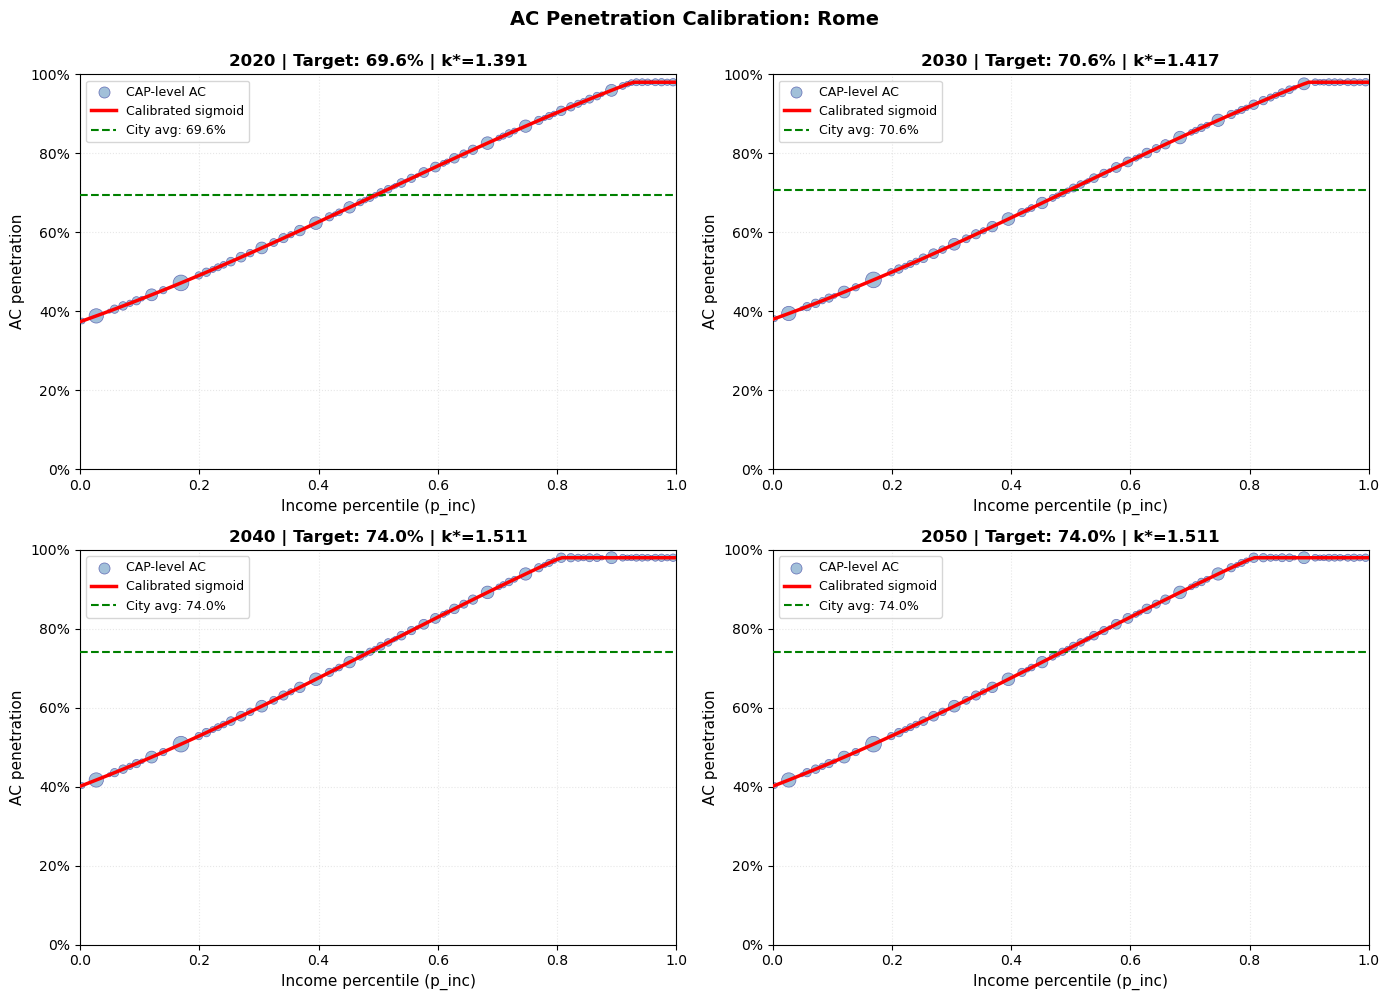

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# make years consistent 
YEARS_AC = [int(y) for y in YEARS_AC]
ac_city_by_year = {int(k): float(v) for k, v in ac_city_by_year.items()}

CITY_LABEL = cfg.get("city_name", globals().get("CITY", SLUG))

# inputs for calibration 
valid = (cap_stats["pop_cap"] > 0) & np.isfinite(cap_stats["p_inc"])
if not valid.any():
    raise RuntimeError("No valid CAP rows (require pop_cap>0 and finite p_inc).")

p_inc = cap_stats.loc[valid, "p_inc"].to_numpy(float)
w     = cap_stats.loc[valid, "pop_cap"].to_numpy(float)

ac_cfg = cfg.get("ac", {})
ac_min = float(ac_cfg.get("ac_min", 0.05))
ac_max = float(ac_cfg.get("ac_max", 0.98))
s      = float(ac_cfg.get("rank_slope", 2.2))

sig        = 1.0 / (1.0 + np.exp(-s * (p_inc - 0.5)))
base_acraw = ac_min + (ac_max - ac_min) * sig

ac_cap_by_year = {}
k_star_by_year = {}

def avg_after_clip(k: float, target_shape: np.ndarray) -> float:
    x = np.clip(ac_min + k * (target_shape - ac_min), ac_min, ac_max)
    return float(np.average(x, weights=w)) if w.sum() > 0 else float(x.mean())

# building CAP-level AC for each year 
for y in YEARS_AC:
    if y not in ac_city_by_year:
        raise KeyError(f"Year {y} missing in ac_city_by_year. Have: {sorted(ac_city_by_year)}")

    target = float(ac_city_by_year[y])
    if target > 1.0:
        target /= 100.0
    target = float(np.clip(target, 0.0, 1.0))

    lo_mean = avg_after_clip(0.0, base_acraw)
    hi_mean = avg_after_clip(1e6, base_acraw)
    if not (lo_mean - 1e-9 <= target <= hi_mean + 1e-9):
        print(f"[warn] {y}: target {target:.3f} outside [{lo_mean:.3f}, {hi_mean:.3f}]")

    k_lo, k_hi = 0.0, 1e6
    for _ in range(60):
        k_mid = 0.5 * (k_lo + k_hi)
        if avg_after_clip(k_mid, base_acraw) < target:
            k_lo = k_mid
        else:
            k_hi = k_mid
    k_star = 0.5 * (k_lo + k_hi)

    x = np.clip(ac_min + k_star * (base_acraw - ac_min), ac_min, ac_max)

    ac_vec = np.full(len(cap_stats), np.nan, dtype=float)
    ac_vec[valid.to_numpy()] = x
    ac_cap_by_year[y] = ac_vec
    k_star_by_year[y] = k_star

    achieved = float(np.average(x, weights=w))
    print(f"[{CITY_LABEL}] Year {y}: target={target:.3f}, achieved={achieved:.3f}, k*={k_star:.4g}")

# compatibility column (anchor to last year in YEARS_AC)
cap_stats["ac_cap_baseline"] = ac_cap_by_year[YEARS_AC[-1]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, year in enumerate(YEARS_AC):  # All years: [2020, 2030, 2040, 2050]
    ax = axes[idx]
    
    # Scatter: actual CAP-level AC vs income percentile
    valid_mask = np.isfinite(cap_stats['p_inc']) & np.isfinite(ac_cap_by_year[year])
    
    ax.scatter(
        cap_stats.loc[valid_mask, 'p_inc'], 
        ac_cap_by_year[year][valid_mask],
        s=cap_stats.loc[valid_mask, 'pop_cap']/1000,  # size by population
        alpha=0.5,
        c='steelblue',
        edgecolors='navy',
        linewidth=0.5,
        label='CAP-level AC'
    )
    
    # Overlay: theoretical logistic curve
    p_range = np.linspace(0, 1, 100)
    sig_range = 1 / (1 + np.exp(-s * (p_range - 0.5)))
    base_range = ac_min + (ac_max - ac_min) * sig_range
    k = k_star_by_year[year]
    ac_range = np.clip(ac_min + k * (base_range - ac_min), ac_min, ac_max)
    
    ax.plot(p_range, ac_range, 'r-', lw=2.5, label='Calibrated sigmoid', zorder=10)
    
    # Reference line: city average
    city_avg = ac_city_by_year[year]
    ax.axhline(city_avg, color='green', ls='--', lw=1.5, 
               label=f'City avg: {city_avg:.1%}', zorder=5)
    
    # Formatting
    ax.set_xlabel('Income percentile (p_inc)', fontsize=11)
    ax.set_ylabel('AC penetration', fontsize=11)

    valid_data = ac_cap_by_year[year][valid_mask]
    corr = np.corrcoef(cap_stats.loc[valid_mask, 'p_inc'], valid_data)[0, 1]

    ax.set_title(f'{year} | Target: {city_avg:.1%} | k*={k:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3, ls=':')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Format y-axis as percentages
    from matplotlib.ticker import PercentFormatter
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.suptitle(f'AC Penetration Calibration: {CITY_LABEL}', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

# Save
output_path = INT / f'ac_calibration_{SLUG}.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

# now building grid maps 
year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_base_3d = np.full((n_years, HGT, WDT), np.nan, dtype="float32")

for y in YEARS_AC:
    ac_by_id = np.full(max_cap_id + 1, np.nan, dtype=float)
    ac_by_id[cap_ids] = ac_cap_by_year[y]

    grid = ac_by_id[cap_on_ref]
    grid[~CITY_MASK] = np.nan
    coverage_base_3d[year_to_index[y]] = grid.astype("float32")

coverage_base = coverage_base_3d[year_to_index[YEARS_AC[-1]]]

- Perfect match to city-level aggregate (green line)
- Strong income-AC correlation (R > 0.95)
- Realistic functional form (logistic captures economic constraints)
- Tight fit (CAPs cluster within 5% of theoretical curve)

In [118]:
print("\n" + "="*60)
print("AC CALIBRATION VALIDATION")
print("="*60)

for year in YEARS_AC:
    target = ac_city_by_year[year]
    achieved = np.average(ac_cap_by_year[year][valid], weights=w)
    error = abs(achieved - target)
    
    # income gradient strength
    ac_vals = ac_cap_by_year[year][valid]
    corr = np.corrcoef(p_inc, ac_vals)[0, 1]
    
    # range
    ac_min_obs = ac_vals.min()
    ac_max_obs = ac_vals.max()
    
    print(f"\n{year}:")
    print(f"  Target:      {target:.3%}")
    print(f"  Achieved:    {achieved:.3%}")
    print(f"  Error:       {error:.4%}")
    print(f"  k*:          {k_star_by_year[year]:.4f}")
    print(f"  Income corr: {corr:.3f}")
    print(f"  Range:       [{ac_min_obs:.1%}, {ac_max_obs:.1%}]")


AC CALIBRATION VALIDATION

2020:
  Target:      69.550%
  Achieved:    69.550%
  Error:       0.0000%
  k*:          1.3915
  Income corr: 0.999
  Range:       [37.5%, 98.0%]

2030:
  Target:      70.574%
  Achieved:    70.574%
  Error:       0.0000%
  k*:          1.4167
  Income corr: 0.997
  Range:       [38.1%, 98.0%]

2040:
  Target:      74.004%
  Achieved:    74.004%
  Error:       0.0000%
  k*:          1.5106
  Income corr: 0.988
  Range:       [40.3%, 98.0%]

2050:
  Target:      74.004%
  Achieved:    74.004%
  Error:       0.0000%
  k*:          1.5106
  Income corr: 0.988
  Range:       [40.3%, 98.0%]


- Income percentile explains >97% of the variation in AC penetration.
    - assumption that income drives AC adoption is empirically justified
    - Very little unexplained variance → other factors (building type, household size, climate microvariability) are secondary
    - Rome shows strong income stratification in AC access
- Slight decline over time (0.999 → 0.988)
    - As AC becomes more universal (69% → 74%), income becomes slightly less deterministic
    - At 74% penetration, even middle-income households have AC
    - Still incredibly strong correlation

In [119]:
# building simple uniform maps for each year 
year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_base_3d = np.full((n_years, HGT, WDT), np.nan, dtype="float32")

for y in YEARS_AC:
    k = year_to_index[y]

    ac_by_id = np.full(max_cap_id + 1, np.nan, dtype=float)
    ac_by_id[cap_ids] = ac_cap_by_year[y]

    grid = ac_by_id[cap_on_ref]      # CAP to grid
    grid[~CITY_MASK] = np.nan

    coverage_base_3d[k] = grid.astype("float32")

coverage_base = coverage_base_3d[YEARS_AC.index(2050)]

In [120]:
# Check coverage
for y in YEARS_AC:
    grid_y = coverage_base_3d[year_to_index[y]]
    
    # Count pixels with AC data inside city mask
    inside_city = CITY_MASK.sum()
    has_ac_data = np.isfinite(grid_y) & CITY_MASK
    has_ac_count = has_ac_data.sum()
    
    print(f"{y}: {has_ac_count:,} / {inside_city:,} pixels with AC data "
          f"({100*has_ac_count/inside_city:.1f}%)")
    
    if has_ac_count < inside_city:
        missing_count = inside_city - has_ac_count
        print(f"  {missing_count:,} city pixels missing AC data!")

2020: 77,929 / 77,929 pixels with AC data (100.0%)
2030: 77,929 / 77,929 pixels with AC data (100.0%)
2040: 77,929 / 77,929 pixels with AC data (100.0%)
2050: 77,929 / 77,929 pixels with AC data (100.0%)


In [121]:
def make_cap_sub_for_year(y):
    """CAP-level table for year y, with AC share from ac_cap_by_year[y]."""
    vec = ac_cap_by_year[y]  # length = len(cap_stats)
    tmp = cap_stats.copy()
    tmp["ac_cap_year"] = vec

    cap_sub_y = tmp.loc[
        (tmp["pop_cap"] > 0)
        & np.isfinite(tmp["inc_mean"])
        & np.isfinite(tmp["ac_cap_year"]),
        ["cap5", "inc_mean", "inc_rank_base", "p_inc", "ac_cap_year", "pop_cap"]
    ].copy()
    return cap_sub_y


=== QA for year 2020 ===
Poorest CAPs (by clipped income rank): expect low p_inc & low AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
40,00119,"16,405.440","19,472.391",0.003,0.375,"18,173.712"
52,00133,"20,239.128","20,239.128",0.027,0.388,"107,203.519"
51,00132,"20,526.122","20,526.122",0.049,0.400,"8,887.726"
87,00172,"21,838.697","21,838.697",0.058,0.405,"36,776.425"
47,00126,"21,879.120","21,879.120",0.072,0.413,"38,515.630"
86,00171,"21,986.438","21,986.438",0.084,0.420,"21,725.513"
85,00169,"22,324.881","22,324.881",0.095,0.426,"36,189.406"
102,00188,"22,460.978","22,460.978",0.104,0.432,"11,921.849"



Richest CAPs (by clipped income rank): expect high p_inc & high AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
109,00197,"73,978.616","70,013.808",0.994,0.980,"29,702.609"
101,00187,"69,022.606","69,022.606",0.985,0.980,"21,716.294"
110,00198,"62,380.569","62,380.569",0.975,0.980,"28,761.974"
100,00186,"59,432.594","59,432.594",0.965,0.980,"25,952.606"
106,00193,"57,444.654","57,444.654",0.958,0.980,"9,626.217"
77,00161,"51,451.279","51,451.279",0.952,0.980,"22,760.755"
98,00184,"51,072.271","51,072.271",0.943,0.980,"25,575.275"
104,00191,"50,621.539","50,621.539",0.933,0.980,"25,742.968"



Unweighted Pearson corr (inc_mean vs AC):


...


Richest CAPs (by clipped income rank): expect high p_inc & high AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
109,00197,"73,978.616","70,013.808",0.994,0.980,"29,702.609"
101,00187,"69,022.606","69,022.606",0.985,0.980,"21,716.294"
110,00198,"62,380.569","62,380.569",0.975,0.980,"28,761.974"
100,00186,"59,432.594","59,432.594",0.965,0.980,"25,952.606"
106,00193,"57,444.654","57,444.654",0.958,0.980,"9,626.217"
77,00161,"51,451.279","51,451.279",0.952,0.980,"22,760.755"
98,00184,"51,072.271","51,072.271",0.943,0.980,"25,575.275"
104,00191,"50,621.539","50,621.539",0.933,0.980,"25,742.968"



Unweighted Pearson corr (inc_mean vs AC):


,inc_mean,ac_cap_year
inc_mean,1.000,0.802
ac_cap_year,0.802,1.000


Weighted Pearson corr (by grid pop): 0.815
Pop-weighted mean AC share: 0.740


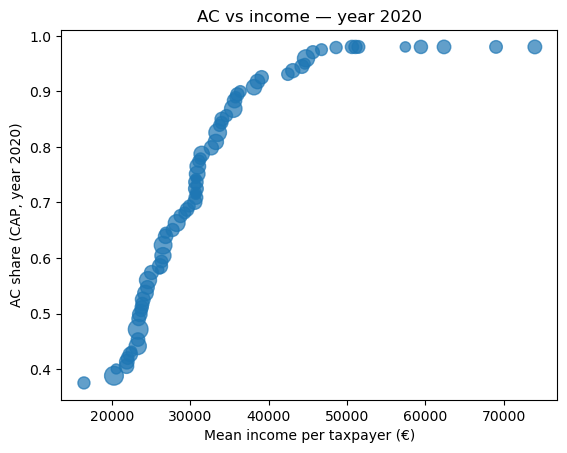

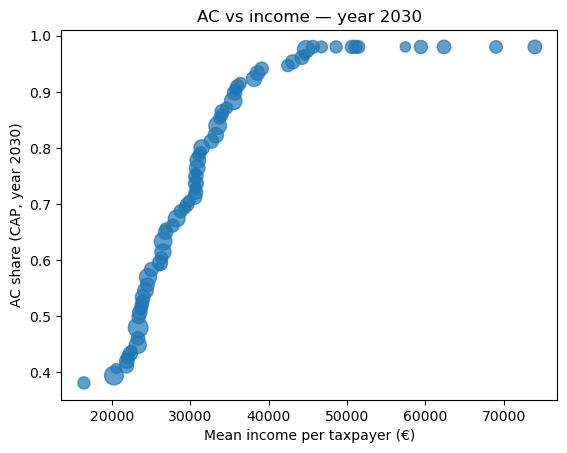

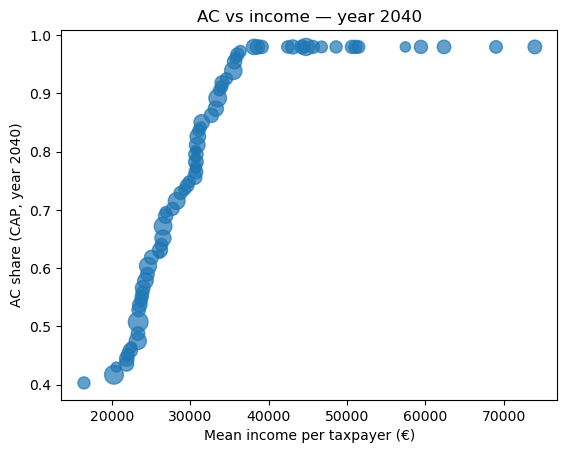

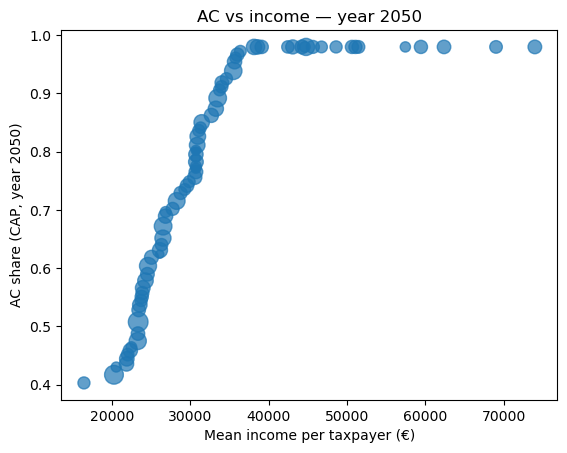

In [122]:
pd.options.display.float_format = "{:,.3f}".format

def weighted_corr(x, y, w):
    x = np.asarray(x, float); y = np.asarray(y, float); w = np.asarray(w, float)
    m_x = np.average(x, weights=w); m_y = np.average(y, weights=w)
    cov = np.average((x - m_x) * (y - m_y), weights=w)
    sx = np.sqrt(np.average((x - m_x)**2, weights=w))
    sy = np.sqrt(np.average((y - m_y)**2, weights=w))
    return cov / (sx * sy) if (sx > 0 and sy > 0) else np.nan

for y in YEARS_AC:
    print(f"\n=== QA for year {y} ===")
    cap_sub = make_cap_sub_for_year(y)

    n_show = min(8, len(cap_sub))

    print("Poorest CAPs (by clipped income rank): expect low p_inc & low AC")
    display(cap_sub.sort_values("inc_rank_base", kind="mergesort").head(n_show))

    print("\nRichest CAPs (by clipped income rank): expect high p_inc & high AC")
    display(cap_sub.sort_values("inc_rank_base", ascending=False, kind="mergesort").head(n_show))

    print("\nUnweighted Pearson corr (inc_mean vs AC):")
    display(cap_sub[["inc_mean", "ac_cap_year"]].corr().round(3))

    wc = weighted_corr(cap_sub["inc_mean"], cap_sub["ac_cap_year"], cap_sub["pop_cap"])
    mean_pop = np.average(cap_sub["ac_cap_year"], weights=cap_sub["pop_cap"])
    print(f"Weighted Pearson corr (by grid pop): {wc:.3f}")
    print(f"Pop-weighted mean AC share: {mean_pop:.3f}")

    size = 200 * np.sqrt(cap_sub["pop_cap"] / cap_sub["pop_cap"].max())
    size = np.clip(size, 10, None)

    ax = cap_sub.plot.scatter(x="inc_mean", y="ac_cap_year", s=size, alpha=0.7)
    ax.set_xlabel("Mean income per taxpayer (€)")
    ax.set_ylabel(f"AC share (CAP, year {y})")
    ax.set_title(f"AC vs income — year {y}")

### 2.2 Baseline Coverage Maps

**Current CAP AC Coverage on CLIMADA GRID**


===== YEAR 2020 =====
[QA] City pop-w mean on grid 2020: 0.696 (target 0.696)
[QA] City pop-w mean from CAP agg: 0.696 (target 0.696)
[QA] City pop-w mean (CITY_MASK): 0.696 (target 0.696)


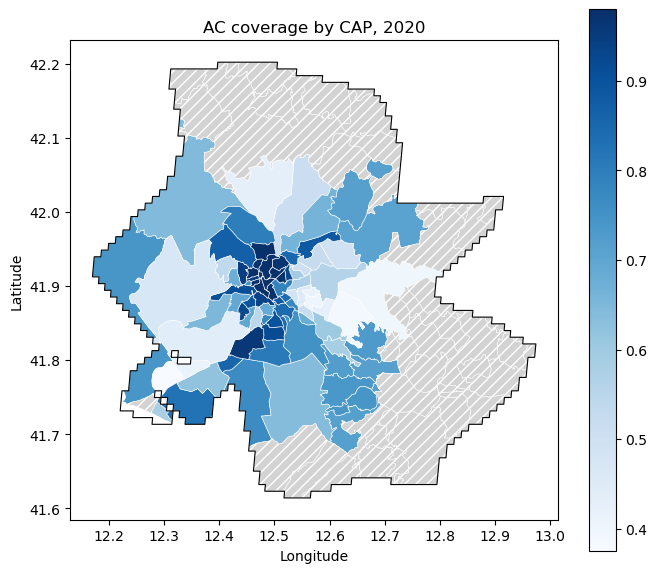


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.375,"18,173.712",37.502
1,53,00133,0.388,"107,203.519",38.793
2,52,00132,0.400,"8,887.726",40.017
3,88,00172,0.405,"36,776.425",40.506
4,48,00126,0.413,"38,515.630",41.321
5,87,00171,0.420,"21,725.513",41.982
6,86,00169,0.426,"36,189.406",42.624
7,103,00188,0.432,"11,921.849",43.162
8,67,00148,0.441,"74,057.284",44.135
9,93,00177,0.453,"28,236.863",45.311


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,107,00193,0.980,"9,626.217",98.000
1,110,00197,0.980,"29,702.609",98.000
2,111,00198,0.980,"28,761.974",98.000
3,101,00186,0.980,"25,952.606",98.000
4,99,00184,0.980,"25,575.275",98.000
5,78,00161,0.980,"22,760.755",98.000
6,105,00191,0.980,"25,742.968",98.000
7,102,00187,0.980,"21,716.294",98.000
8,108,00195,0.979,"18,626.093",97.892
9,109,00196,0.975,"16,550.496",97.505



===== YEAR 2030 =====
[QA] City pop-w mean on grid 2030: 0.706 (target 0.706)
[QA] City pop-w mean from CAP agg: 0.706 (target 0.706)
[QA] City pop-w mean (CITY_MASK): 0.706 (target 0.706)


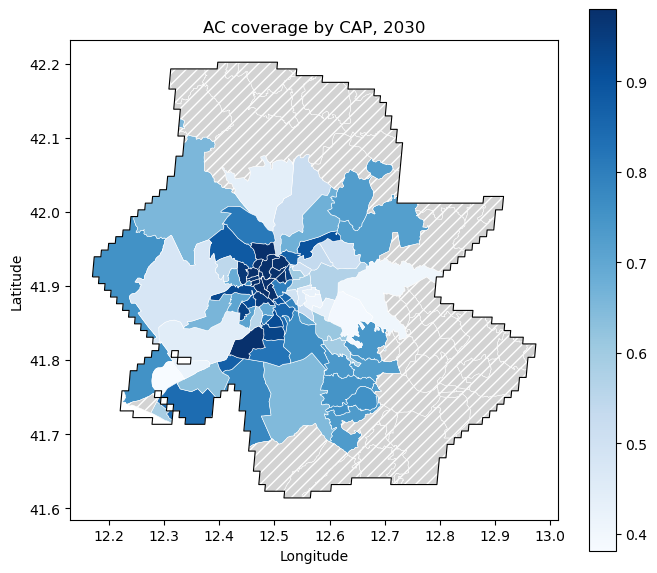


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.381,"18,173.712",38.091
1,53,00133,0.394,"107,203.519",39.405
2,52,00132,0.407,"8,887.726",40.652
3,88,00172,0.411,"36,776.425",41.149
4,48,00126,0.420,"38,515.630",41.980
5,87,00171,0.427,"21,725.513",42.653
6,86,00169,0.433,"36,189.406",43.306
7,103,00188,0.439,"11,921.849",43.854
8,67,00148,0.448,"74,057.284",44.845
9,93,00177,0.460,"28,236.863",46.042


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,107,00193,0.980,"9,626.217",98.000
1,110,00197,0.980,"29,702.609",98.000
2,109,00196,0.980,"16,550.496",98.000
3,108,00195,0.980,"18,626.093",98.000
4,102,00187,0.980,"21,716.294",98.000
5,101,00186,0.980,"25,952.606",98.000
6,99,00184,0.980,"25,575.275",98.000
7,78,00161,0.980,"22,760.755",98.000
8,105,00191,0.980,"25,742.968",98.000
9,112,00199,0.980,"24,483.314",98.000



===== YEAR 2040 =====
[QA] City pop-w mean on grid 2040: 0.740 (target 0.740)
[QA] City pop-w mean from CAP agg: 0.740 (target 0.740)
[QA] City pop-w mean (CITY_MASK): 0.740 (target 0.740)


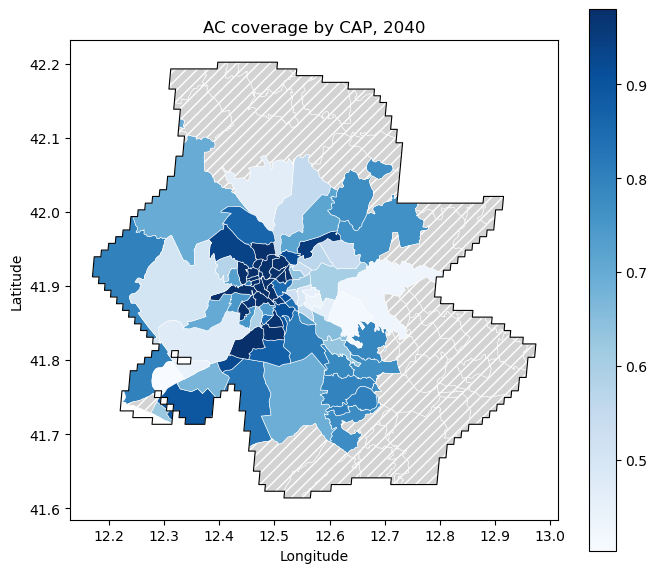


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.403,"18,173.712",40.286
1,53,00133,0.417,"107,203.519",41.687
2,52,00132,0.430,"8,887.726",43.016
3,88,00172,0.435,"36,776.425",43.547
4,48,00126,0.444,"38,515.630",44.432
5,87,00171,0.451,"21,725.513",45.149
6,86,00169,0.458,"36,189.406",45.846
7,103,00188,0.464,"11,921.849",46.431
8,67,00148,0.475,"74,057.284",47.487
9,93,00177,0.488,"28,236.863",48.763


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,69,00151,0.980,"26,998.324",98.000
1,107,00193,0.980,"9,626.217",98.000
2,110,00197,0.980,"29,702.609",98.000
3,79,00162,0.980,"20,086.918",98.000
4,99,00184,0.980,"25,575.275",98.000
5,78,00161,0.980,"22,760.755",98.000
6,61,00142,0.980,"37,515.508",98.000
7,71,00153,0.980,"34,033.783",98.000
8,101,00186,0.980,"25,952.606",98.000
9,112,00199,0.980,"24,483.314",98.000



===== YEAR 2050 =====
[QA] City pop-w mean on grid 2050: 0.740 (target 0.740)
[QA] City pop-w mean from CAP agg: 0.740 (target 0.740)
[QA] City pop-w mean (CITY_MASK): 0.740 (target 0.740)


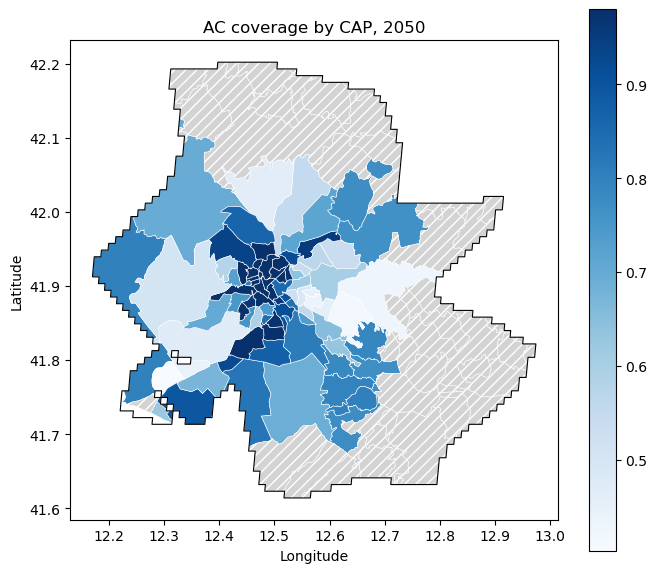


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.403,"18,173.712",40.286
1,53,00133,0.417,"107,203.519",41.687
2,52,00132,0.430,"8,887.726",43.016
3,88,00172,0.435,"36,776.425",43.547
4,48,00126,0.444,"38,515.630",44.432
5,87,00171,0.451,"21,725.513",45.149
6,86,00169,0.458,"36,189.406",45.846
7,103,00188,0.464,"11,921.849",46.431
8,67,00148,0.475,"74,057.284",47.487
9,93,00177,0.488,"28,236.863",48.763


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,69,00151,0.980,"26,998.324",98.000
1,107,00193,0.980,"9,626.217",98.000
2,110,00197,0.980,"29,702.609",98.000
3,79,00162,0.980,"20,086.918",98.000
4,99,00184,0.980,"25,575.275",98.000
5,78,00161,0.980,"22,760.755",98.000
6,61,00142,0.980,"37,515.508",98.000
7,71,00153,0.980,"34,033.783",98.000
8,101,00186,0.980,"25,952.606",98.000
9,112,00199,0.980,"24,483.314",98.000


In [123]:
import matplotlib.pyplot as plt

for YEAR_DIAG in YEARS_AC:
    print("\n===== YEAR", YEAR_DIAG, "=====")
    k_diag = year_to_index[YEAR_DIAG]

    coverage_map = coverage_base_3d[k_diag].astype("float32").copy()

    target_ac = float(ac_city_by_year[YEAR_DIAG])
    if target_ac > 1.0:
        target_ac /= 100.0
    target_ac = float(np.clip(target_ac, 0.0, 1.0))

    if np.isnan(coverage_map[CITY_MASK]).any():
        coverage_map = np.where(
            CITY_MASK & np.isnan(coverage_map),
            target_ac,
            coverage_map
        ).astype("float32")

    assert np.isfinite(coverage_map[CITY_MASK]).all(), "Non-finite coverage inside CITY_MASK."

    m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_on_ref > 0)
    w = pop_on_ref[m_city]
    x = coverage_map[m_city]
    mean_pw = float(np.nansum(x * w) / np.nansum(w))

    print(f"[QA] City pop-w mean on grid {YEAR_DIAG}: {mean_pw:.3f} (target {target_ac:.3f})")

    valid = CAP_PIX
    df_capgrid = pd.DataFrame({
        "cap_id": cap_on_ref[valid].ravel().astype(int),
        "pop":    pop_on_ref[valid].ravel().astype(float),
        "cov":    coverage_map[valid].ravel().astype(float),
    })
    df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

    def wavg(g):
        w = g["pop"].to_numpy(dtype=float)
        x = g["cov"].to_numpy(dtype=float)
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    cap_pw   = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop  = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_cap"}))
    cap_disp = (df_capgrid.groupby("cap_id")
                .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                     ac_max=("cov","max"), n_pix=("cov","size"))
                .reset_index())
    cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left").merge(cap_disp, on="cap_id", how="left")
    cap_map = cap_4326.merge(cap_cov, on="cap_id", how="left")

    cov_city_check = float(np.nansum(df_capgrid["cov"] * df_capgrid["pop"]) / np.nansum(df_capgrid["pop"]))
    cov_city_all = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
    print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {target_ac:.3f})")
    print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {target_ac:.3f})")

    ax = fua.to_crs("EPSG:4326").boundary.plot(
        edgecolor="black", facecolor="none", linewidth=0.8, figsize=(7,6)
    )
    cap_map.to_crs("EPSG:4326").plot(
        ax=ax, column="ac_cov_pw", cmap="Blues", legend=True,
        edgecolor="white", linewidth=0.4,
        missing_kwds={"color":"lightgray","edgecolor":"white","hatch":"///","label":"No data"}
    )
    ax.set_title(f"AC coverage by CAP, {YEAR_DIAG}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.figure.tight_layout()
    plt.show()

    tbl = (cap_map[["cap_id","cap5","ac_cov_pw","pop_cap"]]
           .dropna(subset=["ac_cov_pw"])
           .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
           .sort_values("ac_pct"))

    print("\nLowest-coverage CAPs:")
    display(tbl.head(10).reset_index(drop=True))

    print("Highest-coverage CAPs:")
    display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))

### 2.3 Coverage Diagnostics

In [124]:
import matplotlib.pyplot as plt

# for each of the year 2020, 2030, 2040, 2050
for y in YEARS_AC:
    print("\n" + "="*20 + f" YEAR {y} " + "="*20)
    YEAR_DIAG = y
    k_diag    = year_to_index[YEAR_DIAG]

    # coverage on grid for this year 
    coverage_map = coverage_base_3d[k_diag].astype("float32").copy()

    # target citywide mean for that year 
    target_ac = float(ac_city_by_year[YEAR_DIAG])
    if target_ac > 1.0:
        target_ac /= 100.0
    target_ac = float(np.clip(target_ac, 0.0, 1.0))

    # fill any remaining NaNs inside CITY_MASK with the city mean for that year
    if np.isnan(coverage_map[CITY_MASK]).any():
        coverage_map = np.where(
            CITY_MASK & np.isnan(coverage_map),
            target_ac,
            coverage_map
        ).astype("float32")

    # assert no NaNs where we care
    assert np.isfinite(coverage_map[CITY_MASK]).all(), \
        f"Non-finite coverage inside CITY_MASK for year {YEAR_DIAG}."

    # city pop-weighted mean on grid
    pop_grid_y = POP_GRID.get(YEAR_DIAG, pop_on_ref_base)
    m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_grid_y > 0)
    w      = pop_grid_y[m_city]
    x = coverage_map[m_city]
    mean_pw = float(np.nansum(x * w) / np.nansum(w))

    print(f"[QA] City pop-w mean on grid {YEAR_DIAG}: {mean_pw:.3f} (target {target_ac:.3f})")

    # CAP aggregation + map for this year 
    valid = CAP_PIX
    df_capgrid = pd.DataFrame({
        "cap_id": cap_on_ref[valid].ravel().astype(int),
        "pop":    pop_on_ref[valid].ravel().astype(float),
        "cov":    coverage_map[valid].ravel().astype(float),
    })
    df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

    def wavg(g):
        w = g["pop"].to_numpy(dtype=float)
        x = g["cov"].to_numpy(dtype=float)
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    cap_pw   = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop  = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_cap"}))
    cap_disp = (df_capgrid.groupby("cap_id")
                .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                     ac_max=("cov","max"), n_pix=("cov","size"))
                .reset_index())
    cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left").merge(cap_disp, on="cap_id", how="left")
    cap_map = cap_4326.merge(cap_cov, on="cap_id", how="left")

    cov_city_check = float(np.nansum(df_capgrid["cov"] * df_capgrid["pop"]) / np.nansum(df_capgrid["pop"]))
    cov_city_all   = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
    print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {target_ac:.3f})")
    print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {target_ac:.3f})")

    # consistency checks by year 
    # pixels we actually painted from CAPs
    df_capgrid_cons = df_capgrid.copy()

    cap_pw_cons  = df_capgrid_cons.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop_cons = (df_capgrid_cons.groupby("cap_id", as_index=False)["pop"]
                    .sum().rename(columns={"pop":"pop_cap"}))
    cap_cov_cons = cap_pw_cons.merge(cap_pop_cons, on="cap_id", how="left")

    # year-specific CAP targets
    df_target = cap_stats[["cap_id"]].copy()
    df_target["ac_cap_target"] = ac_cap_by_year[YEAR_DIAG]

    cap_join = cap_cov_cons.merge(df_target, on="cap_id", how="left")

    diff = np.abs(cap_join["ac_cov_pw"] - cap_join["ac_cap_target"])
    err_cap = float(np.nanmax(diff)) if np.any(np.isfinite(diff)) else 0.0
    print(f"[{YEAR_DIAG}] Max per-CAP diff (grid vs CAP table): {err_cap:.3e}")

    # grid-level bounds respected
    m_city2 = CITY_MASK & np.isfinite(coverage_map)
    print(f"[{YEAR_DIAG}] Min/Max coverage on grid:",
          float(np.nanmin(coverage_map[m_city2])),
          float(np.nanmax(coverage_map[m_city2])))

    w2 = np.where(m_city2, pop_on_ref, 0.0)
    at_floor = np.isclose(coverage_map, ac_min, atol=1e-6)
    at_cap   = np.isclose(coverage_map, ac_max, atol=1e-6)
    print(f"[{YEAR_DIAG}] Pop share at floor:", float(np.nansum(w2 * at_floor) / np.nansum(w2)))
    print(f"[{YEAR_DIAG}] Pop share at cap:  ", float(np.nansum(w2 * at_cap)   / np.nansum(w2)))

    print(f"[{YEAR_DIAG}] Grid pop-weighted mean:",
          float(np.nansum(coverage_map[m_city2] * pop_on_ref[m_city2]) /
                np.nansum(pop_on_ref[m_city2])))

    # tables: lowest / highest coverage CAPs for this year
    tbl = (cap_map[["cap_id","cap5","ac_cov_pw","pop_cap"]]
           .dropna(subset=["ac_cov_pw"])
           .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
           .sort_values("ac_pct"))

    print("\nLowest-coverage CAPs:")
    display(tbl.head(10).reset_index(drop=True))

    print("Highest-coverage CAPs:")
    display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))


==================== YEAR 2020 ====================
[QA] City pop-w mean on grid 2020: 0.696 (target 0.696)
[QA] City pop-w mean from CAP agg: 0.696 (target 0.696)
[QA] City pop-w mean (CITY_MASK): 0.696 (target 0.696)
[2020] Max per-CAP diff (grid vs CAP table): 2.911e-08
[2020] Min/Max coverage on grid: 0.3750227689743042 0.9800000190734863
[2020] Pop share at floor: 0.0
[2020] Pop share at cap:   0.07204966992139816
[2020] Grid pop-weighted mean: 0.6955036520957947

Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.375,"18,173.712",37.502
1,53,00133,0.388,"107,203.519",38.793
2,52,00132,0.400,"8,887.726",40.017
3,88,00172,0.405,"36,776.425",40.506
4,48,00126,0.413,"38,515.630",41.321
5,87,00171,0.420,"21,725.513",41.982
6,86,00169,0.426,"36,189.406",42.624
7,103,00188,0.432,"11,921.849",43.162
8,67,00148,0.441,"74,057.284",44.135
9,93,00177,0.453,"28,236.863",45.311


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,107,00193,0.980,"9,626.217",98.000
1,110,00197,0.980,"29,702.609",98.000
2,111,00198,0.980,"28,761.974",98.000
3,101,00186,0.980,"25,952.606",98.000
4,99,00184,0.980,"25,575.275",98.000
5,78,00161,0.980,"22,760.755",98.000
6,105,00191,0.980,"25,742.968",98.000
7,102,00187,0.980,"21,716.294",98.000
8,108,00195,0.979,"18,626.093",97.892
9,109,00196,0.975,"16,550.496",97.505



==================== YEAR 2030 ====================
[QA] City pop-w mean on grid 2030: 0.706 (target 0.706)
[QA] City pop-w mean from CAP agg: 0.706 (target 0.706)
[QA] City pop-w mean (CITY_MASK): 0.706 (target 0.706)
[2030] Max per-CAP diff (grid vs CAP table): 2.906e-08
[2030] Min/Max coverage on grid: 0.38091468811035156 0.9800000190734863
[2030] Pop share at floor: 0.0
[2030] Pop share at cap:   0.09469245374202728
[2030] Grid pop-weighted mean: 0.7057379484176636

Lowest-coverage CAPs:


...

,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,69,00151,0.980,"26,998.324",98.000
1,107,00193,0.980,"9,626.217",98.000
2,110,00197,0.980,"29,702.609",98.000
3,79,00162,0.980,"20,086.918",98.000
4,99,00184,0.980,"25,575.275",98.000
5,78,00161,0.980,"22,760.755",98.000
6,61,00142,0.980,"37,515.508",98.000
7,71,00153,0.980,"34,033.783",98.000
8,101,00186,0.980,"25,952.606",98.000
9,112,00199,0.980,"24,483.314",98.000



==================== YEAR 2050 ====================
[QA] City pop-w mean on grid 2050: 0.740 (target 0.740)
[QA] City pop-w mean from CAP agg: 0.740 (target 0.740)
[QA] City pop-w mean (CITY_MASK): 0.740 (target 0.740)
[2050] Max per-CAP diff (grid vs CAP table): 2.964e-08
[2050] Min/Max coverage on grid: 0.4028584361076355 0.9800000190734863
[2050] Pop share at floor: 0.0
[2050] Pop share at cap:   0.20217502117156982
[2050] Grid pop-weighted mean: 0.7400426864624023

Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.403,"18,173.712",40.286
1,53,00133,0.417,"107,203.519",41.687
2,52,00132,0.430,"8,887.726",43.016
3,88,00172,0.435,"36,776.425",43.547
4,48,00126,0.444,"38,515.630",44.432
5,87,00171,0.451,"21,725.513",45.149
6,86,00169,0.458,"36,189.406",45.846
7,103,00188,0.464,"11,921.849",46.431
8,67,00148,0.475,"74,057.284",47.487
9,93,00177,0.488,"28,236.863",48.763


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,69,00151,0.980,"26,998.324",98.000
1,107,00193,0.980,"9,626.217",98.000
2,110,00197,0.980,"29,702.609",98.000
3,79,00162,0.980,"20,086.918",98.000
4,99,00184,0.980,"25,575.275",98.000
5,78,00161,0.980,"22,760.755",98.000
6,61,00142,0.980,"37,515.508",98.000
7,71,00153,0.980,"34,033.783",98.000
8,101,00186,0.980,"25,952.606",98.000
9,112,00199,0.980,"24,483.314",98.000


In [125]:
# building table: one row per CAP with income rank + grid pop
# we restrict to CAPs that actually have modeled population (>0) on the CLIMADA grid
cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0, ["cap_id","cap5","p_inc","pop_cap"]]
             .rename(columns={"pop_cap":"pop_cap_grid", "p_inc":"rank_key"})
)

sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","rank_key","pop_cap_grid"]]
       .sort_values("rank_key")   # still ascending: poorer first
       .reset_index(drop=True))

## 3. POLICY DESIGN (framework, income-targeted, uniform)

### 3.1 Policy Framework

### Policy Comparison Framework

We compare two allocation strategies under a **user constraint** 
(equal number of additional AC users):

1. **Income-Targeted Policy**: 
   - Prioritizes 50% lowest-income CAPs
   - Brings them to 70% 
   - Results in N additional AC users

2. **Uniform Policy**: 
   - Distributes AC increase uniformly across all CAPs
   - Calibrated via bisection to achieve same N additional users
   - Ensures fair comparison of targeting strategies

### 3.2 Income-Targeted Policy ("Catch-Up")

some notes on following code:
- we rank CAPs by income but we cumulate the WorldPop pop, not the taxpayers anymore
- New policy!! 

### Income-Targeted Policy: "Catch-Up" Strategy

**Policy design**: Bring the 50% poorest CAPs (by income rank) to 70% AC coverage.

**Rationale**: Address equity gap while respecting realistic adoption ceiling.

**Implementation**: 
- Select bottom 50% CAPs by income (population-weighted)
- Lift AC coverage to max(baseline, 70%)
- Non-target CAPs remain at baseline

In [126]:
# AC policy - Income

import numpy as np, pandas as pd

# reading para from YAML if present 
ac_cfg   = cfg.get("ac", {})
pol_cfg  = cfg.get("ac_policy", {})  
X_SHARE  = float(pol_cfg.get("target_share_by_pop", 0.50))   # 50% poorest by grid pop
TARGET   = float(pol_cfg.get("target_level",        0.70))   # lift to 70%
TOL      = float(pol_cfg.get("tol",                 1e-6))  

# AC bounds 
AC_LO = float(ac_cfg.get("ac_min", 0.05))
AC_HI = float(ac_cfg.get("ac_max", 0.98))

# helpers 
def popw_mean(arr, mask=None):
    m = np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if mask is not None:
        m &= mask
    if not np.any(m):
        return np.nan
    w = pop_on_ref[m].astype(float)
    x = arr[m].astype(float)
    den = np.sum(w)
    return float(np.sum(x * w) / den) if den > 0 else np.nan

def cap_popw_mean_from(arr, valid_mask, name):
    m = valid_mask & np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if not np.any(m):
        return pd.DataFrame(columns=["cap_id", name])
    df = pd.DataFrame({
        "cap_id": cap_on_ref[m].ravel().astype(int),
        name:     arr[m].ravel().astype(float),
        "w":      pop_on_ref[m].ravel().astype(float),
    })
    out = (df.groupby("cap_id")
             .apply(lambda g: float(np.sum(g[name]*g["w"]) / np.sum(g["w"]))
                              if g["w"].sum() > 0 else np.nan)
             .reset_index(name=name))
    return out

# selector input anchored to the grid universe 
need_cols = {"cap_id","cap5","inc_rank_base","pop_cap"}
missing = need_cols - set(cap_stats.columns)
if missing:
    raise KeyError(f"cap_stats missing columns: {sorted(missing)}")

# ensuring p_inc exists (same percentile rule)
if "p_inc" not in cap_stats.columns:
    cap_stats["p_inc"] = weighted_percentile_rank(
        cap_stats["inc_rank_base"].to_numpy(),
        cap_stats["pop_cap"].to_numpy()
    ).clip(1e-3, 1-1e-3)

cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0,
                  ["cap_id","cap5","inc_rank_base","p_inc","pop_cap"]]
             .rename(columns={"pop_cap": "pop_cap_grid"})
             .assign(cap_id=lambda d: d["cap_id"].astype(int),
                     pop_cap_grid=lambda d: d["pop_cap_grid"].astype(float))
             .reset_index(drop=True)
)

# sorting poorer to richer
sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","inc_rank_base","p_inc","pop_cap_grid"]]
       .sort_values(["inc_rank_base","cap_id"], kind="mergesort")
       .reset_index(drop=True))

# cumulative pop population share in CAP universe
if sel.empty:
    raise ValueError("No CAPs with positive grid population in CAP_PIX.")

total_pop = float(sel["pop_cap_grid"].sum())
if total_pop <= 0:
    raise ValueError("Zero total grid population in CAP_PIX; check pop_on_ref / CAP_PIX.")

sel["cum_pop"]   = sel["pop_cap_grid"].cumsum()
sel["cum_share"] = sel["cum_pop"] / total_pop

# choosing cutoff closest to X_SHARE 
cum = sel["cum_share"].to_numpy()
idx_hi   = int(np.searchsorted(cum, X_SHARE, side="left"))
idx_hi   = min(max(idx_hi, 0), len(sel)-1)
share_hi = float(cum[idx_hi])
share_lo = float(cum[idx_hi-1]) if idx_hi > 0 else 0.0
use_hi   = (abs(share_hi - X_SHARE) <= abs(share_lo - X_SHARE))
cut_idx  = idx_hi if use_hi else (idx_hi - 1)

target_ids = np.array(
    sorted(set(sel.loc[:cut_idx, "cap_id"].astype(int).to_numpy())),
    dtype=int
)

# diagnostics 
num = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, target_ids)]))
den = float(np.nansum(pop_on_ref[CAP_PIX]))
share = num / den if den > 0 else np.nan
print(f"Selection share (grid, cap_id-based): {share:.2%} "
      f"(X_SHARE={100*X_SHARE:.0f}%, lo={100*share_lo:.2f}%, hi={100*share_hi:.2f}%, "
      f"picked={'hi' if use_hi else 'lo'})")

Selection share (grid, cap_id-based): 49.81% (X_SHARE=50%, lo=49.81%, hi=51.10%, picked=lo)


In [127]:
# multi-year AC policy: building policy coverage maps for each AC year 

year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_policy_3d = np.full_like(coverage_base_3d, np.nan, dtype="float32")

# storing CAP-level policy shares (income-targeted catch-up) per year
ac_cap_policy_by_year = {}

for y in YEARS_AC:
    k = year_to_index[y]
    print(f"\n=== AC policy for year {y} ===")

    # baseline CAP-level coverage for this year (vector aligned with cap_stats)
    base_cap_vec = ac_cap_by_year[y].astype(float)  # length = len(cap_stats)

    # per-CAP policy table for this year
    cap_tbl = pd.DataFrame({
        "cap_id": cap_ids,
        "ac_cap_baseline": base_cap_vec,
    })
    cap_tbl["is_target"] = np.isin(cap_tbl["cap_id"].to_numpy(), target_ids)

    cap_tbl["ac_cap_policy"] = np.where(
        cap_tbl["is_target"],
        np.maximum(cap_tbl["ac_cap_baseline"], TARGET),
        cap_tbl["ac_cap_baseline"]
    ).clip(AC_LO, AC_HI)

    # storing CAP-level policy shares for this year
    ac_cap_policy_by_year[y] = cap_tbl["ac_cap_policy"].to_numpy(dtype=float)

    # lookup arrays cap_id -> coverage
    ac_lut_base   = np.full(max_cap_id + 1, np.nan, dtype="float32")
    ac_lut_policy = np.full_like(ac_lut_base, np.nan)

    idx = cap_tbl["cap_id"].astype(int).to_numpy()
    ac_lut_base[idx]   = cap_tbl["ac_cap_baseline"].astype("float32").to_numpy()
    ac_lut_policy[idx] = cap_tbl["ac_cap_policy"].astype("float32").to_numpy()

    # fill missing baseline with city mean for that year
    city_mean_y = float(ac_city_by_year[y])
    if city_mean_y > 1.0:
        city_mean_y /= 100.0
    city_mean_y = float(np.clip(city_mean_y, 0.0, 1.0))

    nan_pol = np.isnan(ac_lut_policy)
    ac_lut_policy[nan_pol] = ac_lut_base[nan_pol]
    nan_base = np.isnan(ac_lut_base)
    ac_lut_base[nan_base] = city_mean_y

    # baseline map for this year already exists
    coverage_base_y   = coverage_base_3d[k].astype("float32").copy()

    # policy map for this year: paint CAP values onto grid
    coverage_policy_y = np.full(ref_data.shape, np.nan, dtype="float32")
    inside_cap_haz    = CAP_PIX  # CAP label and inside city
    if np.any(inside_cap_haz):
        coverage_policy_y[inside_cap_haz] = ac_lut_policy[cap_on_ref[inside_cap_haz]]

    # if any city pixels still NaN in policy map, keep baseline
    mask_nan = CITY_MASK & np.isnan(coverage_policy_y)
    coverage_policy_y[mask_nan] = coverage_base_y[mask_nan]

    # valid analysis mask for this year
    CAP_MASK_y = CAP_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # citywide pop-weighted means (diagnostics)
    mean_base = popw_mean(coverage_base_y,   CAP_MASK_y)
    mean_pol  = popw_mean(coverage_policy_y, CAP_MASK_y)
    print(f"City AC baseline (pop-w, CAP_PIX): {mean_base:.3f}")
    print(f"City AC policy   (pop-w, CAP_PIX): {mean_pol:.3f}")
    print(f"Δ mean (pp): {100*(mean_pol - mean_base):.2f}")

    # simple LUT violations check (per CAP, for this year)
    base = cap_tbl["ac_cap_baseline"].to_numpy()
    pol  = cap_tbl["ac_cap_policy"].to_numpy()
    targ_mask_tbl = cap_tbl["is_target"].to_numpy()

    v1 = (targ_mask_tbl & (base + TOL < TARGET) & (pol + TOL < TARGET))
    v2 = (targ_mask_tbl & (base >= TARGET - TOL) & (pol + TOL < base - 1e-12))
    print(f"[{y}] LUT violations (should be 0, 0):", int(v1.sum()), int(v2.sum()))

    # save in 3D array
    coverage_policy_3d[k] = coverage_policy_y

# in case we needed (from before) 
coverage_base   = coverage_base_3d[YEARS_AC.index(2050)]
coverage_policy = coverage_policy_3d[YEARS_AC.index(2050)]


=== AC policy for year 2020 ===
City AC baseline (pop-w, CAP_PIX): 0.696
City AC policy   (pop-w, CAP_PIX): 0.782
Δ mean (pp): 8.63
[2020] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2030 ===
City AC baseline (pop-w, CAP_PIX): 0.706
City AC policy   (pop-w, CAP_PIX): 0.788
Δ mean (pp): 8.20
[2030] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2040 ===
City AC baseline (pop-w, CAP_PIX): 0.740
City AC policy   (pop-w, CAP_PIX): 0.808
Δ mean (pp): 6.76
[2040] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2050 ===
City AC baseline (pop-w, CAP_PIX): 0.740
City AC policy   (pop-w, CAP_PIX): 0.808
Δ mean (pp): 6.76
[2050] LUT violations (should be 0, 0): 0 0


### 3.3 Uniform Policy

**Uniform policy**: Adds the same percentage point increase to all CAPs, 
calibrated to add the same total number of AC users as the income-targeted policy (e.g., +9.12 pp in 2050 = 178,219 users).

In [129]:
# UNIFORM AC POLICY scalar uplift, same extra users
# as income-targeted policy, using 2020 CAP population
import numpy as np
import pandas as pd

# 2020 CAP population (static policy basis — already in cap_stats)
pop_cap_2020 = cap_stats["pop_cap"].to_numpy(float)
cap_ids_vec  = cap_stats["cap_id"].astype(int).to_numpy()
max_cap_id   = int(cap_stats["cap_id"].max())

ac_cap_uniform_by_year = {}
coverage_uniform_3d    = np.full_like(coverage_base_3d, np.nan, dtype="float32")

def extra_users_for_delta(delta, base_share, pop, ac_hi, mask_valid):
    """
    For a given change (in fraction points), return total extra AC users:
        Σ pop_i * (AC_uniform_i - base_share_i)
    where AC_uniform_i = min(ac_hi, base_share_i + Δ), and we never reduce AC.
    """
    # proposed uplift in share
    ac_uplift = np.minimum(ac_hi, base_share + delta) - base_share
    # guard against any numerical negatives
    ac_uplift = np.clip(ac_uplift, 0.0, None)
    return float(np.sum(pop[mask_valid] * ac_uplift[mask_valid]))


for y in YEARS_AC:
    base_share   = ac_cap_by_year[y].astype(float)         # baseline CAP AC (scenario)
    income_share = ac_cap_policy_by_year[y].astype(float)  # income-targeted policy

    if base_share.shape != pop_cap_2020.shape:
        raise ValueError(
            f"[uniform AC] shape mismatch year {y}: "
            f"base={base_share.shape}, pop={pop_cap_2020.shape}"
        )

    # CAPs we actually care about for extra users:
    #   - positive population
    #   - finite baseline and income-policy shares
    mask_valid = (
        (pop_cap_2020 > 0) &
        np.isfinite(base_share) &
        np.isfinite(income_share)
    )

    # extra users under income-targeted policy
    delta_share_income = np.clip(income_share - base_share, 0.0, None)
    add_users_income   = float(
        np.nansum(pop_cap_2020[mask_valid] * delta_share_income[mask_valid])
    )

    print(f"\n[Uniform AC, scalar Δ] Year {y}")
    print(f"  Extra users in income-targeted policy: {add_users_income:,.1f}")

    # degenerate case: no uplift
    if add_users_income <= 0 or not np.any(mask_valid):
        share_uniform = base_share.copy()
        print("  (No positive uplift → uniform policy = baseline.)")
    else:
        # Find change such that:
        #   sum pop_i * (min(AC_HI, base_share_i + Δ) - base_share_i) = add_users_income
        # The RHS is monotone in Δ, so 1D bisection works.
        lo, hi = 0.0, 1.0  # 0–100 percentage points is always enough

        for _ in range(60):  
            mid = 0.5 * (lo + hi)
            extra_mid = extra_users_for_delta(
                mid, base_share, pop_cap_2020, AC_HI, mask_valid
            )
            if extra_mid < add_users_income:
                lo = mid
            else:
                hi = mid

        delta_star = 0.5 * (lo + hi)

        # final uniform uplift
        ac_uniform = np.minimum(AC_HI, base_share + delta_star)
        ac_uniform = np.clip(ac_uniform, AC_LO, AC_HI)  # respect global bounds

        # making sure we never reduce AC anywhere
        uplift = np.clip(ac_uniform - base_share, 0.0, None)
        share_uniform = base_share + uplift

        # diagnostics: checking that total extra users match income policy
        add_users_uniform = float(
            np.nansum(pop_cap_2020[mask_valid] * uplift[mask_valid])
        )
        diff    = add_users_income - add_users_uniform
        rel_err = abs(diff) / max(1.0, abs(add_users_income))

        print(f"  Δ* = {delta_star*100:.2f} pp")
        print(f"  Extra users under uniform policy: {add_users_uniform:,.1f} "
              f"(diff = {diff:,.1f}, rel={100*rel_err:.3f}%)")

    # storing CAP-level uniform shares
    ac_cap_uniform_by_year[y] = share_uniform.astype(float)

    # Map CAP to grid for this year
    lut_uniform = np.full(max_cap_id + 1, np.nan, dtype="float32")
    lut_uniform[cap_ids_vec] = share_uniform.astype("float32")

    cov_uniform_grid = lut_uniform[cap_on_ref]
    cov_uniform_grid[~CITY_MASK] = np.nan

    coverage_uniform_3d[year_to_index[y]] = cov_uniform_grid.astype("float32")

# convenience: uniform policy grid for last AC year
coverage_uniform = coverage_uniform_3d[YEARS_AC.index(YEARS_AC[-1])]


[Uniform AC, scalar Δ] Year 2020
  Extra users in income-targeted policy: 227,374.3
  Δ* = 10.25 pp
  Extra users under uniform policy: 227,374.3 (diff = 0.0, rel=0.000%)

[Uniform AC, scalar Δ] Year 2030
  Extra users in income-targeted policy: 216,117.8
  Δ* = 10.02 pp
  Extra users under uniform policy: 216,117.8 (diff = 0.0, rel=0.000%)

[Uniform AC, scalar Δ] Year 2040
  Extra users in income-targeted policy: 178,218.8
  Δ* = 9.12 pp
  Extra users under uniform policy: 178,218.8 (diff = 0.0, rel=0.000%)

[Uniform AC, scalar Δ] Year 2050
  Extra users in income-targeted policy: 178,218.8
  Δ* = 9.12 pp
  Extra users under uniform policy: 178,218.8 (diff = 0.0, rel=0.000%)


### 3.4 Policy Coverage Maps

In [130]:
# config-driven names
KEYS = cfg.get("keys", {})  # optional in YAML
CAP_CODE   = KEYS.get("cap_code", "cap5")
CAP_IDCOL  = KEYS.get("cap_id",  "cap_id")
MUNI_ID    = KEYS.get("muni_id", "muni_id")
MUNI_NAME  = KEYS.get("muni_name", "muni_name")

# display
_has_display = "display" in globals()

# CRS helper for plotting 
def _to_wgs84(gdf):
    if gdf is None or gdf.empty:
        return gdf
    crs = getattr(gdf, "crs", None)
    if crs is None:
        return gdf  
    try:
        return gdf.to_crs("EPSG:4326")
    except Exception:
        return gdf  

# diagnostics: p_inc for the targeted set
sel["is_target"] = False
sel.loc[:cut_idx, "is_target"] = True

target_view = (sel.loc[sel["is_target"],
                       [CAP_IDCOL, CAP_CODE, "inc_rank_base", "p_inc", "pop_cap_grid", "cum_share"]]
                 .assign(p_inc_pct=lambda d: (100*d["p_inc"]).round(1),
                         pop_k=lambda d: (d["pop_cap_grid"]/1000).round(1))
              )

print("Targeted CAPs (poorest first) – showing first/last 10 with p_inc:")
tv = pd.concat([target_view.head(10), target_view.tail(10)]).reset_index(drop=True)
if _has_display:
    display(tv)
else:
    print(tv)

p_boundary = float(sel.loc[cut_idx, "p_inc"])
share_boundary = float(sel.loc[cut_idx, "cum_share"])
print(f"Boundary p_inc ≈ {p_boundary:.3f} (~{p_boundary*100:.1f}th pct by people); "
      f"cum. share at boundary = {share_boundary:.2%}")

# what if we used p_inc <= boundary as the selection rule?
ids_by_pinc = (cap_income_id.loc[
                    (cap_income_id["p_inc"] <= p_boundary) &
                    (cap_income_id["pop_cap_grid"] > 0),
                    CAP_IDCOL]
               .astype(int).unique())
num2 = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, ids_by_pinc)]))
den  = float(np.nansum(pop_on_ref[CAP_PIX]))
print(f"Selection share if using p_inc<=boundary: {num2/den:.2%} (vs grid-anchored {share:.2%})")

Targeted CAPs (poorest first) – showing first/last 10 with p_inc:
    cap_id   cap5  inc_rank_base  p_inc  pop_cap_grid  cum_share  p_inc_pct  \
0       41  00119     19,472.391  0.003    18,173.712      0.007      0.300   
1       53  00133     20,239.128  0.027   107,203.519      0.048      2.700   
2       52  00132     20,526.122  0.049     8,887.726      0.051      4.900   
3       88  00172     21,838.697  0.058    36,776.425      0.065      5.800   
4       48  00126     21,879.120  0.072    38,515.630      0.080      7.200   
5       87  00171     21,986.438  0.084    21,725.513      0.088      8.400   
6       86  00169     22,324.881  0.095    36,189.406      0.102      9.500   
7      103  00188     22,460.978  0.104    11,921.849      0.106     10.400   
8       67  00148     23,274.837  0.120    74,057.284      0.134     12.000   
9       93  00177     23,305.890  0.140    28,236.863      0.145     14.000   
10      89  00173     26,492.326  0.369    58,304.164      0.380 

In [131]:
# CAP-level coverage table and maps for a chosen diagnostic year

YEAR_DIAG = 2050  # we can change to 2020/2030/2040/2050 as needed
# just didn't want to print all the outputs together 
k_diag    = year_to_index[YEAR_DIAG]

coverage_base_diag   = coverage_base_3d[k_diag].astype("float32")
coverage_policy_diag = coverage_policy_3d[k_diag].astype("float32")

# mask where both baseline and policy are defined for this year
CAP_MASK_diag = CAP_PIX & np.isfinite(coverage_base_diag) & np.isfinite(coverage_policy_diag)

# CAP-level coverage table (baseline, policy, change)
valid_b = CAP_MASK_diag & np.isfinite(coverage_base_diag)
valid_p = CAP_MASK_diag & np.isfinite(coverage_policy_diag)

cap_base = cap_popw_mean_from(coverage_base_diag,   valid_b, "ac_base")
cap_pol  = cap_popw_mean_from(coverage_policy_diag, valid_p, "ac_policy")

cap_cov  = (cap_base.merge(cap_pol, on=CAP_IDCOL, how="outer")
                    .assign(delta=lambda d: d["ac_policy"] - d["ac_base"]))

cap_pop = (pd.DataFrame({
                CAP_IDCOL: cap_on_ref[CAP_MASK_diag].ravel().astype(int),
                "pop":     pop_on_ref[CAP_MASK_diag].ravel().astype(float)
           })
           .groupby(CAP_IDCOL, as_index=False)["pop"].sum()
           .rename(columns={"pop":"pop_cap"}))

cap_cov = (cap_cov.merge(cap_pop, on=CAP_IDCOL, how="left")
                 .merge(cap_4326[[CAP_IDCOL, CAP_CODE]], on=CAP_IDCOL, how="left"))

# building map GeoDataFrame for this year
cap_map = cap_4326.merge(
    cap_cov[[CAP_IDCOL,"ac_base","ac_policy","delta"]],
    on=CAP_IDCOL, how="left"
)

# ranges for baseline/policy
_min_base, _min_pol = cap_cov["ac_base"].min(),   cap_cov["ac_policy"].min()
_max_base, _max_pol = cap_cov["ac_base"].max(),   cap_cov["ac_policy"].max()
vmin = float(np.nanmin([_min_base, _min_pol])) if np.isfinite([_min_base, _min_pol]).any() else 0.0
vmax = float(np.nanmax([_max_base, _max_pol])) if np.isfinite([_max_base, _max_pol]).any() else 1.0

dv   = float(np.nanpercentile(
                np.abs(cap_map["delta"].to_numpy(dtype=float)), 99
             )) if "delta" in cap_map else 0.0
if not np.isfinite(dv) or dv == 0.0:
    dv = 0.0  # keeps plotting but avoids NaN ranges

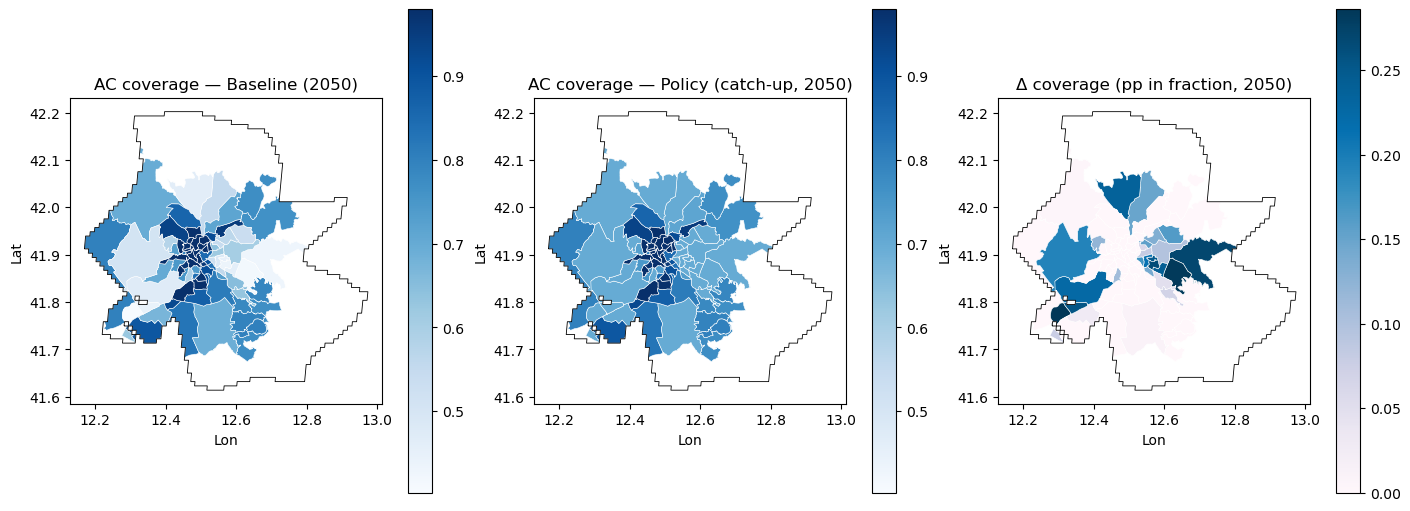

In [132]:
# plot maps
fig, ax = plt.subplots(1,3, figsize=(14,5), constrained_layout=True)

_fua_wgs    = _to_wgs84(fua) if "fua" in globals() else None
_capmap_wgs = _to_wgs84(cap_map)

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[0], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[0], column="ac_base", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True
)
ax[0].set_title(f"AC coverage — Baseline ({YEAR_DIAG})")
ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[1], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[1], column="ac_policy", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True
)
ax[1].set_title(f"AC coverage — Policy (catch-up, {YEAR_DIAG})")
ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[2], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[2], column="delta", cmap="PuBu",
    vmin=0.0, vmax=dv if dv > 0 else None,
    edgecolor="white", lw=0.4, legend=True
)
ax[2].set_title(f"Δ coverage (pp in fraction, {YEAR_DIAG})")
ax[2].set_xlabel("Lon"); ax[2].set_ylabel("Lat")
plt.show()

In [133]:
# tables: top/bottom changes by CAP for this YEAR_DIAG
tbl = (cap_cov.dropna(subset=["delta"])
              .assign(ac_base_pct=lambda d: 100*d["ac_base"],
                      ac_policy_pct=lambda d: 100*d["ac_policy"],
                      delta_pp=lambda d: 100*d["delta"])
              .sort_values(["delta_pp", CAP_CODE], ascending=[False, True]))

print(f"\nTop Δcoverage CAPs (year {YEAR_DIAG}):")
top_tbl = tbl[[CAP_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]] \
              .head(10).reset_index(drop=True)
if _has_display:
    display(top_tbl)
else:
    print(top_tbl)

print(f"\nBottom (or zero) Δcoverage CAPs (year {YEAR_DIAG}):")
bot_tbl = (tbl[[CAP_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]]
           .tail(10).sort_values("delta_pp").reset_index(drop=True))
if _has_display:
    display(bot_tbl)
else:
    print(bot_tbl)


Top Δcoverage CAPs (year 2050):
    cap5  ac_base_pct  ac_policy_pct  delta_pp     pop_cap
0  00119       40.286         70.000    29.714  18,173.712
1  00133       41.687         70.000    28.313 107,203.519
2  00132       43.016         70.000    26.984   8,887.726
3  00172       43.547         70.000    26.453  36,776.425
4  00126       44.432         70.000    25.568  38,515.630
5  00171       45.149         70.000    24.851  21,725.513
6  00169       45.846         70.000    24.154  36,189.406
7  00188       46.431         70.000    23.569  11,921.849
8  00148       47.487         70.000    22.513  74,057.284
9  00177       48.763         70.000    21.237  28,236.863

Bottom (or zero) Δcoverage CAPs (year 2050):
    cap5  ac_base_pct  ac_policy_pct  delta_pp    pop_cap
0  00187       98.000         98.000     0.000 21,716.294
1  00189       86.241         86.241     0.000 34,615.281
2  00191       98.000         98.000     0.000 25,742.968
3  00192       98.000         98.000    

In [134]:
# some checks 
# sets at each stage
caps_csv   = set(inc_agg[CAP_CODE].astype(str))
caps_shp   = set(cap_4326[CAP_CODE].astype(str)) # after FUA clip
caps_rast  = set(cap_ref[CAP_CODE].astype(str))  # after reprojection (same as caps_shp)
ids_on_grid = set(np.unique(cap_on_ref[cap_on_ref > 0]).astype(int))
caps_labeled = set(cap_ref.loc[cap_ref[CAP_IDCOL].isin(ids_on_grid), CAP_CODE].astype(str))

# CAPs with any pixel under CITY_MASK 
ids_cap_pix  = set(np.unique(cap_on_ref[CAP_PIX]).astype(int))
caps_cap_pix = set(cap_ref.loc[cap_ref[CAP_IDCOL].isin(ids_cap_pix), CAP_CODE].astype(str))

# CAPs with >0 modeled pop in CAP_PIX
df_capgrid = pd.DataFrame({
    CAP_IDCOL: cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":     pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid[CAP_IDCOL] > 0]
pop_by_cap = (df_capgrid.groupby(CAP_IDCOL)["pop"].sum()
              .rename("pop_cap").reset_index())
caps_poppos = set(
    cap_ref.merge(pop_by_cap, on=CAP_IDCOL, how="left")
           .query("pop_cap > 0")[CAP_CODE].astype(str)
)

# buckets 
missing_in_shapes_or_outside_fua = sorted(caps_csv - caps_shp)
in_shapes_but_no_labeled_pixels  = sorted(caps_shp - caps_labeled)
labeled_but_not_in_CITY_MASK     = sorted(caps_labeled - caps_cap_pix)
in_CAP_PIX_but_zero_population   = sorted(caps_cap_pix - caps_poppos)

print("CSV CAPs:", len(caps_csv))
print("After FUA clip (polygons):", len(caps_shp))
print("Labeled on grid (any pixels):", len(caps_labeled))
print("In CAP_PIX (city mask & labeled):", len(caps_cap_pix))
print(">0 population in CAP_PIX:", len(caps_poppos))
print()
print("Missing (CSV but not in shapes/FUA):", len(missing_in_shapes_or_outside_fua), missing_in_shapes_or_outside_fua[:10])
print("No labeled pixels (resolution / all_touched=False):", len(in_shapes_but_no_labeled_pixels), in_shapes_but_no_labeled_pixels[:10])
print("Only outside CITY_MASK/hazard or pop==0 area:", len(labeled_but_not_in_CITY_MASK), labeled_but_not_in_CITY_MASK[:10])
print("Zero modeled pop in CAP_PIX:", len(in_CAP_PIX_but_zero_population), in_CAP_PIX_but_zero_population[:10])

CSV CAPs: 72
After FUA clip (polygons): 118
Labeled on grid (any pixels): 81
In CAP_PIX (city mask & labeled): 81
>0 population in CAP_PIX: 81

Missing (CSV but not in shapes/FUA): 0 []
No labeled pixels (resolution / all_touched=False): 37 ['00010', '00015', '00018', '00019', '00020', '00024', '00029', '00030', '00031', '00033']
Only outside CITY_MASK/hazard or pop==0 area: 0 []
Zero modeled pop in CAP_PIX: 0 []


Super important to understand why:
- In my income CSV there are 72 rows of 72 CAP with incomes data
- But then shapefile + FUA clip contains all CAP zones that intersect the FUA (metro area), not just the Comune di Roma → 118 CAPs. Many of those extra CAPs are the suburban/postal zones that start with 000xx (typical around Rome).
- After rasterization, 36 of those polygons don’t catch a grid cell at the resolution (all_touched=False) → “No labeled pixels”. One more has pixels but none in CITY_MASK (outside hazard or pop_on_ref==0)

In [135]:
# CAP-level coverage: baseline vs income-policy vs uniform

YEAR_DIAG = 2050  # or 2020/2030/2040/2050
k_diag    = year_to_index[YEAR_DIAG]

cov_base   = coverage_base_3d[k_diag].astype("float32")
cov_income = coverage_policy_3d[k_diag].astype("float32")
cov_unif   = coverage_uniform_3d[k_diag].astype("float32")

CAP_MASK_diag = (
    CAP_PIX &
    np.isfinite(cov_base) &
    np.isfinite(cov_income) &
    np.isfinite(cov_unif)
)

# Pop-weighted CAP means from the grid
cap_base   = cap_popw_mean_from(cov_base,   CAP_MASK_diag, "ac_base")
cap_income = cap_popw_mean_from(cov_income, CAP_MASK_diag, "ac_policy_income")
cap_unif   = cap_popw_mean_from(cov_unif,   CAP_MASK_diag, "ac_policy_uniform")

# CAP populations from grid for this YEAR_DIAG
df_capgrid_diag = pd.DataFrame({
    CAP_IDCOL: cap_on_ref[CAP_MASK_diag].ravel().astype(int),
    "pop":     pop_on_ref[CAP_MASK_diag].ravel().astype(float),
})
df_capgrid_diag = df_capgrid_diag[df_capgrid_diag[CAP_IDCOL] > 0]
cap_pop_diag = (df_capgrid_diag.groupby(CAP_IDCOL, as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_cap"}))

cap_cov_all = (cap_base
               .merge(cap_income, on=CAP_IDCOL, how="outer")
               .merge(cap_unif,   on=CAP_IDCOL, how="outer")
               .merge(cap_pop_diag, on=CAP_IDCOL, how="left")
               .merge(cap_4326[[CAP_IDCOL, CAP_CODE]], on=CAP_IDCOL, how="left"))

cap_cov_all["ac_base_pct"]         = 100*cap_cov_all["ac_base"]
cap_cov_all["ac_policy_income_pct"] = 100*cap_cov_all["ac_policy_income"]
cap_cov_all["ac_policy_uniform_pct"] = 100*cap_cov_all["ac_policy_uniform"]

print(f"CAP coverage summary ({YEAR_DIAG}): baseline vs income vs uniform")
display(
    cap_cov_all[[CAP_CODE, "ac_base_pct", "ac_policy_income_pct",
                 "ac_policy_uniform_pct", "pop_cap"]]
    .sort_values("ac_policy_uniform_pct")
    .reset_index(drop=True)
    .head(15)
)

# Optional export
cap_cov_all.to_csv(
    INT / f"ac_cap_coverage_allpolicies_{SLUG}_{YEAR_DIAG}.csv",
    index=False
)
print("Wrote CAP coverage CSV for diagnostic year:",
      INT / f"ac_cap_coverage_allpolicies_{SLUG}_{YEAR_DIAG}.csv")

CAP coverage summary (2050): baseline vs income vs uniform


,cap5,ac_base_pct,ac_policy_income_pct,ac_policy_uniform_pct,pop_cap
0,00119,40.286,70.000,49.406,"18,173.712"
1,00133,41.687,70.000,50.807,"107,203.519"
2,00132,43.016,70.000,52.136,"8,887.726"
3,00172,43.547,70.000,52.667,"36,776.425"
4,00126,44.432,70.000,53.552,"38,515.630"
5,00171,45.149,70.000,54.270,"21,725.513"
6,00169,45.846,70.000,54.967,"36,189.406"
7,00188,46.431,70.000,55.551,"11,921.849"
8,00148,47.487,70.000,56.607,"74,057.284"
9,00177,48.763,70.000,57.884,"28,236.863"


Wrote CAP coverage CSV for diagnostic year: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_cap_coverage_allpolicies_rome_2050.csv


**Municipi**

In [136]:
# City-agnostic config
REGION_GDF        = globals().get("regions", muni)   # GeoDataFrame of regions+outside
REGION_ID_FIELD   = "muni_id"                        # integer id per region
REGION_NAME_FIELD = "muni_name"                      # readable name
OUTSIDE_LABEL     = "Fuori Municipi (FUA)"           # label when id==0 
PLOT_LABEL        = "Municipi"                       # for plot titles


===== Municipi stats for year 2020 =====
[QA 2020] City (grid) base=0.696 vs sum-over-Municipi=0.696
[QA 2020] City (grid) pol =0.782 vs sum-over-Municipi=0.782

Top/bottom Municipi by Δ (policy - baseline), pp
    muni_id  ac_base_muni  ac_policy_muni    pop_muni  delta  delta_pp  \
6         6         0.398           0.700 131,684.912  0.302    30.220   
5         5         0.485           0.701 186,055.607  0.216    21.635   
11       11         0.526           0.701 123,717.631  0.175    17.486   
4         4         0.556           0.709 174,912.273  0.154    15.360   
13       13         0.631           0.762 135,088.538  0.131    13.101   
10       10         0.641           0.746 227,837.578  0.105    10.483   
14       14         0.697           0.786 163,773.161  0.089     8.935   
7         7         0.669           0.743 256,906.235  0.074     7.355   
12       12         0.738           0.798 136,042.403  0.060     5.982   
3         3         0.715           0.764 153,54

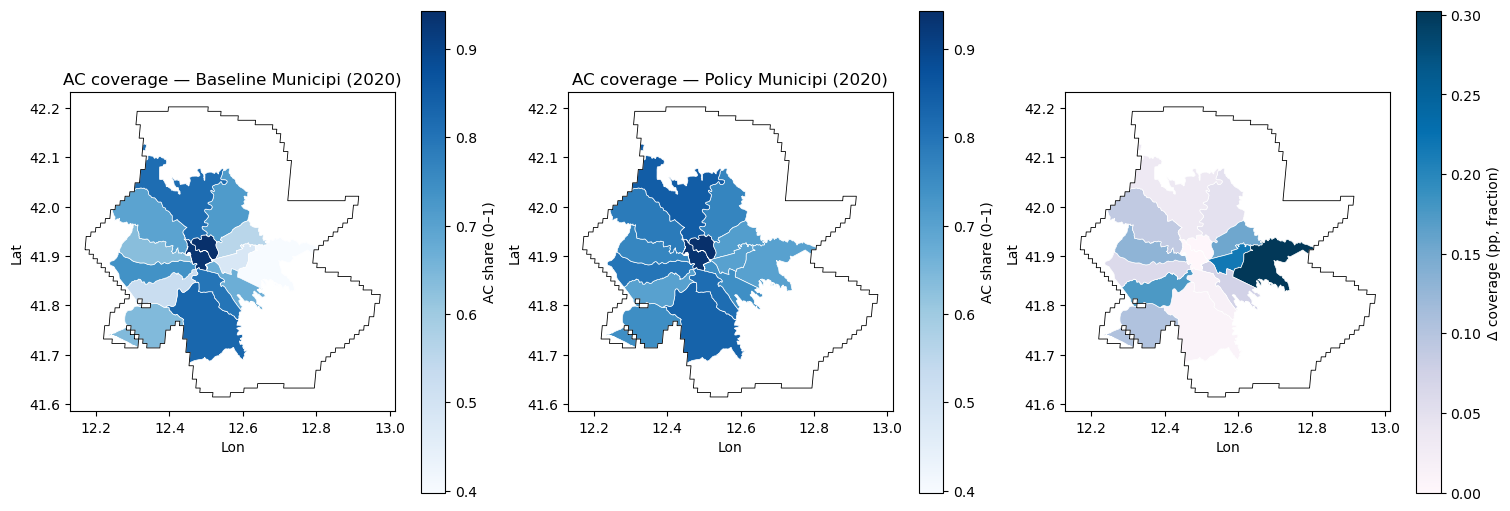


===== Municipi stats for year 2030 =====
[QA 2030] City (grid) base=0.706 vs sum-over-Municipi=0.706
[QA 2030] City (grid) pol =0.788 vs sum-over-Municipi=0.788

Top/bottom Municipi by Δ (policy - baseline), pp
    muni_id  ac_base_muni  ac_policy_muni    pop_muni  delta  delta_pp  \
6         6         0.404           0.700 127,378.690  0.296    29.590   
5         5         0.493           0.701 179,869.615  0.209    20.866   
11       11         0.535           0.704 119,803.339  0.169    16.916   
4         4         0.565           0.710 169,089.088  0.145    14.522   
13       13         0.642           0.767 130,701.854  0.125    12.525   
10       10         0.652           0.751 220,800.463  0.099     9.931   
14       14         0.709           0.793 158,462.193  0.085     8.450   
7         7         0.680           0.748 248,261.720  0.068     6.795   
12       12         0.750           0.806 131,663.470  0.056     5.567   
3         3         0.727           0.769 148,39

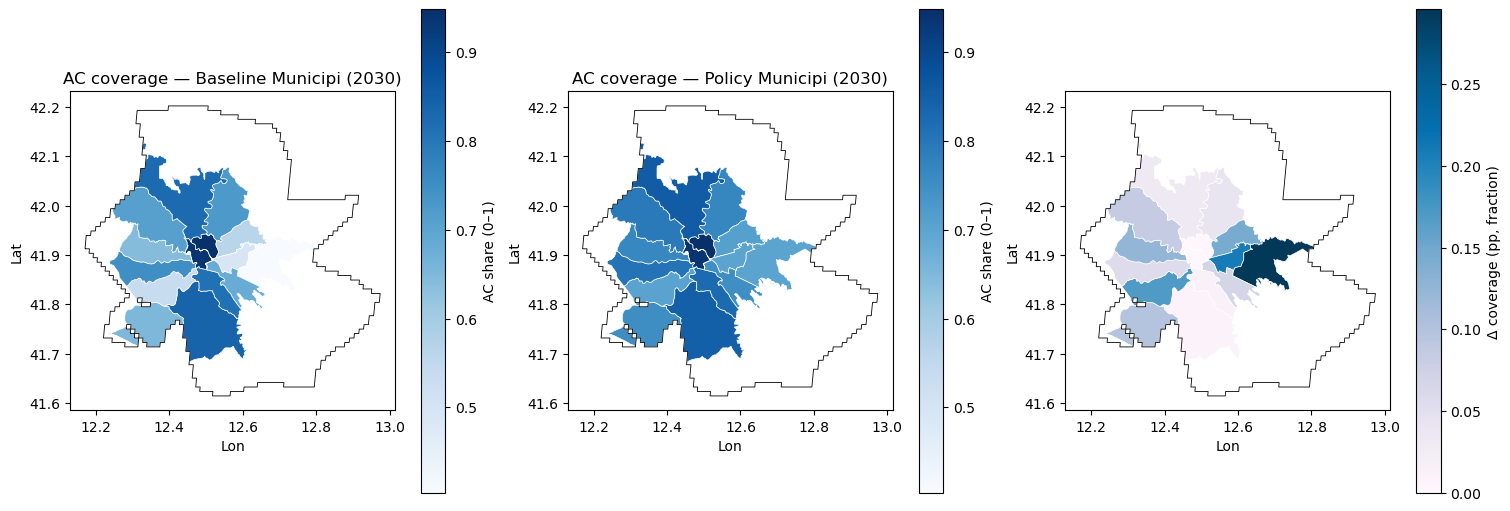


===== Municipi stats for year 2040 =====
[QA 2040] City (grid) base=0.740 vs sum-over-Municipi=0.740
[QA 2040] City (grid) pol =0.808 vs sum-over-Municipi=0.808

Top/bottom Municipi by Δ (policy - baseline), pp
    muni_id  ac_base_muni  ac_policy_muni    pop_muni  delta  delta_pp  \
6         6         0.428           0.700 124,455.966  0.272    27.243   
5         5         0.522           0.702 175,742.470  0.180    18.003   
11       11         0.567           0.715 117,053.903  0.148    14.761   
4         4         0.599           0.713 165,206.499  0.114    11.394   
13       13         0.680           0.788 127,702.865  0.107    10.718   
10       10         0.692           0.770 215,734.151  0.079     7.859   
14       14         0.747           0.814 154,826.246  0.068     6.764   
7         7         0.722           0.771 242,563.966  0.049     4.939   
12       12         0.791           0.834 128,642.425  0.043     4.327   
15       15         0.859           0.887  96,97

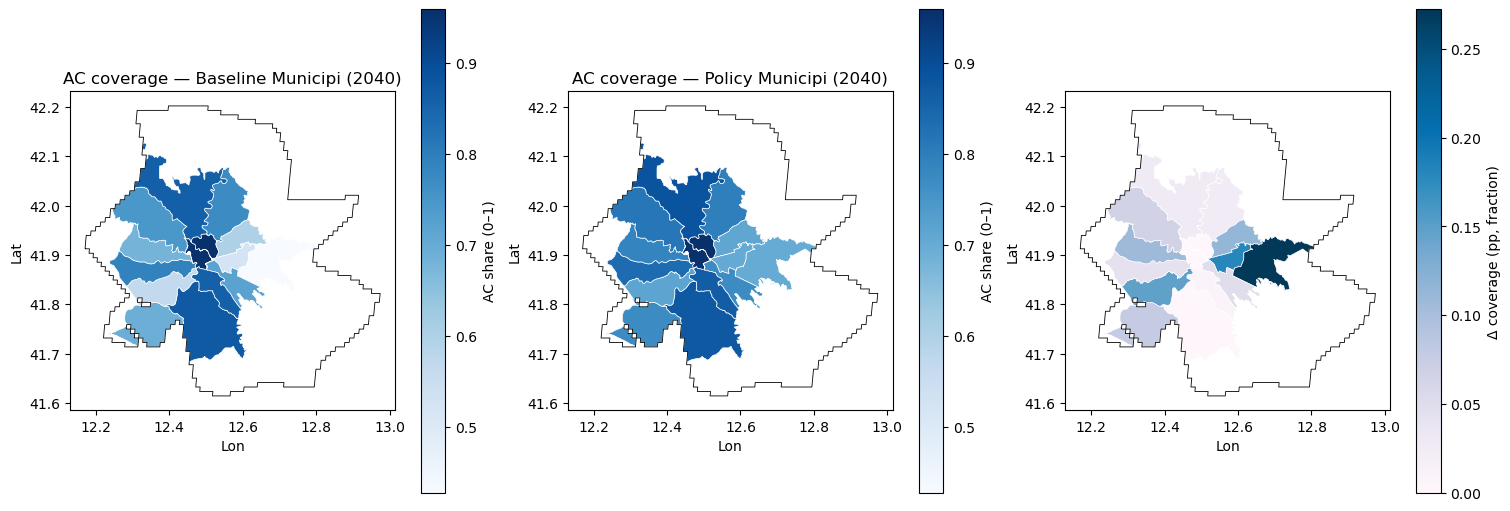


===== Municipi stats for year 2050 =====
[QA 2050] City (grid) base=0.740 vs sum-over-Municipi=0.740
[QA 2050] City (grid) pol =0.808 vs sum-over-Municipi=0.808

Top/bottom Municipi by Δ (policy - baseline), pp
    muni_id  ac_base_muni  ac_policy_muni    pop_muni  delta  delta_pp  \
6         6         0.428           0.700 122,048.099  0.272    27.243   
5         5         0.522           0.702 172,342.319  0.180    18.003   
11       11         0.567           0.715 114,789.021  0.148    14.761   
4         4         0.599           0.713 162,009.110  0.114    11.394   
13       13         0.680           0.788 125,232.151  0.107    10.718   
10       10         0.692           0.770 211,560.268  0.079     7.859   
14       14         0.747           0.814 151,830.769  0.068     6.764   
7         7         0.722           0.771 237,870.554  0.049     4.939   
12       12         0.791           0.834 126,153.536  0.043     4.327   
15       15         0.859           0.887  95,10

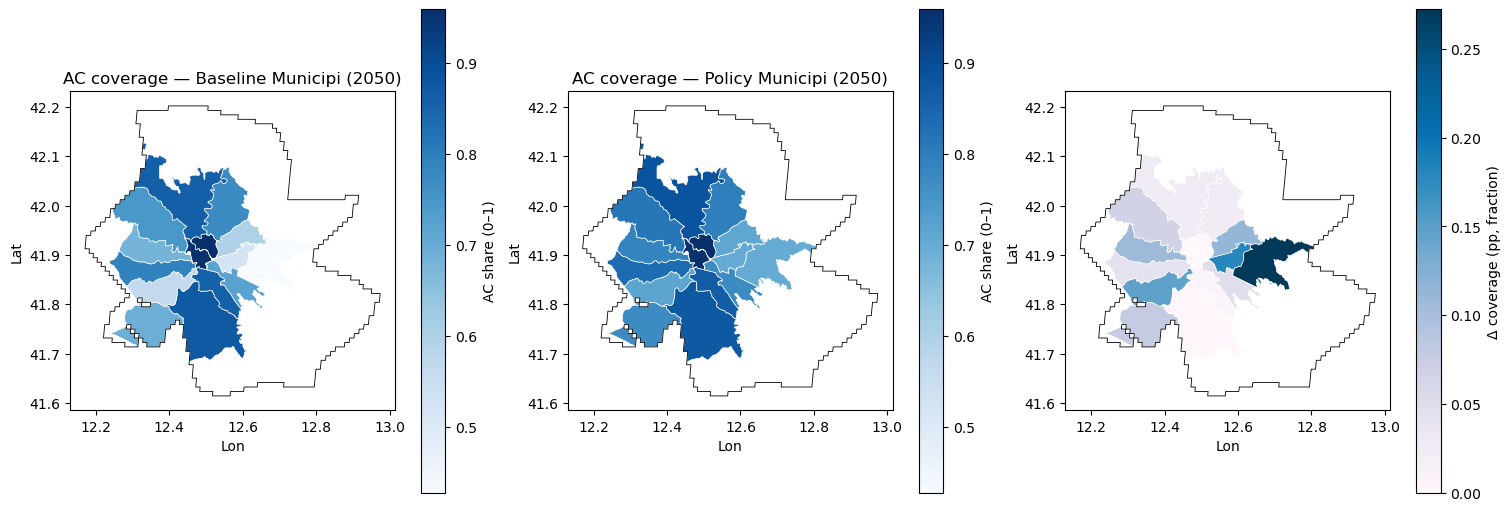

Wrote municipio coverage by year for CBA: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_cov_yearly.csv


In [137]:
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import rasterize

# municipio label raster on the CLIMADA grid (only build once)
if "muni_on_ref" not in globals():
    regions_ref = REGION_GDF.to_crs(ref_meta["crs"])
    shapes = [(geom, int(rid)) for geom, rid in zip(regions_ref.geometry, regions_ref[REGION_ID_FIELD])]
    muni_on_ref = rasterize(
        shapes=shapes,
        out_shape=ref_data.shape,
        transform=ref_meta["transform"],
        fill=-1, dtype="int32", all_touched=False
    )

def _wavg(x, w):
    w = np.asarray(w, float); x = np.asarray(x, float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

# for all years
all_muni_cov = []

for YEAR_DIAG in YEARS_AC:
    print(f"\n===== Municipi stats for year {YEAR_DIAG} =====")
    k_diag = year_to_index[YEAR_DIAG]

    # year-specific baseline and policy on the grid
    coverage_base_diag   = coverage_base_3d[k_diag].astype("float32")
    coverage_policy_diag = coverage_policy_3d[k_diag].astype("float32")

    # using year-specific population
    pop_grid_y = POP_GRID.get(YEAR_DIAG, pop_on_ref_base).astype(float)

    CAP_MASK_diag = (
        CAP_PIX &
        np.isfinite(coverage_base_diag) &
        np.isfinite(coverage_policy_diag)
    )

    mask = CAP_MASK_diag & (muni_on_ref >= 0)
    df = pd.DataFrame({
        "region_id": muni_on_ref[mask].ravel().astype(int),
        "pop":       pop_grid_y[mask].ravel().astype(float),
        "base":      coverage_base_diag[mask].ravel().astype(float),
        "policy":    coverage_policy_diag[mask].ravel().astype(float),
    })

    muni_cov = (df.groupby("region_id")
                  .apply(lambda g: pd.Series({
                      "ac_base":   _wavg(g["base"],   g["pop"]),
                      "ac_policy": _wavg(g["policy"], g["pop"]),
                      "pop_muni":  float(g["pop"].sum())
                  }))
                  .reset_index())

    muni_cov = (muni_cov
                .rename(columns={"region_id":"muni_id",
                                 "ac_base":"ac_base_muni",
                                 "ac_policy":"ac_policy_muni"})
                .assign(delta=lambda d: d["ac_policy_muni"] - d["ac_base_muni"],
                        delta_pp=lambda d: 100*(d["ac_policy_muni"] - d["ac_base_muni"])))

    # users
    dfm = df.copy()
    dfm = dfm.rename(columns={"region_id":"muni_id"})
    dfm["users_base"]   = dfm["base"]   * dfm["pop"]
    dfm["users_policy"] = dfm["policy"] * dfm["pop"]

    muni_pop   = dfm.groupby("muni_id", as_index=False)["pop"].sum().rename(columns={"pop":"pop_muni"})
    muni_users = (dfm.groupby("muni_id", as_index=False)
                    .agg(users_base=("users_base","sum"),
                         users_policy=("users_policy","sum")))

    # names
    name_cols = REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD]].rename(
        columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"}
    )

    muni_cov = (muni_cov
                .merge(muni_users, on="muni_id", how="left")
                .merge(name_cols,  on="muni_id", how="left"))

    muni_cov["muni_name"] = muni_cov["muni_name"].fillna(OUTSIDE_LABEL)

    # super important step for CBA 
    muni_cov_year = muni_cov.copy()
    muni_cov_year["year"] = YEAR_DIAG

    all_muni_cov.append(
        muni_cov_year[["year",
                       "muni_id",
                       "muni_name",
                       "pop_muni",
                       "ac_base_muni",
                       "ac_policy_muni"]]
    )

    # city average from Municipi vs grid
    # city average from Municipi vs grid (with year-specific pop)
    m_city = CAP_MASK_diag & (pop_grid_y > 0)
    w_city = pop_grid_y[m_city]
    x_base = coverage_base_diag[m_city]
    x_pol  = coverage_policy_diag[m_city]

    city_base = float(np.nansum(x_base * w_city) / np.nansum(w_city))
    city_pol  = float(np.nansum(x_pol  * w_city) / np.nansum(w_city))

    agg_base   = float(np.nansum(muni_cov["ac_base_muni"]   * muni_cov["pop_muni"])
                       / np.nansum(muni_cov["pop_muni"]))
    agg_policy = float(np.nansum(muni_cov["ac_policy_muni"] * muni_cov["pop_muni"])
                       / np.nansum(muni_cov["pop_muni"]))

    print(f"[QA {YEAR_DIAG}] City (grid) base={city_base:.3f} vs sum-over-Municipi={agg_base:.3f}")
    print(f"[QA {YEAR_DIAG}] City (grid) pol ={city_pol:.3f} vs sum-over-Municipi={agg_policy:.3f}")

    # tables
    muni_only = muni_cov[muni_cov["muni_id"] > 0].copy()
    muni_only["ac_base_pct"]   = 100*muni_only["ac_base_muni"]
    muni_only["ac_policy_pct"] = 100*muni_only["ac_policy_muni"]
    muni_only["delta_pp"]      = 100*muni_only["delta"]

    print("\nTop/bottom Municipi by Δ (policy - baseline), pp")
    top = muni_only.sort_values("delta_pp", ascending=False).head(10)
    bot = muni_only.sort_values("delta_pp", ascending=True).head(10)
    if _has_display:
        display(top[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp",
                     "pop_muni","users_base","users_policy"]].reset_index(drop=True))
        display(bot[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp",
                     "pop_muni","users_base","users_policy"]].reset_index(drop=True))
    else:
        print(top)
        print(bot)

    # maps
    muni_map = (REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD, "geometry"]]
                .rename(columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"})
                .merge(muni_only, on="muni_id", how="left"))

    vmin = float(np.nanmin(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))
    vmax = float(np.nanmax(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))
    dv   = float(np.nanmax(np.abs(muni_map["delta"])))

    fig, ax = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[0], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[0], column="ac_base_muni", cmap="Blues",
        vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"AC share (0–1)"}
    )
    ax[0].set_title(f"AC coverage — Baseline {PLOT_LABEL} ({YEAR_DIAG})")

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[1], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[1], column="ac_policy_muni", cmap="Blues",
        vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"AC share (0–1)"}
    )
    ax[1].set_title(f"AC coverage — Policy {PLOT_LABEL} ({YEAR_DIAG})")

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[2], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[2], column="delta", cmap="PuBu",
        vmin=0.0, vmax=dv, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"Δ coverage (pp, fraction)"}
    )
    for a in ax:
        a.set_xlabel("Lon"); a.set_ylabel("Lat")
    plt.show()
    
# municipio coverage by year for CBA: exporting here
if all_muni_cov:
    muni_cov_yearly = pd.concat(all_muni_cov, ignore_index=True)

    out_yearly = OUT / f"{SLUG}_muni_cov_yearly.csv"
    muni_cov_yearly.to_csv(out_yearly, index=False)
    print("Wrote municipio coverage by year for CBA:", out_yearly)

In [138]:
# Municipi coverage including UNIFORM AC policy

def _wavg(x, w):
    w = np.asarray(w, float); x = np.asarray(x, float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

all_muni_cov_allpol = []

for YEAR_DIAG in YEARS_AC:
    print(f"\n===== Municipi (all policies) for year {YEAR_DIAG} =====")
    k_diag = year_to_index[YEAR_DIAG]
    print("  k_diag:", k_diag)

    cov_base_y   = coverage_base_3d[k_diag].astype("float32")
    cov_income_y = coverage_policy_3d[k_diag].astype("float32")
    cov_unif_y   = coverage_uniform_3d[k_diag].astype("float32")

    pop_grid_y = POP_GRID.get(YEAR_DIAG, pop_on_ref_base).astype(float)

    # Shape sanity check
    print("  shapes:",
          "cov_base_y", cov_base_y.shape,
          "pop_grid_y", pop_grid_y.shape,
          "muni_on_ref", muni_on_ref.shape)

    CAP_MASK_diag = (
        CAP_PIX &
        np.isfinite(cov_base_y) &
        np.isfinite(cov_income_y) &
        np.isfinite(cov_unif_y)
    )

    print("  CAP_PIX true:", CAP_PIX.sum())
    print("  CAP_MASK_diag true:", CAP_MASK_diag.sum())

    mask = CAP_MASK_diag & (muni_on_ref >= 0)
    print("  mask true (valid pixels with muni_id >= 0):", mask.sum(), "out of", mask.size)

    df = pd.DataFrame({
        "muni_id": muni_on_ref[mask].ravel().astype(int),
        "pop":     pop_grid_y[mask].ravel().astype(float),
        "base":    cov_base_y[mask].ravel().astype(float),
        "income":  cov_income_y[mask].ravel().astype(float),
        "uniform": cov_unif_y[mask].ravel().astype(float),
    })

    print("  df rows:", len(df))
    print("  df head:")
    print(df.head())

    if df.empty:
        print("  !!! df is EMPTY for this year, skipping groupby")
        continue

    muni_cov = (df.groupby("muni_id")
                  .apply(lambda g: pd.Series({
                      "ac_base_muni":      _wavg(g["base"],    g["pop"]),
                      "ac_policy_income":  _wavg(g["income"],  g["pop"]),
                      "ac_policy_uniform": _wavg(g["uniform"], g["pop"]),
                      "pop_muni":          float(g["pop"].sum()),
                  }))
                  .reset_index())

    print("  muni_cov rows after groupby:", len(muni_cov))
    print("  muni_cov head:")
    print(muni_cov.head())

    name_cols = REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD]].rename(
        columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"}
    )
    muni_cov = muni_cov.merge(name_cols, on="muni_id", how="left")
    print("  muni_cov rows after merge:", len(muni_cov))
    print("  muni_name null count:", muni_cov["muni_name"].isna().sum())

    muni_cov["muni_name"] = muni_cov["muni_name"].fillna(OUTSIDE_LABEL)
    muni_cov["year"] = YEAR_DIAG

    # What we’re appending
    print("  appended columns:", ["year","muni_id","muni_name","pop_muni",
                                   "ac_base_muni","ac_policy_income","ac_policy_uniform"])

    all_muni_cov_allpol.append(
        muni_cov[["year","muni_id","muni_name","pop_muni",
                  "ac_base_muni","ac_policy_income","ac_policy_uniform"]]
    )

# concatenate and export
if all_muni_cov_allpol:
    muni_cov_yearly_allpol = pd.concat(all_muni_cov_allpol, ignore_index=True)
    print("\nTotal rows over all years:", len(muni_cov_yearly_allpol))
    print("Rows per year:")
    print(muni_cov_yearly_allpol.groupby("year")["muni_id"].nunique())

    out_yearly_all = OUT / f"{SLUG}_muni_cov_yearly_allpolicies.csv"
    muni_cov_yearly_allpol.to_csv(out_yearly_all, index=False)
    print("Wrote municipio coverage (baseline + income + uniform):", out_yearly_all)
else:
    print("No data accumulated in all_muni_cov_allpol – nothing to write.")


===== Municipi (all policies) for year 2020 =====
  k_diag: 0
  shapes: cov_base_y (301, 301) pop_grid_y (301, 301) muni_on_ref (301, 301)
  CAP_PIX true: 77929
  CAP_MASK_diag true: 77929
  mask true (valid pixels with muni_id >= 0): 77929 out of 90601
  df rows: 77929
  df head:
   muni_id   pop  base  income  uniform
0       14 0.914 0.645   0.700    0.748
1       14 0.851 0.645   0.700    0.748
2       14 0.660 0.645   0.700    0.748
3       14 2.307 0.645   0.700    0.748
4       14 4.293 0.645   0.700    0.748
  muni_cov rows after groupby: 16
  muni_cov head:
   muni_id  ac_base_muni  ac_policy_income  ac_policy_uniform    pop_muni
0        0         0.723             0.725              0.826 146,586.864
1        1         0.932             0.933              0.962 185,540.673
2        2         0.941             0.943              0.964 166,921.552
3        3         0.715             0.764              0.816 153,548.857
4        4         0.556             0.709              

## 4. BENEFITS CALCULATION (mortality model, baseline/policy deaths)

### 4.1 Mortality Model Setup

In [139]:
EFF_MAP = globals().get("EFF_BUCKETS", None)
if not isinstance(EFF_MAP, dict) or len(EFF_MAP) == 0:
    EFF_MAP = cfg.get("efficacy", {}) if "cfg" in globals() else {}

EFF_DEFAULT = float(globals().get("EFF_DEFAULT", EFF_MAP.get("default", 0.30)))

In [140]:
print("EFF_SCENARIO =", globals().get("EFF_SCENARIO", "(not set in globals)"))
print("EFF_DEFAULT  =", EFF_DEFAULT)
print("EFF_MAP      =", {k: EFF_MAP.get(k) for k in ["<15","15-64","65+"]})

EFF_SCENARIO = moderate
EFF_DEFAULT  = 0.3
EFF_MAP      = {'<15': 0.2, '15-64': 0.3, '65+': 0.4}


In [141]:
REGION_GDF        = globals().get("regions", muni)
REGION_ID_FIELD   = "muni_id"
REGION_NAME_FIELD = "muni_name"
OUTSIDE_LABEL     = "Fuori Municipi (FUA)"
mask_city = CITY_MASK

_id2name = dict(
    zip(
        REGION_GDF[REGION_ID_FIELD].astype(int),
        REGION_GDF[REGION_NAME_FIELD].astype(str),
    )
)

In [142]:
mask_city = CITY_MASK

In [143]:
def _interp_mdd(I_grid, f):
    return np.interp(I_grid, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

def _eff_for_age(age_lbl, eff_map, eff_default):
    if age_lbl in eff_map:
        return float(eff_map[age_lbl])
    for k, v in eff_map.items():
        if k == "default":
            continue
        if k in str(age_lbl):
            return float(v)
    return float(eff_default)

def deaths_with_ac(I_grid, coverage_grid, eff=0.30, age_ifs=None):
    """Uniform efficacy, one day."""
    # Use provided age_ifs or fall back to global reference year
    if age_ifs is None:
        age_ifs = age_ifs_by_year[MDD_REF_YEAR]
    
    m = mask_city & np.isfinite(I_grid)

    # fallback: city pop-weighted mean coverage for this grid
    ac_city_here = float(popw_mean(coverage_grid, CAP_MASK))

    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city_here)
    deaths = np.zeros_like(I_grid, dtype=float)
    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        mult = np.clip(1.0 - eff * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def deaths_with_ac_varage(I_grid, coverage_grid, eff_by_bucket=None, eff_base=None, age_ifs=None):
    """Age-varying efficacy, one day."""
    # Use provided age_ifs or fall back to global reference year
    if age_ifs is None:
        age_ifs = age_ifs_by_year[MDD_REF_YEAR]
    
    eff_map = (eff_by_bucket or EFF_MAP).copy()
    eff_def = EFF_DEFAULT if eff_base is None else float(eff_base)

    m = mask_city & np.isfinite(I_grid)
    ac_city_here = float(popw_mean(coverage_grid, CAP_MASK))
    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city_here)
    deaths = np.zeros_like(I_grid, dtype=float)

    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        eff_a = _eff_for_age(age_lbl, eff_map, eff_def)
        mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def _row_to_grid(intensity, i_ev, grid_shape):
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()

    n_cells  = row.size
    expected = grid_shape[0] * grid_shape[1]

    if n_cells == expected:
        return row.reshape(grid_shape)
    if n_cells == 1:
        val = row[0]
        return np.full(grid_shape, val, dtype=float)

    raise ValueError(f"Row size {n_cells} != grid cells {expected} and != 1")

### 4.2 Impact Calculation

In [144]:
EFF_UNIFORM = EFF_DEFAULT
EFF_BUCKETS = EFF_MAP

dates = pd.to_datetime(H.date)

YEARS_IMPACT = YEARS_AC  # [2020, 2030, 2040, 2050]

results_city   = []
results_muni_u = []
results_muni_a = []

for year_focus in YEARS_IMPACT:
    print(f"\n===== Year {year_focus} =====")

    # Year-specific population
    age_on_ref = AGE_GRID.get(year_focus, age_on_ref_base)
    pop_on_ref = POP_GRID.get(year_focus, pop_on_ref_base)
    
    # Year-specific impact functions (MDD already scaled in NB04!)
    age_ifs_year = get_age_ifs(year_focus)

    # Coverage maps for this year
    k = year_to_index[year_focus]
    coverage_base_y   = coverage_base_3d[k].astype(float)
    coverage_policy_y = coverage_policy_3d[k].astype(float)

    CAP_MASK = CAP_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # Hazard events for this year
    year_mask = (dates.year == year_focus)
    idx_year  = np.where(year_mask)[0]
    if idx_year.size == 0:
        print(f"  (no hazard events for {year_focus})")
        continue

    I_year = np.stack(
        [_row_to_grid(H.intensity, i_ev, ref_data.shape) for i_ev in idx_year],
        axis=0
    )

    # Daily deaths using year-specific IFs
    def deaths_series_uniform(I_series, coverage_grid, eff, age_ifs):
        out = np.zeros_like(I_series, dtype=float)
        for t in range(I_series.shape[0]):
            out[t] = deaths_with_ac(I_series[t], coverage_grid, eff=eff, age_ifs=age_ifs)
        return out

    def deaths_series_agevary(I_series, coverage_grid, eff_by_bucket, eff_base, age_ifs):
        out = np.zeros_like(I_series, dtype=float)
        for t in range(I_series.shape[0]):
            out[t] = deaths_with_ac_varage(
                I_series[t], coverage_grid,
                eff_by_bucket=eff_by_bucket, eff_base=eff_base, age_ifs=age_ifs
            )
        return out

    deaths_base_uni_day   = deaths_series_uniform(I_year, coverage_base_y,   eff=EFF_UNIFORM, age_ifs=age_ifs_year)
    deaths_policy_uni_day = deaths_series_uniform(I_year, coverage_policy_y, eff=EFF_UNIFORM, age_ifs=age_ifs_year)

    deaths_base_age_day   = deaths_series_agevary(I_year, coverage_base_y,   eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM, age_ifs=age_ifs_year)
    deaths_policy_age_day = deaths_series_agevary(I_year, coverage_policy_y, eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM, age_ifs=age_ifs_year)

    deaths_base_uni   = deaths_base_uni_day.sum(axis=0)
    deaths_policy_uni = deaths_policy_uni_day.sum(axis=0)
    deaths_base_age   = deaths_base_age_day.sum(axis=0)
    deaths_policy_age = deaths_policy_age_day.sum(axis=0)

    d_avo_uni = deaths_base_uni - deaths_policy_uni
    d_avo_age = deaths_base_age - deaths_policy_age

    # NO POST-HOC SCALING — MDD already includes baseline mortality scaling!
    city_total_avo_uni = float(np.nansum(d_avo_uni[mask_city]))
    city_total_avo_age = float(np.nansum(d_avo_age[mask_city]))

    print(f"City avoided deaths (uniform eff) in {year_focus}: {city_total_avo_uni:.3f}")
    print(f"City avoided deaths (age-varying eff) in {year_focus}: {city_total_avo_age:.3f}")

    # municipio delta AC and efficiency for this year
    df = pd.DataFrame({
        "muni_id":  muni_on_ref[CAP_MASK].ravel().astype(int),
        "pop":      pop_on_ref[CAP_MASK].ravel().astype(float),
        "base":     coverage_base_y[CAP_MASK].ravel().astype(float),
        "policy":   coverage_policy_y[CAP_MASK].ravel().astype(float),
    })

    df_muni_delta = (
        df.assign(delta=df["policy"] - df["base"])
          .groupby("muni_id", as_index=False)
          .apply(lambda g: pd.Series({
              "ΔAC_pw":       float(np.average(g["delta"], weights=g["pop"])) if g["pop"].sum() > 0 else np.nan,
              "pop_cap_mask": float(g["pop"].sum()),
          }))
          .reset_index(drop=True)
    )
    df_muni_delta["muni_name"] = df_muni_delta["muni_id"].map(_id2name)

    city_dpp_from_muni = 100.0 * (
        (df_muni_delta["ΔAC_pw"] * df_muni_delta["pop_cap_mask"]).sum()
        / df_muni_delta["pop_cap_mask"].sum()
    )
    city_dpp_from_map = 100.0 * popw_mean(coverage_policy_y - coverage_base_y, mask=CAP_MASK)
    print("City ΔAC (pp) from municipios vs map:", city_dpp_from_muni, city_dpp_from_map)

    # municipio-level avoided deaths for this year (uniform vs age-varying)
    # using same CAP_MASK: only pixels where baseline and policy coverage are defined
    mask_muni = CAP_MASK & (muni_on_ref >= 0)

    df_u = pd.DataFrame({
        "muni_id":     muni_on_ref[mask_muni].ravel().astype(int),
        "avoided":     d_avo_uni[mask_muni].ravel().astype(float),
        "deaths_base": deaths_base_uni[mask_muni].ravel().astype(float),
        "pop":         pop_on_ref[mask_muni].ravel().astype(float),
    })

    df_a = pd.DataFrame({
        "muni_id":     muni_on_ref[mask_muni].ravel().astype(int),
        "avoided":     d_avo_age[mask_muni].ravel().astype(float),
        "deaths_base": deaths_base_age[mask_muni].ravel().astype(float),
        "pop":         pop_on_ref[mask_muni].ravel().astype(float),
    })

    def _agg_muni(df_):
        out = (df_.groupby("muni_id", as_index=False)
                  .agg(avoided=("avoided", "sum"),
                       deaths_base=("deaths_base", "sum"),
                       pop_muni=("pop", "sum")))
        out["avo_per_100k"] = np.where(
            out["pop_muni"] > 0,
            1e5 * out["avoided"] / out["pop_muni"],
            np.nan
        )
        return out

    df_muni_avo_uni = _agg_muni(df_u)
    df_muni_avo_age = _agg_muni(df_a)

    # attach names so merge on ["muni_id","muni_name"] works
    df_muni_avo_uni["muni_name"] = df_muni_avo_uni["muni_id"].map(_id2name)
    df_muni_avo_age["muni_name"] = df_muni_avo_age["muni_id"].map(_id2name)

    MIN_PP = 0.5
    muni_eff_uni = (df_muni_avo_uni.merge(df_muni_delta, on=["muni_id", "muni_name"], how="left")
                    .assign(delta_pp=lambda d: 100 * d["ΔAC_pw"],
                            avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"] > 0, d["delta_pp"], np.nan),
                            flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

    muni_eff_age = (df_muni_avo_age.merge(df_muni_delta, on=["muni_id", "muni_name"], how="left")
                    .assign(delta_pp=lambda d: 100 * d["ΔAC_pw"],
                            avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"] > 0, d["delta_pp"], np.nan),
                            flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

    print("Top municipios (avoided per pp uplift) — uniform EFF:")
    display(muni_eff_uni.sort_values("avoided_per_pp", ascending=False)
            [["muni_id", "muni_name", "avoided", "avo_per_100k", "delta_pp", "avoided_per_pp"]]
            .head(10).reset_index(drop=True))

    print("Top municipios (avoided per pp uplift) — age-varying EFF:")
    display(muni_eff_age.sort_values("avoided_per_pp", ascending=False)
            [["muni_id", "muni_name", "avoided", "avo_per_100k", "delta_pp", "avoided_per_pp"]]
            .head(10).reset_index(drop=True))

    # if we want to use later: save results
    results_city.append({
        "year": year_focus,
        "city_total_avo_uni": city_total_avo_uni,
        "city_total_avo_age": city_total_avo_age,
    })
    results_muni_u.append(muni_eff_uni.assign(year=year_focus))
    results_muni_a.append(muni_eff_age.assign(year=year_focus))

# tables
results_city = pd.DataFrame(results_city).set_index("year").sort_index()
muni_eff_uni_all = pd.concat(results_muni_u, ignore_index=True)
muni_eff_age_all = pd.concat(results_muni_a, ignore_index=True)


===== Year 2020 =====
City avoided deaths (uniform eff) in 2020: 15.913
City avoided deaths (age-varying eff) in 2020: 20.440
City ΔAC (pp) from municipios vs map: 8.629558605348612 8.62955860534861
Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,1.798,0.700,7.355,0.244
1,9,Municipio Roma IX,0.191,0.085,0.974,0.196
2,1,Municipio Roma I,0.005,0.003,0.030,0.182
3,5,Municipio Roma V,3.130,1.682,21.635,0.145
4,8,Municipio Roma VIII,0.202,0.172,1.659,0.122
5,6,Municipio Roma VI,3.422,2.599,30.220,0.113
6,14,Municipio Roma XIV,0.995,0.607,8.935,0.111
7,0,Outside regions (FUA),0.012,0.008,0.112,0.108
8,2,Municipio Roma II,0.019,0.011,0.187,0.100
9,4,Municipio Roma IV,1.524,0.871,15.360,0.099


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,2.313,0.900,7.355,0.315
1,9,Municipio Roma IX,0.246,0.109,0.974,0.253
2,1,Municipio Roma I,0.007,0.004,0.030,0.234
3,5,Municipio Roma V,4.023,2.162,21.635,0.186
4,8,Municipio Roma VIII,0.260,0.221,1.659,0.157
5,6,Municipio Roma VI,4.401,3.342,30.220,0.146
6,14,Municipio Roma XIV,1.277,0.780,8.935,0.143
7,0,Outside regions (FUA),0.016,0.011,0.112,0.139
8,2,Municipio Roma II,0.024,0.014,0.187,0.129
9,4,Municipio Roma IV,1.954,1.117,15.360,0.127



===== Year 2030 =====
City avoided deaths (uniform eff) in 2030: 18.107
City avoided deaths (age-varying eff) in 2030: 23.506
City ΔAC (pp) from municipios vs map: 8.20762434173151 8.20762434173151
Top municipios (avoided per pp uplift) — uniform EFF:


...

,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,2.057,0.848,4.939,0.416
1,9,Municipio Roma IX,0.071,0.033,0.210,0.340
2,5,Municipio Roma V,4.533,2.579,18.003,0.252
3,8,Municipio Roma VIII,0.197,0.177,0.941,0.209
4,14,Municipio Roma XIV,1.329,0.858,6.764,0.196
5,6,Municipio Roma VI,5.331,4.284,27.243,0.196
6,0,Outside regions (FUA),0.018,0.013,0.095,0.185
7,2,Municipio Roma II,0.023,0.015,0.128,0.180
8,10,Municipio Roma X,1.398,0.648,7.859,0.178
9,4,Municipio Roma IV,1.995,1.207,11.394,0.175



===== Year 2050 =====
City avoided deaths (uniform eff) in 2050: 16.507
City avoided deaths (age-varying eff) in 2050: 21.816
City ΔAC (pp) from municipios vs map: 6.773282686167752 6.773282686167752
Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,1.560,0.656,4.939,0.316
1,9,Municipio Roma IX,0.054,0.026,0.210,0.257
2,5,Municipio Roma V,3.423,1.986,18.003,0.190
3,8,Municipio Roma VIII,0.150,0.137,0.941,0.159
4,6,Municipio Roma VI,4.036,3.307,27.243,0.148
5,14,Municipio Roma XIV,1.000,0.658,6.764,0.148
6,0,Outside regions (FUA),0.013,0.010,0.096,0.139
7,2,Municipio Roma II,0.017,0.011,0.128,0.135
8,10,Municipio Roma X,1.039,0.491,7.859,0.132
9,4,Municipio Roma IV,1.495,0.923,11.394,0.131


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,2.062,0.867,4.939,0.418
1,9,Municipio Roma IX,0.071,0.034,0.210,0.340
2,5,Municipio Roma V,4.525,2.625,18.003,0.251
3,8,Municipio Roma VIII,0.198,0.182,0.941,0.210
4,6,Municipio Roma VI,5.335,4.371,27.243,0.196
5,14,Municipio Roma XIV,1.321,0.870,6.764,0.195
6,0,Outside regions (FUA),0.018,0.013,0.096,0.183
7,2,Municipio Roma II,0.023,0.015,0.128,0.178
8,10,Municipio Roma X,1.372,0.649,7.859,0.175
9,4,Municipio Roma IV,1.975,1.219,11.394,0.173


In [145]:
import numpy as np
import pandas as pd

def deaths_year_by_age(year, coverage_grid, eff_by_bucket, eff_base=None, age_ifs=None):
    """
    For a given year and AC coverage grid, return a dict:
        { age_label -> annual deaths (absolute) }
    using age-varying efficacy (eff_by_bucket) and CLIMADA hazard H.
    
    If age_ifs is None, uses get_age_ifs(year) to get year-specific IFs.
    """
    # Get year-specific impact functions if not provided
    if age_ifs is None:
        age_ifs = get_age_ifs(year)
    
    dates = pd.to_datetime(H.date)
    mask_year = (dates.year == year)
    idx = np.where(mask_year)[0]

    if idx.size == 0:
        return {age_lbl: 0.0 for age_lbl in age_ifs.keys()}
        
    # where we actually model deaths
    m_city = mask_city & np.isfinite(pop_on_ref)

    # fill coverage holes with city mean (for this grid)
    cov_grid = np.where(m_city & np.isfinite(coverage_grid),
                        coverage_grid,
                        np.nan)
    # if some NaNs remain, replace by pop-weighted mean
    if np.isnan(cov_grid[m_city]).any():
        w = pop_on_ref[m_city].astype(float)
        x = np.nan_to_num(cov_grid[m_city], nan=0.0).astype(float)
        mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
        cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

    out = {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    # fix so eff_base=0.0 is not overwritten by EFF_DEFAULT
    if eff_base is None:
        eff_base_eff = EFF_DEFAULT
    else:
        eff_base_eff = eff_base

    for i_ev in idx:
        I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)

        m = m_city & np.isfinite(I_grid)
        if not np.any(m):
            continue

        cov = np.where(m, cov_grid, 0.0)

        for age_lbl, f in age_ifs.items():
            # efficacy for this age
            eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base_eff)

            # per-person per-day mortality at this day's temperature
            mdd = _interp_mdd(I_grid, f)

            # multiplicative protection from AC
            mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)

            pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)

            deaths_day = float(np.nansum(pop_age[m] * mdd[m] * mult[m]))
            out[age_lbl] += deaths_day

    return out

In [146]:
years = [2020, 2030, 2040, 2050]
rows = []

for year in years:
    # Year-specific population
    age_on_ref = AGE_GRID.get(year, age_on_ref_base)
    pop_on_ref = POP_GRID.get(year, pop_on_ref_base)
    
    # Year-specific impact functions (MDD already scaled!)
    age_ifs_year = get_age_ifs(year)
    
    k = year_to_index[year]
    cov_base_year = coverage_base_3d[k].astype(float)
    cov_policy_year = coverage_policy_3d[k].astype(float)
    cov_generic = np.zeros_like(cov_base_year, dtype=float)

    deaths_generic = deaths_year_by_age(
        year, cov_generic,
        eff_by_bucket=EFF_BUCKETS, eff_base=0.0,
        age_ifs=age_ifs_year,  # Pass year-specific IFs
    )

    deaths_citycurrAC = deaths_year_by_age(
        year, cov_base_year,
        eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM,
        age_ifs=age_ifs_year,  # Pass year-specific IFs
    )

    deaths_policyAC = deaths_year_by_age(
        year, cov_policy_year,
        eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM,
        age_ifs=age_ifs_year,  # Pass year-specific IFs
    )

    for age_lbl in age_ifs.keys():
        d_generic = deaths_generic[age_lbl]
        d_city    = deaths_citycurrAC[age_lbl]
        d_policy  = deaths_policyAC[age_lbl]

        rows.append({
            "year": year,
            "age_group": age_lbl,
            "deaths_generic":               d_generic,
            "deaths_citycurrAC":            d_city,
            "deaths_policyAC":              d_policy,
            "avoided_citycurrAC_vs_generic": d_generic - d_city,
            "avoided_policy_vs_generic":     d_generic - d_policy,
            "avoided_policy_vs_citycurrAC":  d_city    - d_policy,
        })

avoided_by_age = pd.DataFrame(rows).sort_values(["year","age_group"])

### Avoided-deaths (income-based policy)

In [147]:
for year in years:
    df_y = avoided_by_age[avoided_by_age["year"] == year]

    tot_generic = df_y["deaths_generic"].sum()
    tot_city    = df_y["deaths_citycurrAC"].sum()
    tot_policy  = df_y["deaths_policyAC"].sum()

    print(f"\nYear {year}")
    print(f"  Total deaths – generic:        {tot_generic:8.3f}")
    print(f"  Total deaths – city current AC:        {tot_city:8.3f}")
    print(f"  Total deaths – policy AC:              {tot_policy:8.3f}")
    print(f"  Avoided (city current AC vs generic):  {tot_generic - tot_city:8.3f}")
    print(f"  Avoided (policy AC vs generic):        {tot_generic - tot_policy:8.3f}")
    print(f"  Avoided (policy AC vs city current AC):{tot_city - tot_policy:8.3f}")


Year 2020
  Total deaths – generic:         642.408
  Total deaths – city current AC:         467.759
  Total deaths – policy AC:               447.320
  Avoided (city current AC vs generic):   174.649
  Avoided (policy AC vs generic):         195.089
  Avoided (policy AC vs city current AC):  20.440

Year 2030
  Total deaths – generic:         767.023
  Total deaths – city current AC:         553.395
  Total deaths – policy AC:               529.889
  Avoided (city current AC vs generic):   213.628
  Avoided (policy AC vs generic):         237.134
  Avoided (policy AC vs city current AC):  23.506

Year 2040
  Total deaths – generic:         854.491
  Total deaths – city current AC:         602.565
  Total deaths – policy AC:               580.660
  Avoided (city current AC vs generic):   251.925
  Avoided (policy AC vs generic):         273.830
  Avoided (policy AC vs city current AC):  21.905

Year 2050
  Total deaths – generic:         846.284
  Total deaths – city current AC:     

In [148]:
age_order = ["<15", "15-64", "65+"]

avoided_by_age["age_group"] = pd.Categorical(
    avoided_by_age["age_group"],
    categories=age_order,
    ordered=True
)

tab_ac = (
    avoided_by_age
    .pivot(index="year", columns="age_group", values="avoided_policy_vs_citycurrAC")
    .sort_index()
)

tab_ac["overall"] = tab_ac[age_order].sum(axis=1)

print(tab_ac.round(1))

out_dir = Path(INT)
tab_ac.to_csv(out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv")
print("Wrote:", out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv")

age_group   <15  15-64    65+  overall
year                                  
2020      0.100  2.100 18.200   20.400
2030      0.000  1.800 21.700   23.500
2040      0.000  1.000 20.900   21.900
2050      0.000  0.600 21.300   21.800
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_climada_avoided_AC_rome.csv


In [149]:
from pathlib import Path
from datetime import datetime
import json, re

out_dir = Path(INT)
out_dir.mkdir(parents=True, exist_ok=True)

sc_raw = globals().get("EFF_SCENARIO", "na")
sc = re.sub(r"[^a-zA-Z0-9._-]+", "-", str(sc_raw)).lower()
run_id = datetime.now().strftime("%Y%m%dT%H%M%S")

buckets = {k: float(v) for k, v in dict(EFF_BUCKETS).items()}

meta = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "run_id": run_id,
    "city": SLUG,
    "EFF_SCENARIO": sc_raw,
    "EFF_DEFAULT": float(EFF_DEFAULT),
    "EFF_BUCKETS": buckets,
}

# always save tab_ac
tab_latest = out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv"
tab_ver    = out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}_{sc}_{run_id}.csv"
tab_ac.to_csv(tab_latest)
tab_ac.to_csv(tab_ver)

# save summary only if it exists
summary_obj = globals().get("summary", None)
if summary_obj is not None:
    sum_latest = out_dir / f"ac_policy_city_summary_{SLUG}.csv"
    sum_ver    = out_dir / f"ac_policy_city_summary_{SLUG}_{sc}_{run_id}.csv"
    summary_obj.to_csv(sum_latest, index=True)
    summary_obj.to_csv(sum_ver, index=True)
else:
    print("Note: 'summary' not defined -> skipping summary CSV saves.")

meta_path = out_dir / f"ac_run_meta_{SLUG}_{sc}_{run_id}.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("Wrote:", tab_latest)
print("Wrote:", tab_ver)
print("Wrote:", meta_path)

Note: 'summary' not defined -> skipping summary CSV saves.
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_climada_avoided_AC_rome.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_climada_avoided_AC_rome_moderate_20260102T125308.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_run_meta_rome_moderate_20260102T125308.json


### Avoided-deaths (uniform policy)

In [150]:
# UNIFORM policy: annual deaths and avoided deaths
# (city total by age group)

years = YEARS_AC  # [2020, 2030, 2040, 2050]
rows_uniform = []

for year in years:
    # time-varying population/exposure
    age_on_ref = AGE_GRID.get(year, age_on_ref_base)
    pop_on_ref = POP_GRID.get(year, pop_on_ref_base)

    k = year_to_index[year]

    cov_base_year   = coverage_base_3d[k].astype(float)
    cov_uniform_year = coverage_uniform_3d[k].astype(float)

    # generic: no AC protection
    cov_generic = np.zeros_like(cov_base_year, dtype=float)

    deaths_generic = deaths_year_by_age(
        year,
        cov_generic,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=0.0,      # no AC
    )

    deaths_citycurrAC = deaths_year_by_age(
        year,
        cov_base_year,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=EFF_UNIFORM,
    )

    deaths_policy_uniform = deaths_year_by_age(
        year,
        cov_uniform_year,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=EFF_UNIFORM,
    )

    for age_lbl in age_ifs.keys():
        d_generic = deaths_generic[age_lbl]
        d_city    = deaths_citycurrAC[age_lbl]
        d_policy  = deaths_policy_uniform[age_lbl]

        rows_uniform.append({
            "year": year,
            "age_group": age_lbl,
            "deaths_generic":                d_generic,
            "deaths_citycurrAC":             d_city,
            "deaths_policyAC_uniform":       d_policy,
            "avoided_citycurrAC_vs_generic": d_generic - d_city,
            "avoided_uniform_vs_generic":    d_generic - d_policy,
            "avoided_uniform_vs_citycurrAC": d_city    - d_policy,
        })

avoided_by_age_uniform = (pd.DataFrame(rows_uniform)
                          .sort_values(["year","age_group"]))

for year in years:
    df_y = avoided_by_age_uniform[avoided_by_age_uniform["year"] == year]

    tot_generic = df_y["deaths_generic"].sum()
    tot_city    = df_y["deaths_citycurrAC"].sum()
    tot_policy  = df_y["deaths_policyAC_uniform"].sum()

    print(f"\n[UNIFORM] Year {year}")
    print(f"  Total deaths – generic:               {tot_generic:8.3f}")
    print(f"  Total deaths – city current AC:       {tot_city:8.3f}")
    print(f"  Total deaths – uniform AC policy:     {tot_policy:8.3f}")
    print(f"  Avoided (city current AC vs generic): {tot_generic - tot_city:8.3f}")
    print(f"  Avoided (uniform vs generic):         {tot_generic - tot_policy:8.3f}")
    print(f"  Avoided (uniform vs city current AC): {tot_city - tot_policy:8.3f}")

age_order = ["<15", "15-64", "65+"]

avoided_by_age_uniform["age_group"] = pd.Categorical(
    avoided_by_age_uniform["age_group"],
    categories=age_order,
    ordered=True
)

tab_ac_uniform = (
    avoided_by_age_uniform
    .pivot(index="year", columns="age_group", values="avoided_uniform_vs_citycurrAC")
    .sort_index()
)
tab_ac_uniform["overall"] = tab_ac_uniform[age_order].sum(axis=1)

print("\nUNIFORM policy — avoided deaths vs city current AC (by age):")
print(tab_ac_uniform.round(1))

out_dir = Path(INT)
tab_ac_uniform.to_csv(out_dir / f"annual_heat_deaths_climada_avoided_AC_uniform_{SLUG}.csv")
print("Wrote:", out_dir / f"annual_heat_deaths_climada_avoided_AC_uniform_{SLUG}.csv")


[UNIFORM] Year 2020
  Total deaths – generic:                642.408
  Total deaths – city current AC:        467.759
  Total deaths – uniform AC policy:      447.010
  Avoided (city current AC vs generic):  174.649
  Avoided (uniform vs generic):          195.399
  Avoided (uniform vs city current AC):   20.750

[UNIFORM] Year 2030
  Total deaths – generic:                767.023
  Total deaths – city current AC:        553.395
  Total deaths – uniform AC policy:      529.683
  Avoided (city current AC vs generic):  213.628
  Avoided (uniform vs generic):          237.340
  Avoided (uniform vs city current AC):   23.712

[UNIFORM] Year 2040
  Total deaths – generic:                854.491
  Total deaths – city current AC:        602.565
  Total deaths – uniform AC policy:      580.688
  Avoided (city current AC vs generic):  251.925
  Avoided (uniform vs generic):          273.803
  Avoided (uniform vs city current AC):   21.877

[UNIFORM] Year 2050
  Total deaths – generic:         

## 5. EQUITY ANALYSIS (vulnerability stratification, disparity reduction)

### 5.1 Vulnerability Stratification


DEATHS BY VULNERABILITY QUINTILE (with AC attenuation)
Loaded SVI grid: mean=0.572

[1] Deaths per 100k by Vulnerability Quintile (Baseline AC):
year       2020   2030   2040   2050
quintile                            
Q1-Low   16.510 20.260 22.590 22.720
Q2       17.350 21.200 23.600 23.760
Q3       17.780 21.700 24.160 24.340
Q4       17.870 21.870 24.370 24.550
Q5-High  18.160 22.250 24.900 25.080

[2] Deaths per 100k by Vulnerability Quintile (Income-targeted policy):
year       2020   2030   2040   2050
quintile                            
Q1-Low   15.850 19.480 21.880 22.010
Q2       16.750 20.500 22.980 23.130
Q3       17.230 21.060 23.570 23.740
Q4       17.100 20.960 23.510 23.670
Q5-High  16.990 20.840 23.470 23.630

[3] Deaths per 100k by Vulnerability Quintile (Uniform policy):
year       2020   2030   2040   2050
quintile                            
Q1-Low   15.710 19.300 21.660 21.780
Q2       16.530 20.250 22.700 22.850
Q3       17.010 20.800 23.330 23.500
Q4       17.0

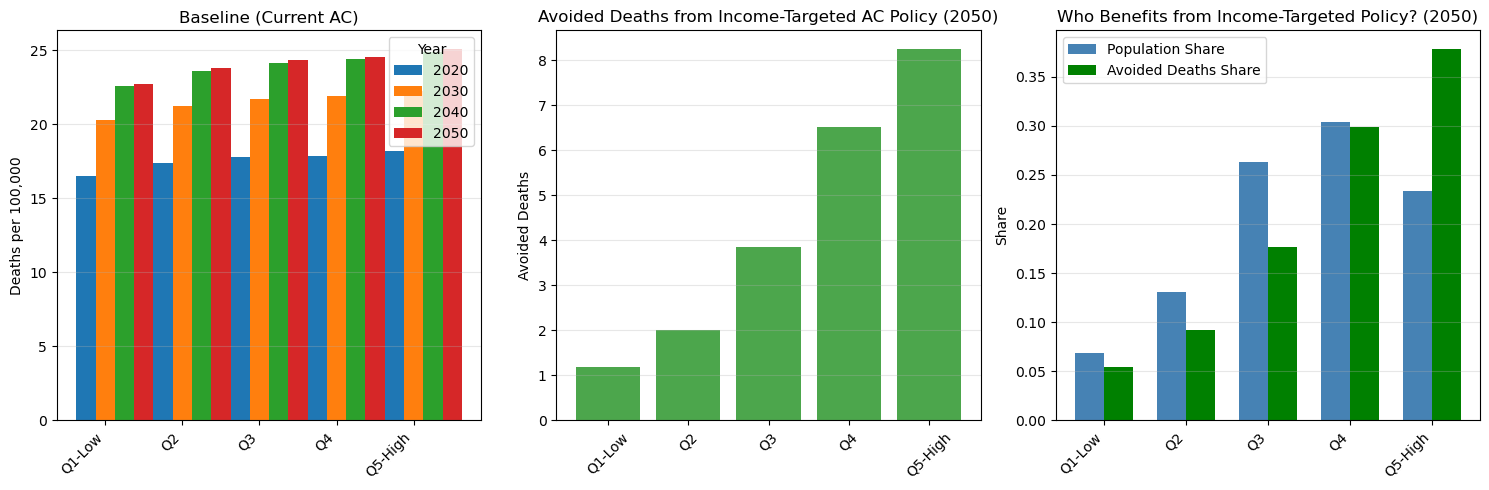

In [151]:
# Vulnerability-stratified impact analysis 
print("\n" + "="*60)
print("DEATHS BY VULNERABILITY QUINTILE (with AC attenuation)")
print("="*60)

# loading vulnerability grid
from cityheat.vulnerability_layer import load_vulnerability

try:
    vuln = load_vulnerability(INT, SLUG)
    svi_grid = vuln["svi"]  # same shape as ref grid (HGT×WDT)
    HAS_VULN = True
    print(f"Loaded SVI grid: mean={np.nanmean(svi_grid):.3f}")
except FileNotFoundError:
    HAS_VULN = False
    print("No vulnerability layer found.")

if HAS_VULN:
    quintile_labels = {1: "Q1-Low", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Q5-High"}

    # compute deaths pixel-by-pixel and then sum them by SVI quintile
    def deaths_year_by_quintile(year, coverage_grid, eff_by_bucket, eff_base=None, age_ifs=None):
        """
        Compute annual deaths per vulnerability quintile for a given year.

        Uses year-specific pop_on_ref and age_on_ref (set in the outer loop),
        builds SVI quintiles with pd.qcut on pixels with pop>0, and returns:
          - deaths_by_quintile: {label -> deaths}
          - deaths_grid: 2D array of deaths per pixel
          - pop_by_quintile: {label -> population}
        """
        # IMPORTANT: use year-specific IFs (scaled)
        if age_ifs is None:
            try:
                age_ifs = get_age_ifs(year)
            except NameError:
                # fallback if get_age_ifs isn't defined in this notebook
                age_ifs = age_ifs_by_year.get(int(year), age_ifs_by_year[MDD_REF_YEAR])

        # IMPORTANT: avoid truthiness bug when eff_base = 0.0
        eff0 = EFF_DEFAULT if eff_base is None else eff_base

        # make it a Series so we can use .dt
        dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
        year_idx = dates.dt.year.to_numpy(int)
        idx = np.where(year_idx == int(year))[0]

        if idx.size == 0:
            empty = {lbl: 0.0 for lbl in quintile_labels.values()}
            return empty, np.zeros_like(svi_grid, dtype=float), empty

        # year-specific city mask (only where we have population this year)
        pop_grid = pop_on_ref  # year-specific, set in the outer loop
        m_city = CITY_MASK & np.isfinite(pop_grid) & (pop_grid > 0)

        # valid pixels for SVI / pop
        valid = m_city & np.isfinite(svi_grid)
        svi_flat = svi_grid[valid].ravel()

        if svi_flat.size == 0:
            empty = {lbl: 0.0 for lbl in quintile_labels.values()}
            return empty, np.zeros_like(svi_grid, dtype=float), empty

        # row-based SVI quintiles for THIS year (equal-area, not pop-weighted)
        labels = [quintile_labels[i] for i in range(1, 6)]
        qcats = pd.qcut(svi_flat, 5, labels=labels)

        # put labels back onto full grid
        quintile_grid_lbl = np.full(svi_grid.shape, None, dtype=object)
        flat_idx = np.flatnonzero(valid.ravel())
        quintile_grid_lbl.ravel()[flat_idx] = qcats.astype(object)

        # fill AC coverage holes, weighted by this year's pop_grid
        cov_grid = np.where(m_city & np.isfinite(coverage_grid), coverage_grid, np.nan)
        if np.isnan(cov_grid[m_city]).any():
            w = pop_grid[m_city].astype(float)
            x = np.nan_to_num(cov_grid[m_city], nan=0.0)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

        deaths_grid = np.zeros_like(svi_grid, dtype=float)

        for i_ev in idx:
            I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)
            m = m_city & np.isfinite(I_grid)
            if not np.any(m):
                continue

            cov = np.where(m, cov_grid, 0.0)

            for age_lbl, f in age_ifs.items():
                eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff0)
                mdd = _interp_mdd(I_grid, f)
                mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
                pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)  # year-specific
                deaths_grid += np.where(m, pop_age * mdd * mult, 0.0)

        # aggregate deaths and pop by quintile label
        deaths_by_quintile = {}
        pop_by_quintile = {}
        for lbl in quintile_labels.values():
            mask_q = m_city & (quintile_grid_lbl == lbl)
            deaths_by_quintile[lbl] = float(np.nansum(deaths_grid[mask_q]))
            pop_by_quintile[lbl]    = float(np.nansum(pop_grid[mask_q]))

        return deaths_by_quintile, deaths_grid, pop_by_quintile

    # compute for all years/scenarios
    vuln_results = []

    for year in [2020, 2030, 2040, 2050]:
        # year-specific age and population
        age_on_ref = AGE_GRID.get(year, age_on_ref_base)
        pop_on_ref = POP_GRID.get(year, pop_on_ref_base)

        # year-specific scaled IFs (avoid accidentally using ref-year IFs)
        age_ifs_year = get_age_ifs(year)

        k = year_to_index[year]
        cov_base    = coverage_base_3d[k].astype(float)
        cov_policy  = coverage_policy_3d[k].astype(float)
        cov_uniform = coverage_uniform_3d[k].astype(float)  # uniform policy

        # baseline: get deaths + population per quintile (for this year)
        deaths_base, _, pop_by_quintile_year = deaths_year_by_quintile(
            year, cov_base, EFF_BUCKETS, EFF_UNIFORM, age_ifs=age_ifs_year
        )

        # income-targeted AC policy
        deaths_policy, _, _ = deaths_year_by_quintile(
            year, cov_policy, EFF_BUCKETS, EFF_UNIFORM, age_ifs=age_ifs_year
        )

        # uniform AC policy
        deaths_unif, _, _ = deaths_year_by_quintile(
            year, cov_uniform, EFF_BUCKETS, EFF_UNIFORM, age_ifs=age_ifs_year
        )

        # assemble rows using year-specific pop_by_quintile_year
        for lbl in quintile_labels.values():
            pop = pop_by_quintile_year[lbl]
            vuln_results.append({
                "year": year,
                "quintile": lbl,
                "pop": pop,
                "deaths_baseline": deaths_base[lbl],
                "deaths_policy": deaths_policy[lbl],
                "deaths_policy_uniform": deaths_unif[lbl],
                "avoided_income_vs_base":    deaths_base[lbl] - deaths_policy[lbl],
                "avoided_uniform_vs_base":   deaths_base[lbl] - deaths_unif[lbl],
                "avoided_uniform_vs_income": deaths_policy[lbl] - deaths_unif[lbl],
                "deaths_per_100k_baseline":  deaths_base[lbl]  / pop * 1e5 if pop > 0 else 0.0,
                "deaths_per_100k_income":    deaths_policy[lbl]/ pop * 1e5 if pop > 0 else 0.0,
                "deaths_per_100k_uniform":   deaths_unif[lbl]  / pop * 1e5 if pop > 0 else 0.0,
            })

    vuln_df = pd.DataFrame(vuln_results)

    # summary tables and disparity
    print("\n[1] Deaths per 100k by Vulnerability Quintile (Baseline AC):")
    baseline_pivot = vuln_df.pivot(index="quintile", columns="year",
                                   values="deaths_per_100k_baseline")
    print(baseline_pivot.round(2))

    print("\n[2] Deaths per 100k by Vulnerability Quintile (Income-targeted policy):")
    income_pivot = vuln_df.pivot(index="quintile", columns="year",
                                 values="deaths_per_100k_income")
    print(income_pivot.round(2))

    print("\n[3] Deaths per 100k by Vulnerability Quintile (Uniform policy):")
    uniform_pivot = vuln_df.pivot(index="quintile", columns="year",
                                  values="deaths_per_100k_uniform")
    print(uniform_pivot.round(2))

    print("\n[4] Avoided deaths vs baseline (Income-targeted policy):")
    avoided_income_pivot = vuln_df.pivot(index="quintile", columns="year",
                                         values="avoided_income_vs_base")
    print(avoided_income_pivot.round(2))

    print("\n[5] Avoided deaths vs baseline (Uniform policy):")
    avoided_uniform_pivot = vuln_df.pivot(index="quintile", columns="year",
                                          values="avoided_uniform_vs_base")
    print(avoided_uniform_pivot.round(2))

    print("\n[6] Q5/Q1 disparity ratios (baseline vs income vs uniform):")
    for year in [2020, 2030, 2040, 2050]:
        df_y = vuln_df[vuln_df["year"] == year]

        def ratio(col):
            q5 = df_y.loc[df_y["quintile"] == "Q5-High", col].iloc[0]
            q1 = df_y.loc[df_y["quintile"] == "Q1-Low",  col].iloc[0]
            return q5 / q1 if q1 != 0 else np.nan

        r_base    = ratio("deaths_per_100k_baseline")
        r_income  = ratio("deaths_per_100k_income")
        r_uniform = ratio("deaths_per_100k_uniform")

        print(f"  {year}: baseline={r_base:.2f}×, "
              f"income={r_income:.2f}×, uniform={r_uniform:.2f}×")

    out_path = INT / f"deaths_by_vulnerability_quintile_{SLUG}.csv"
    vuln_df.to_csv(out_path, index=False)
    print("\n Saved:", out_path)

    # visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    quintiles = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    x = np.arange(len(quintiles))
    width = 0.25

    # panel 1: Baseline deaths by quintile
    for i, year in enumerate([2020, 2030, 2040, 2050]):
        rates = baseline_pivot.loc[quintiles, year].values
        axes[0].bar(x + i*width, rates, width, label=str(year))
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(quintiles, rotation=45, ha='right')
    axes[0].set_ylabel("Deaths per 100,000")
    axes[0].set_title("Baseline (Current AC)")
    axes[0].legend(title="Year")
    axes[0].grid(axis='y', alpha=0.3)

    # panel 2: Avoided deaths by quintile (2050, income-targeted policy)
    avoided_2050 = (
        vuln_df[vuln_df["year"] == 2050]
        .set_index("quintile")
        .loc[quintiles, "avoided_income_vs_base"]
    )
    axes[1].bar(quintiles, avoided_2050.values, color='green', alpha=0.7)
    axes[1].set_ylabel("Avoided Deaths")
    axes[1].set_title("Avoided Deaths from Income-Targeted AC Policy (2050)")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # panel 3: Population share vs avoided deaths share (income-targeted policy)
    pop_2050 = (
        vuln_df[vuln_df["year"] == 2050]
        .set_index("quintile")
        .loc[quintiles, "pop"]
        .values
    )
    pop_share = pop_2050 / pop_2050.sum()
    avoided_share = avoided_2050.values / avoided_2050.sum()

    x = np.arange(5)
    width = 0.35
    axes[2].bar(x - width/2, pop_share, width, label="Population Share", color="steelblue")
    axes[2].bar(x + width/2, avoided_share, width, label="Avoided Deaths Share", color="green")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(quintiles, rotation=45, ha='right')
    axes[2].set_ylabel("Share")
    axes[2].set_title("Who Benefits from Income-Targeted Policy? (2050)")
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT / f"vulnerability_stratified_AC_{SLUG}.png", dpi=150)
    plt.show()


DEATHS BY POP-WEIGHTED VULNERABILITY QUINTILE (with AC attenuation)

Pop-weighted SVI quintile population (2020):
  Q1-Low: 526791
  Q2: 526790
  Q3: 526787
  Q4: 526826
  Q5-High: 526846

Pop-weighted SVI quintile population (2030):
  Q1-Low: 509431
  Q2: 509491
  Q3: 509492
  Q4: 509389
  Q5-High: 509586

Pop-weighted SVI quintile population (2040):
  Q1-Low: 497532
  Q2: 497471
  Q3: 497564
  Q4: 497507
  Q5-High: 497621

Pop-weighted SVI quintile population (2050):
  Q1-Low: 487772
  Q2: 487867
  Q3: 487770
  Q4: 487829
  Q5-High: 487862

[1-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Baseline AC):
year       2020   2030   2040   2050
quintile                            
Q1-Low   17.060 24.210 30.750 30.820
Q2       17.830 25.240 32.020 32.120
Q3       17.400 24.700 31.360 31.430
Q4       18.380 26.080 33.160 33.260
Q5-High  18.100 25.720 32.810 32.890

[2-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Income-targeted policy):
year       2020   2030   

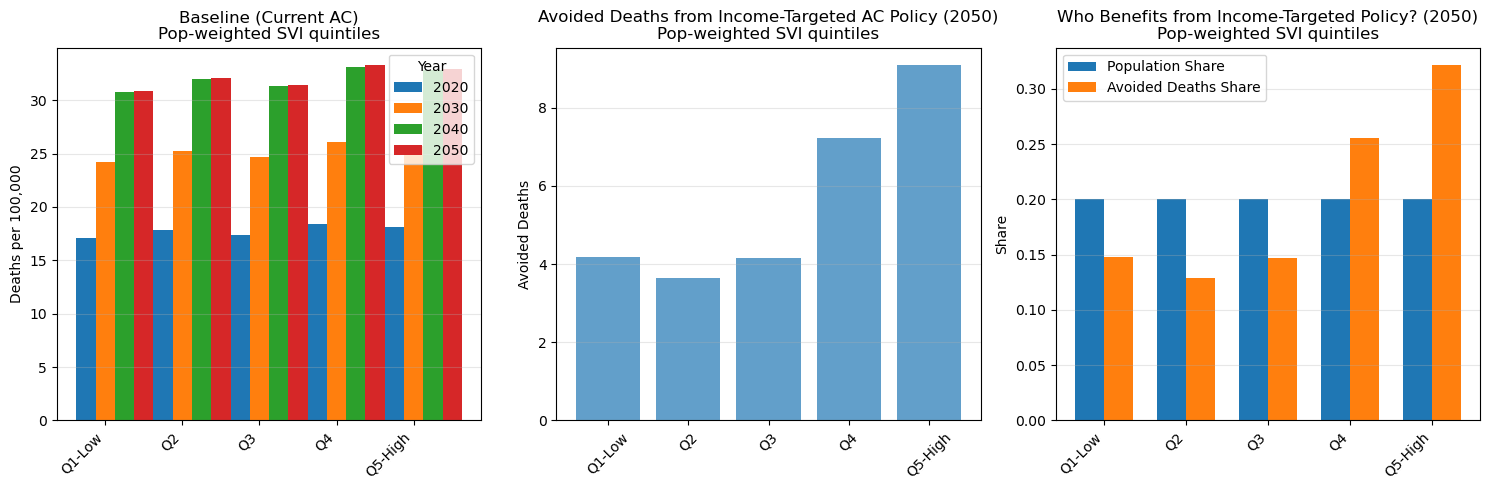

In [152]:
# Vulnerability-stratified impact analysis (POP-WEIGHTED SVI quintiles)
print("\n" + "="*60)
print("DEATHS BY POP-WEIGHTED VULNERABILITY QUINTILE (with AC attenuation)")
print("="*60)

if HAS_VULN:
    # labels and bins 
    label_order = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    quintile_labels_pop = {i + 1: lbl for i, lbl in enumerate(label_order)}

    def build_pop_weighted_quintile_grid(pop_grid):
        """
        Build *population-weighted* SVI quintile grid for a given year's population.
        - sort locations by SVI,
        - accumulate population,
        - split into 5 groups each holding 20% of total population.
        """
        valid_mask = (
            CITY_MASK &
            np.isfinite(svi_grid) &
            np.isfinite(pop_grid) &
            (pop_grid > 0)
        )

        svi_flat = svi_grid[valid_mask].astype(float)
        pop_flat = pop_grid[valid_mask].astype(float)

        if svi_flat.size == 0 or pop_flat.sum() == 0:
            raise ValueError(
                "No valid (SVI, population) pixels to build pop-weighted SVI quintiles."
            )

        # sort by SVI
        order = np.argsort(svi_flat)
        svi_sorted = svi_flat[order]
        pop_sorted = pop_flat[order]

        # cumulative population fraction
        cum_pop = np.cumsum(pop_sorted)
        total_pop = cum_pop[-1]
        cum_pop_frac = cum_pop / total_pop  # goes from (0,1]

        # unsort cumulative fraction back to original valid-pixel order
        cum_pop_frac_unsorted = np.empty_like(cum_pop_frac)
        cum_pop_frac_unsorted[order] = cum_pop_frac

        # assign pop-weighted quintiles (labels) to valid pixels
        quintile_cat = pd.cut(
            cum_pop_frac_unsorted,
            bins=bins,
            labels=label_order,
            include_lowest=True,
        )

        # map labels back onto full grid
        quintile_grid_pop = np.full(svi_grid.size, np.nan, dtype=object)
        flat_idx_valid = np.flatnonzero(valid_mask.ravel())
        quintile_grid_pop[flat_idx_valid] = quintile_cat.astype(object)
        quintile_grid_pop = quintile_grid_pop.reshape(svi_grid.shape)

        # convert to integer codes 1–5 for convenience
        label_to_int = {lbl: i + 1 for i, lbl in enumerate(label_order)}
        quintile_grid_pop_int = np.full(svi_grid.shape, np.nan, dtype=float)
        for lbl, code in label_to_int.items():
            mask_lbl = (quintile_grid_pop == lbl)
            quintile_grid_pop_int[mask_lbl] = float(code)

        return quintile_grid_pop_int

    def deaths_year_by_pop_quintile(year, coverage_grid, quintile_grid_pop_int,
                                    eff_by_bucket, eff_base=None, pop_grid=None):
        """
        Compute annual deaths per *population-weighted* SVI quintile for a given year.

        pop_grid: population grid to use for weighting coverage gaps (usually the same
                  grid used in build_pop_weighted_quintile_grid for that year).
        """
        if pop_grid is None:
            pop_grid = pop_on_ref  # fallback, keeps backward compatibility

        dates = pd.to_datetime(H.date)
        mask_year = (dates.year == year)
        idx = np.where(mask_year)[0]

        if idx.size == 0:
            return {lbl: 0.0 for lbl in quintile_labels_pop.values()}, np.zeros_like(svi_grid, dtype=float)

        # use pop_grid for city mask and weighting
        m_city = CITY_MASK & np.isfinite(pop_grid)

        # fill coverage gaps with population-weighted mean (using pop_grid)
        cov_grid = np.where(m_city & np.isfinite(coverage_grid), coverage_grid, np.nan)
        if np.isnan(cov_grid[m_city]).any():
            w = pop_grid[m_city].astype(float)
            x = np.nan_to_num(cov_grid[m_city], nan=0.0)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

        deaths_grid = np.zeros_like(svi_grid, dtype=float)

        for i_ev in idx:
            I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)
            m = m_city & np.isfinite(I_grid)
            if not np.any(m):
                continue

            cov = np.where(m, cov_grid, 0.0)

            for age_lbl, f in age_ifs.items():
                eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base or EFF_DEFAULT)
                mdd = _interp_mdd(I_grid, f)
                mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
                pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
                deaths_grid += np.where(m, pop_age * mdd * mult, 0.0)

        result = {}
        for q, lbl in quintile_labels_pop.items():
            mask_q = CITY_MASK & (quintile_grid_pop_int == q)
            result[lbl] = float(np.nansum(deaths_grid[mask_q]))

        return result, deaths_grid

    # computing for all years and scenarios 
    vuln_results_pop = []

    for year in [2020, 2030, 2040, 2050]:
        # year-specific demography
        age_on_ref = AGE_GRID.get(year, age_on_ref_base)
        pop_on_ref = POP_GRID.get(year, pop_on_ref_base)

        # build pop-weighted SVI quintiles *for this year's population*
        quintile_grid_pop_int = build_pop_weighted_quintile_grid(pop_on_ref)

        # coverage slices for this year
        k = year_to_index[year]
        cov_base    = coverage_base_3d[k].astype(float)
        cov_income  = coverage_policy_3d[k].astype(float)    # income-targeted AC
        cov_uniform = coverage_uniform_3d[k].astype(float)   # uniform AC policy

        # population per pop-weighted quintile (for this year's population)
        pop_by_quintile_pop = {}
        for q, lbl in quintile_labels_pop.items():
            mask_q = CITY_MASK & (quintile_grid_pop_int == q)
            pop_by_quintile_pop[lbl] = float(np.nansum(pop_on_ref[mask_q]))

        print(f"\nPop-weighted SVI quintile population ({year}):")
        for lbl in label_order:
            print(f"  {lbl}: {pop_by_quintile_pop[lbl]:.0f}")

        # deaths under each AC scenario (using year-specific quintile grid)
        deaths_base_pop,    _ = deaths_year_by_pop_quintile(
            year, cov_base,    quintile_grid_pop_int, EFF_BUCKETS, EFF_UNIFORM, pop_grid=pop_on_ref
        )
        deaths_income_pop,  _ = deaths_year_by_pop_quintile(
            year, cov_income,  quintile_grid_pop_int, EFF_BUCKETS, EFF_UNIFORM, pop_grid=pop_on_ref
        )
        deaths_uniform_pop, _ = deaths_year_by_pop_quintile(
            year, cov_uniform, quintile_grid_pop_int, EFF_BUCKETS, EFF_UNIFORM, pop_grid=pop_on_ref
        )

        # assemble rows
        for lbl in label_order:
            pop_q = pop_by_quintile_pop[lbl]
            vuln_results_pop.append({
                "year": year,
                "quintile": lbl,
                "pop": pop_q,
                "deaths_baseline": deaths_base_pop[lbl],
                "deaths_income":   deaths_income_pop[lbl],
                "deaths_uniform":  deaths_uniform_pop[lbl],
                "avoided_income_vs_base":    deaths_base_pop[lbl] - deaths_income_pop[lbl],
                "avoided_uniform_vs_base":   deaths_base_pop[lbl] - deaths_uniform_pop[lbl],
                "avoided_uniform_vs_income": deaths_income_pop[lbl] - deaths_uniform_pop[lbl],
                "deaths_per_100k_baseline":  deaths_base_pop[lbl]   / pop_q * 1e5 if pop_q > 0 else 0.0,
                "deaths_per_100k_income":    deaths_income_pop[lbl] / pop_q * 1e5 if pop_q > 0 else 0.0,
                "deaths_per_100k_uniform":   deaths_uniform_pop[lbl]/ pop_q * 1e5 if pop_q > 0 else 0.0,
            })

    vuln_df_pop = pd.DataFrame(vuln_results_pop)

    # summary tables (pop-weighted) 
    print("\n[1-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Baseline AC):")
    baseline_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                           values="deaths_per_100k_baseline")
    print(baseline_pivot_pop.round(2))

    print("\n[2-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Income-targeted policy):")
    income_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                         values="deaths_per_100k_income")
    print(income_pivot_pop.round(2))

    print("\n[3-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Uniform policy):")
    uniform_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                          values="deaths_per_100k_uniform")
    print(uniform_pivot_pop.round(2))

    print("\n[4-PW] Avoided deaths vs baseline (Income-targeted policy, pop-weighted):")
    avoided_income_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                                 values="avoided_income_vs_base")
    print(avoided_income_pivot_pop.round(2))

    print("\n[5-PW] Avoided deaths vs baseline (Uniform policy, pop-weighted):")
    avoided_uniform_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                                  values="avoided_uniform_vs_base")
    print(avoided_uniform_pivot_pop.round(2))

    print("\n[6-PW] Avoided deaths: Uniform vs Income-targeted (pop-weighted):")
    avoided_uniform_vs_income_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                                            values="avoided_uniform_vs_income")
    print(avoided_uniform_vs_income_pivot_pop.round(2))

    # Q5/Q1 disparity ratios for pop-weighted SVI
    print("\n[7-PW] Q5/Q1 disparity ratios (baseline vs income vs uniform, POP-WEIGHTED SVI):")
    for year in [2020, 2030, 2040, 2050]:
        df_y = vuln_df_pop[vuln_df_pop["year"] == year]

        def ratio(col):
            q5 = df_y.loc[df_y["quintile"] == "Q5-High", col].iloc[0]
            q1 = df_y.loc[df_y["quintile"] == "Q1-Low",  col].iloc[0]
            return q5 / q1 if q1 != 0 else np.nan

        r_base    = ratio("deaths_per_100k_baseline")
        r_income  = ratio("deaths_per_100k_income")
        r_uniform = ratio("deaths_per_100k_uniform")

        print(f"  {year}: baseline={r_base:.2f}×, "
              f"income={r_income:.2f}×, uniform={r_uniform:.2f}×")

    # save + visualization 
    out_path_pw = INT / f"deaths_by_vulnerability_quintile_popweighted_{SLUG}.csv"
    vuln_df_pop.to_csv(out_path_pw, index=False)
    print("\n Saved (pop-weighted):", out_path_pw)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    quintiles_pw = label_order
    x = np.arange(len(quintiles_pw))
    width = 0.25

    # panel 1: Baseline deaths per 100k by pop-weighted quintile
    for i, year in enumerate([2020, 2030, 2040, 2050]):
        rates = baseline_pivot_pop.loc[quintiles_pw, year].values
        axes[0].bar(x + i * width, rates, width, label=str(year))
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(quintiles_pw, rotation=45, ha='right')
    axes[0].set_ylabel("Deaths per 100,000")
    axes[0].set_title("Baseline (Current AC)\nPop-weighted SVI quintiles")
    axes[0].legend(title="Year")
    axes[0].grid(axis='y', alpha=0.3)

    # panel 2: Avoided deaths by pop-weighted quintile (2050, income-targeted)
    avoided_2050_pw_income = (
        vuln_df_pop[vuln_df_pop["year"] == 2050]
        .set_index("quintile")
        .loc[quintiles_pw, "avoided_income_vs_base"]
    )
    axes[1].bar(quintiles_pw, avoided_2050_pw_income.values, alpha=0.7)
    axes[1].set_ylabel("Avoided Deaths")
    axes[1].set_title("Avoided Deaths from Income-Targeted AC Policy (2050)\nPop-weighted SVI quintiles")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # panel 3: Population share vs avoided deaths share (income-targeted, 2050)
    pop_share_pw = np.array([
        vuln_df_pop[(vuln_df_pop["year"] == 2050) &
                    (vuln_df_pop["quintile"] == q)]["pop"].iloc[0]
        for q in quintiles_pw
    ])
    pop_share_pw = pop_share_pw / pop_share_pw.sum()
    avoided_share_pw = avoided_2050_pw_income.values / avoided_2050_pw_income.values.sum()

    x2 = np.arange(5)
    width2 = 0.35
    axes[2].bar(x2 - width2/2, pop_share_pw, width2, label="Population Share")
    axes[2].bar(x2 + width2/2, avoided_share_pw, width2, label="Avoided Deaths Share")
    axes[2].set_xticks(x2)
    axes[2].set_xticklabels(quintiles_pw, rotation=45, ha='right')
    axes[2].set_ylabel("Share")
    axes[2].set_title("Who Benefits from Income-Targeted Policy? (2050)\nPop-weighted SVI quintiles")
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT / f"vulnerability_stratified_AC_popweighted_{SLUG}.png", dpi=150)
    plt.show()

else:
    print("No vulnerability layer found (HAS_VULN=False) – skipping pop-weighted analysis.")

In [153]:
for year in [2020, 2030, 2040, 2050]:
    pop_on_ref = POP_GRID.get(year, pop_on_ref_base)
    q_int = build_pop_weighted_quintile_grid(pop_on_ref)

    # total pop in city
    total_city_pop = float(np.nansum(pop_on_ref[CITY_MASK]))

    # pop per quintile
    pop_by_q = {}
    for q, lbl in quintile_labels_pop.items():
        mask_q = CITY_MASK & (q_int == q)
        pop_by_q[lbl] = float(np.nansum(pop_on_ref[mask_q]))

    total_quintile_pop = sum(pop_by_q.values())

    # pop lost due to missing SVI
    missing_svi_pop = float(np.nansum(pop_on_ref[CITY_MASK & ~np.isfinite(svi_grid)]))

    print(f"\nYear {year}")
    print("  total city population:       ", total_city_pop)
    print("  sum over quintiles:          ", total_quintile_pop)
    print("  diff (city - quintiles):     ", total_city_pop - total_quintile_pop)
    print("  pop in cells with SVI NaN:   ", missing_svi_pop)
    print("  quintiles (should be ~20% each):")
    for lbl in label_order:
        print(f"    {lbl}: {pop_by_q[lbl]:.0f}")


Year 2020
  total city population:        2634831.0
  sum over quintiles:           2634039.9375
  diff (city - quintiles):      791.0625
  pop in cells with SVI NaN:    791.2591552734375
  quintiles (should be ~20% each):
    Q1-Low: 526791
    Q2: 526790
    Q3: 526787
    Q4: 526826
    Q5-High: 526846

Year 2030
  total city population:        2548154.0
  sum over quintiles:           2547389.375
  diff (city - quintiles):      764.625
  pop in cells with SVI NaN:    764.524169921875
  quintiles (should be ~20% each):
    Q1-Low: 509431
    Q2: 509491
    Q3: 509492
    Q4: 509389
    Q5-High: 509586

Year 2040
  total city population:        2488442.5
  sum over quintiles:           2487695.46875
  diff (city - quintiles):      747.03125
  pop in cells with SVI NaN:    746.9310302734375
  quintiles (should be ~20% each):
    Q1-Low: 497532
    Q2: 497471
    Q3: 497564
    Q4: 497507
    Q5-High: 497621

Year 2050
  total city population:        2439832.25
  sum over quintiles:  

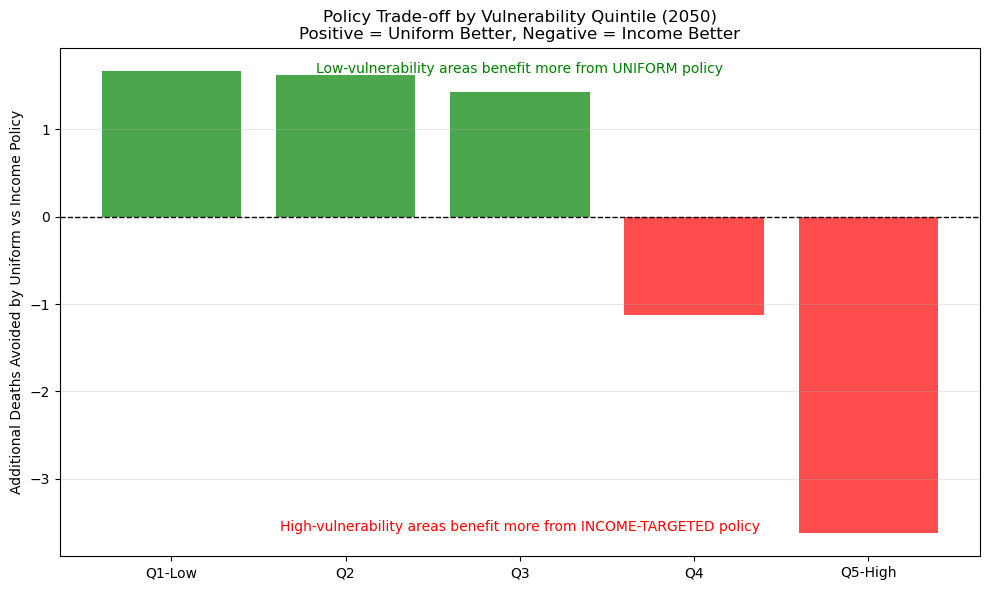

In [154]:
# Trade-off plot: Who wins/loses from income-targeting?
fig, ax = plt.subplots(figsize=(10, 6))

quintiles = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
diff_2050 = vuln_df_pop[vuln_df_pop["year"] == 2050].set_index("quintile").loc[quintiles, "avoided_uniform_vs_income"]

colors = ['green' if x > 0 else 'red' for x in diff_2050.values]
ax.bar(quintiles, diff_2050.values, color=colors, alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel("Additional Deaths Avoided by Uniform vs Income Policy")
ax.set_title("Policy Trade-off by Vulnerability Quintile (2050)\nPositive = Uniform Better, Negative = Income Better")
ax.grid(axis='y', alpha=0.3)

# annotation
ax.text(0.5, 0.95, "Low-vulnerability areas benefit more from UNIFORM policy", 
        transform=ax.transAxes, ha='center', fontsize=10, color='green')
ax.text(0.5, 0.05, "High-vulnerability areas benefit more from INCOME-TARGETED policy",
        transform=ax.transAxes, ha='center', fontsize=10, color='red')

plt.tight_layout()
plt.savefig(OUT / f"policy_tradeoff_by_vulnerability_{SLUG}.png", dpi=150)
plt.show()

## 6. COSTS PARAMETERIZATION 

### 6.1 AC Equipment Costs (CAPEX)

In [155]:
# AC cost parameters
ac_cost_cfg = cfg.get("ac_costs", {})

AC_CAPEX_PER_USER   = float(ac_cost_cfg.get("capex_per_user", 500.0))    # € per AC unit
AC_MAINT_RATE       = float(ac_cost_cfg.get("maint_rate", 0.05))         # fraction of CAPEX/year
AC_LIFETIME_YEARS   = int(ac_cost_cfg.get("lifetime_years", 10))         # replacement cycle
TARIFF_EUR_PER_KWH  = float(ac_cost_cfg.get("tariff_eur_per_kwh", 0.25)) # €/kWh

maint_per_user_yr = AC_MAINT_RATE * AC_CAPEX_PER_USER

print("AC Cost Parameters:")
print(f"  CAPEX per user: €{AC_CAPEX_PER_USER:,.0f}")
print(f"  Maintenance rate: {AC_MAINT_RATE:.0%} of CAPEX/year = €{maint_per_user_yr:.0f}/user/year")
print(f"  Lifetime: {AC_LIFETIME_YEARS} years")
print(f"  Electricity tariff: €{TARIFF_EUR_PER_KWH:.2f}/kWh")

AC Cost Parameters:
  CAPEX per user: €500
  Maintenance rate: 5% of CAPEX/year = €25/user/year
  Lifetime: 10 years
  Electricity tariff: €0.25/kWh


### 6.2 City-Level Electricity Data  

In [156]:
# AC kWh per AC-user (city) from NUTS CSV
import re

ac_cfg = cfg.get("ac", {})
kwh_path = P(ac_cfg.get("kwh_file", ""))
assert kwh_path.exists(), f"Missing AC kWh CSV: {kwh_path}"

# Scenario from YAML
ssp_choice = int(ac_cfg.get("ssp", 2))
print(f"Using scenario SSP{ssp_choice}")

years_interest = list(ac_cfg.get("years", [2020, 2030, 2040, 2050]))
nuts_id = ac_cfg.get("nuts_id", None)
assert nuts_id, "cfg['ac']['nuts_id'] missing (e.g. 'ITI43')."

# Column names from YAML
cols = ac_cfg.get("kwh_columns", {}) or {}
COL_ID = cols.get("id", "NUTS_ID")
COL_SSP = cols.get("scenario", "Scenario")
COL_YEAR = cols.get("year", "year")
COL_VAL = cols.get("value", "value")

df = pd.read_csv(kwh_path)

def _scenario_to_int(x):
    s = str(x)
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else None

df = df.copy()
df["_scenario_int"] = df[COL_SSP].map(_scenario_to_int)
df[COL_YEAR] = pd.to_numeric(df[COL_YEAR], errors="coerce")
df[COL_VAL] = pd.to_numeric(df[COL_VAL], errors="coerce").replace([-999, -9999], np.nan)

sub = df[
    (df[COL_ID].astype(str) == str(nuts_id)) &
    (df["_scenario_int"] == ssp_choice)
].dropna(subset=[COL_YEAR, COL_VAL])

assert len(sub) > 0, f"No rows found for NUTS_ID={nuts_id}, SSP={ssp_choice}"

series = sub.groupby(sub[COL_YEAR].astype(int))[COL_VAL].mean().to_dict()
per_user_city_by_year = {int(y): float(series[int(y)]) for y in years_interest}

print("\nAC electricity per user (kWh/user/year):")
for y in years_interest:
    print(f"  {y}: {per_user_city_by_year[y]:,.1f}")

# Save for later use
ac_city_series = pd.DataFrame({
    "year": years_interest,
    "kwh_per_ac_user_city": [per_user_city_by_year[y] for y in years_interest],
})
ac_city_series.to_csv(INT / f"ac_per_user_city_{SLUG}.csv", index=False)

Using scenario SSP2

AC electricity per user (kWh/user/year):
  2020: 1,574.5
  2030: 1,574.5
  2040: 1,662.1
  2050: 1,739.3


### 6.3 Electricity Downscaling to CAP Level

Downscale city-level kWh/user to CAP level based on local hazard exposure.
Higher heat exposure → higher AC electricity consumption.

In [157]:
# Hazard-based dispersion parameters
rng = np.random.default_rng(42)
sigma0 = 0.20  # base dispersion (20% of mean)
gamma = 1.0    # how strongly dispersion scales with hazard ratio

cap_ids = cap_on_ref

def _get_H_for_year(year):
    """Get hazard grid for a specific year."""
    if YEARS is None:
        raise ValueError("T2M annual stack not loaded")
    if year not in YEARS:
        raise KeyError(f"Year {year} not in YEARS: {list(YEARS)}")
    idx = list(YEARS).index(int(year))
    return DATA[idx, :, :]

def _cov_for_year(year):
    """Get AC coverage map for a specific year from NB5 3D maps."""
    year = int(year)
    if coverage_base_3d is None:
        raise ValueError("AC coverage maps not loaded")
    if year not in YEARS_AC:
        raise KeyError(f"Year {year} not in YEARS_AC: {YEARS_AC}")
    k = YEARS_AC.index(year)
    return np.clip(coverage_base_3d[k], 0.0, 1.0).astype("float32")

def _wavg_pop(g):
    """Population-weighted average."""
    w = g["pop"].to_numpy()
    x = g["H"].to_numpy()
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

# Draw ONE epsilon per CAP (fixed across years for consistency)
H0 = _get_H_for_year(2020)
pop_grid0 = POP_GRID[2020]
CAP_PIX0 = CITY_MASK & np.isfinite(H0) & (cap_ids > 0)
valid0 = CAP_PIX0 & np.isfinite(pop_grid0)

dfH0 = pd.DataFrame({
    "cap_id": cap_ids[valid0].ravel().astype(int),
    "pop": pop_grid0[valid0].ravel().astype(float),
    "H": H0[valid0].ravel().astype(float),
})
cap_ids_all = dfH0["cap_id"].drop_duplicates().sort_values().to_numpy()
eps_by_cap = dict(zip(cap_ids_all, rng.normal(0.0, 1.0, size=len(cap_ids_all))))

print(f"Downscaling setup: {len(cap_ids_all)} CAPs with fixed epsilon draws")

Downscaling setup: 81 CAPs with fixed epsilon draws


**downscaling loop**

In [158]:
per_user_map_by_year = {}
kwh_tot_map_by_year = {}
cap_per_user_by_year = {}
cap_energy_by_year = {}
city_summary_rows = []

for year in years_interest:
    print(f"\n=== Year {year} ===")

    # Year-specific population
    pop_grid = POP_GRID.get(year, pop_on_ref)

    # Inputs for this year
    coverage_map = _cov_for_year(year)
    H_year = _get_H_for_year(year)
    per_user_city = float(per_user_city_by_year[year])

    # Citywide AC share from map (pop-weighted)
    m = CITY_MASK & np.isfinite(coverage_map) & np.isfinite(pop_grid)
    ac_city_map = float(np.nansum(coverage_map[m] * pop_grid[m]) / np.nansum(pop_grid[m]))

    # Target AC share from before, if available
    if "ac_city_by_year" in globals() and year in ac_city_by_year:
        ac_city_target = float(ac_city_by_year[year])
    else:
        ac_city_target = ac_city_map

    print(f"  AC share from map: {ac_city_map:.3f}")
    print(f"  AC share target:   {ac_city_target:.3f}")

    # CAP-level hazard index for dispersion
    CAP_PIX = CITY_MASK & np.isfinite(H_year) & (cap_ids > 0)
    valid = CAP_PIX & np.isfinite(pop_grid)

    dfH = pd.DataFrame({
        "cap_id": cap_ids[valid].ravel().astype(int),
        "pop": pop_grid[valid].ravel().astype(float),
        "H": H_year[valid].ravel().astype(float),
    })

    cap_H = (dfH.groupby("cap_id").apply(_wavg_pop)
             .reset_index(name="H_cap")
             .sort_values("cap_id")
             .reset_index(drop=True))

    H_city = float(np.average(dfH["H"], weights=dfH["pop"])) if dfH["pop"].sum() > 0 else float(dfH["H"].mean())

    # Fixed eps per CAP
    eps = cap_H["cap_id"].map(eps_by_cap).to_numpy(float)

    # Compute CAP-level kWh/user with dispersion
    cap_draws = cap_H.copy()
    ratio = np.clip((cap_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0)
    sigma_cap = sigma0 * (ratio ** gamma) * per_user_city
    draws = per_user_city + sigma_cap * eps
    draws = np.clip(draws, 0.0, np.inf)
    cap_draws["per_user_CAP_raw"] = draws.astype("float32")

    # Paint to grid (cap_id -> kWh/user)
    lut = np.full(int(cap_ids.max()) + 1, np.nan, dtype="float32")
    lut[cap_draws["cap_id"].to_numpy()] = cap_draws["per_user_CAP_raw"].to_numpy()
    per_user_map = np.full(pop_grid.shape, np.nan, dtype="float32")
    per_user_map[CAP_PIX] = lut[cap_ids[CAP_PIX]]

    # Scale so users-weighted city mean equals per_user_city exactly
    w_users = (coverage_map * pop_grid) * CITY_MASK
    num = np.nansum(per_user_map * w_users)
    den = np.nansum(w_users)
    k = float(per_user_city) / (num / den) if den > 0 else 1.0
    per_user_map *= k

    # Total kWh maps
    kwh_pc_map = per_user_map * coverage_map
    kwh_tot_map = kwh_pc_map * pop_grid

    # CAP table after scaling
    cap_draws["per_user_CAP"] = cap_draws["per_user_CAP_raw"] * k
    cap_per_user = (cap_draws[["cap_id", "per_user_CAP"]]
                    .rename(columns={"per_user_CAP": "kwh_per_user_cap"}))

    # Diagnostics
    per_user_mean_city = float(np.nansum(per_user_map * w_users) / np.nansum(w_users)) if den > 0 else np.nan
    ac_share_from_map = float(np.nansum(w_users) / np.nansum(pop_grid[CITY_MASK]))
    city_total_gwh = float(np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)
    print(f"  Per-user mean (city): {per_user_mean_city:,.1f} kWh/user/yr")
    print(f"  City total: {city_total_gwh:,.1f} GWh/yr")

    # CAP aggregation for reporting
    dfE = pd.DataFrame({
        "cap_id": cap_ids[CITY_MASK].ravel().astype(int),
        "pop": pop_grid[CITY_MASK].ravel().astype(float),
        "kwh": kwh_tot_map[CITY_MASK].ravel().astype(float),
    })
    dfE = dfE[dfE["cap_id"] > 0]

    cap_energy = (dfE.groupby("cap_id")
                  .agg(pop_cap=("pop", "sum"), kwh_cap=("kwh", "sum"))
                  .reset_index())
    cap_energy["kwh_pc_overall"] = cap_energy["kwh_cap"] / cap_energy["pop_cap"]

    cap_per_user["year"] = year
    cap_energy["year"] = year

    # Store
    per_user_map_by_year[year] = per_user_map.astype("float32")
    kwh_tot_map_by_year[year] = kwh_tot_map.astype("float32")
    cap_per_user_by_year[year] = cap_per_user
    cap_energy_by_year[year] = cap_energy

    city_summary_rows.append({
        "year": year,
        "ac_share_city": ac_city_target,
        "ac_share_from_map": ac_share_from_map,
        "per_user_city_input": per_user_city,
        "per_user_city_realized": per_user_mean_city,
        "city_total_GWh": city_total_gwh,
    })

city_summary = pd.DataFrame(city_summary_rows)
display(city_summary)


=== Year 2020 ===
  AC share from map: 0.696
  AC share target:   0.696
  Per-user mean (city): 1,574.5 kWh/user/yr
  City total: 2,885.4 GWh/yr

=== Year 2030 ===
  AC share from map: 0.706
  AC share target:   0.706
  Per-user mean (city): 1,574.5 kWh/user/yr
  City total: 2,831.1 GWh/yr

=== Year 2040 ===
  AC share from map: 0.740
  AC share target:   0.740
  Per-user mean (city): 1,662.1 kWh/user/yr
  City total: 3,060.4 GWh/yr

=== Year 2050 ===
  AC share from map: 0.740
  AC share target:   0.740
  Per-user mean (city): 1,739.3 kWh/user/yr
  City total: 3,139.9 GWh/yr


,year,ac_share_city,ac_share_from_map,per_user_city_input,per_user_city_realized,city_total_GWh
0,2020,0.696,0.696,"1,574.514","1,574.513","2,885.351"
1,2030,0.706,0.706,"1,574.514","1,574.513","2,831.054"
2,2040,0.740,0.740,"1,662.144","1,662.144","3,060.401"
3,2050,0.740,0.740,"1,739.301","1,739.301","3,139.874"


### 6.4 CAP-Level Analysis and Maps


CAP-level results for year 2020
City pop: 2,634,831
City AC users: 1,832,535 (AC share ≈ 0.696)
City total AC electricity: 2885.351 GWh/yr
City per-AC-user mean (users-weighted): 1574.5 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2020


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.809,"2,225.996","46,021.532","82,868,105.007","1,800.638",2020
1,78,0.980,"1,805.164","22,760.755","40,265,156.448","1,769.061",2020
2,107,0.980,"1,759.656","9,626.217","16,600,053.379","1,724.463",2020
3,110,0.980,"1,733.420","29,702.609","50,457,350.909","1,698.751",2020
4,105,0.980,"1,687.647","25,742.968","42,576,145.101","1,653.894",2020
5,71,0.937,"1,745.995","34,033.783","55,691,931.540","1,636.372",2020
6,112,0.971,"1,676.496","24,483.314","39,836,112.459","1,627.072",2020
7,66,0.900,"1,733.116","16,157.005","25,195,269.040","1,559.402",2020
8,109,0.975,"1,586.719","16,550.496","25,605,895.907","1,547.138",2020
9,61,0.918,"1,676.754","37,515.508","57,725,554.667","1,538.712",2020


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2020


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.490,"1,029.690","28,833.187","14,560,472.647",504.990,2020
1,53,0.388,"1,326.071","107,203.519","55,147,573.588",514.419,2020
2,103,0.432,"1,209.450","11,921.849","6,223,513.842",522.026,2020
3,87,0.420,"1,339.217","21,725.513","12,214,768.132",562.232,2020
4,88,0.405,"1,452.013","36,776.425","21,630,069.016",588.150,2020
5,86,0.426,"1,387.035","36,189.406","21,395,546.395",591.210,2020
6,52,0.400,"1,483.073","8,887.726","5,274,674.324",593.479,2020
7,93,0.453,"1,434.505","28,236.863","18,353,561.170",649.986,2020
8,41,0.375,"1,788.766","18,173.712","12,191,431.445",670.828,2020
9,48,0.413,"1,645.975","38,515.630","26,196,028.311",680.140,2020



Top 10 CAPs by kwh_cap — Total kWh, 2020


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.826,"1,669.422","82,910.814","114,291,139.863","1,378.483",2020
1,83,0.472,"1,730.085","128,759.957","105,038,410.563",815.769,2020
2,55,0.869,"1,490.045","79,655.972","103,110,406.954","1,294.447",2020
3,63,0.959,"1,406.436","74,489.005","100,515,283.609","1,349.398",2020
4,62,0.809,"2,225.996","46,021.532","82,868,105.007","1,800.638",2020
5,59,0.663,"1,643.331","68,603.138","74,736,485.787","1,089.403",2020
6,50,0.765,"1,810.617","51,477.313","71,306,371.311","1,385.200",2020
7,89,0.604,"2,012.008","58,304.164","70,870,099.181","1,215.524",2020
8,82,0.907,"1,628.333","47,402.797","70,045,895.272","1,477.674",2020
9,73,0.560,"1,703.589","72,785.573","69,456,081.607",954.256,2020


Bottom 10 CAPs by kwh_cap — Total kWh, 2020


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.744,"1,787.792",227.905,"303,297.965","1,330.808",2020
1,21,0.713,"1,133.248","1,186.664","959,102.416",808.234,2020
2,24,0.742,"1,446.996","2,478.612","2,660,791.008","1,073.501",2020
3,44,0.579,"1,556.081","4,115.257","3,705,695.070",900.477,2020
4,19,0.731,944.771,"5,798.039","4,003,799.106",690.544,2020
5,52,0.400,"1,483.073","8,887.726","5,274,674.324",593.479,2020
6,103,0.432,"1,209.450","11,921.849","6,223,513.842",522.026,2020
7,3,0.715,"1,247.856","9,776.264","8,718,665.758",891.820,2020
8,33,0.743,"1,532.137","7,964.086","9,069,624.105","1,138.815",2020
9,41,0.375,"1,788.766","18,173.712","12,191,431.445",670.828,2020


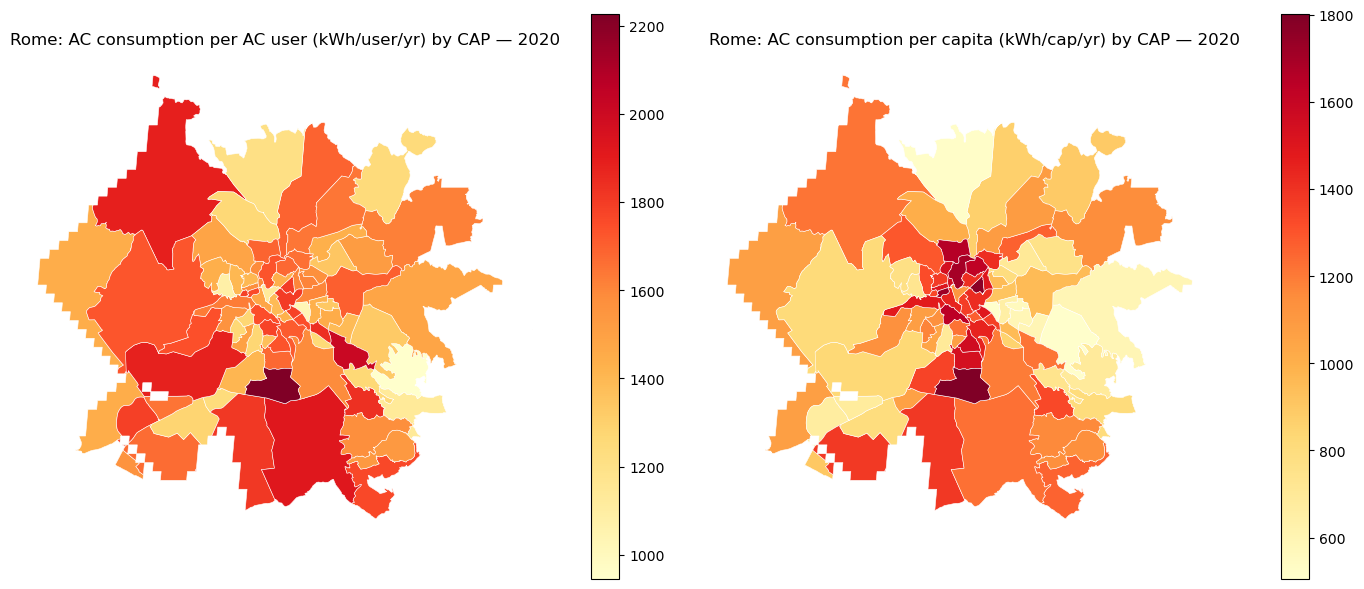


CAP-level results for year 2030
City pop: 2,548,154
City AC users: 1,798,050 (AC share ≈ 0.706)
City total AC electricity: 2831.054 GWh/yr
City per-AC-user mean (users-weighted): 1574.5 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.823,"2,225.175","44,494.561","81,451,139.354","1,830.586",2030
1,78,0.980,"1,805.053","21,992.931","38,904,429.227","1,768.952",2030
2,107,0.980,"1,759.315","9,290.892","16,018,696.160","1,724.129",2030
3,110,0.980,"1,733.222","28,695.673","48,741,264.940","1,698.558",2030
4,71,0.953,"1,745.687","32,908.613","54,765,198.371","1,664.160",2030
5,105,0.980,"1,687.604","24,897.302","41,176,451.062","1,653.852",2030
6,112,0.980,"1,676.421","23,655.270","38,863,070.853","1,642.893",2030
7,66,0.915,"1,732.860","15,601.997","24,742,661.396","1,585.865",2030
8,61,0.933,"1,676.492","36,202.427","56,651,044.997","1,564.841",2030
9,109,0.980,"1,586.604","15,981.707","24,849,499.747","1,554.871",2030


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.498,"1,029.385","27,875.781","14,301,924.230",513.059,2030
1,53,0.394,"1,326.026","103,728.387","54,200,677.892",522.525,2030
2,103,0.439,"1,208.900","11,587.981","6,143,390.083",530.152,2030
3,87,0.427,"1,339.164","20,995.874","11,992,572.114",571.187,2030
4,88,0.411,"1,451.934","35,544.091","21,236,296.802",597.464,2030
5,86,0.433,"1,387.073","34,966.397","21,003,854.309",600.687,2030
6,52,0.407,"1,482.918","8,590.451","5,178,578.803",602.830,2030
7,93,0.460,"1,434.405","27,316.795","18,040,619.245",660.422,2030
8,41,0.381,"1,789.087","17,621.181","12,008,647.463",681.489,2030
9,48,0.420,"1,645.982","37,363.317","25,817,322.604",690.980,2030



Top 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.840,"1,669.586","80,341.232","112,646,125.060","1,402.096",2030
1,83,0.479,"1,730.005","124,767.276","103,425,972.150",828.951,2030
2,55,0.884,"1,489.944","77,077.603","101,470,557.048","1,316.473",2030
3,63,0.976,"1,406.482","72,016.976","98,852,644.831","1,372.630",2030
4,62,0.823,"2,225.175","44,494.561","81,451,139.354","1,830.586",2030
5,59,0.674,"1,643.375","66,337.303","73,481,301.316","1,107.692",2030
6,50,0.778,"1,810.430","49,859.790","70,228,701.161","1,408.524",2030
7,89,0.614,"2,011.540","56,324.068","69,585,430.047","1,235.448",2030
8,82,0.923,"1,628.181","45,832.143","68,878,617.074","1,502.845",2030
9,73,0.569,"1,703.500","70,384.133","68,269,808.474",969.960,2030


Bottom 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.757,"1,787.418",220.221,"297,965.268","1,353.029",2030
1,21,0.725,"1,133.236","1,151.152","946,074.693",821.850,2030
2,24,0.754,"1,446.744","2,401.749","2,621,411.139","1,091.459",2030
3,44,0.588,"1,556.017","3,973.221","3,636,898.493",915.353,2030
4,19,0.743,944.526,"5,608.372","3,937,209.573",702.024,2030
5,52,0.407,"1,482.918","8,590.451","5,178,578.803",602.830,2030
6,103,0.439,"1,208.900","11,587.981","6,143,390.083",530.152,2030
7,3,0.727,"1,247.063","9,452.474","8,566,576.450",906.279,2030
8,33,0.756,"1,532.039","7,703.113","8,920,183.693","1,157.997",2030
9,87,0.427,"1,339.164","20,995.874","11,992,572.114",571.187,2030


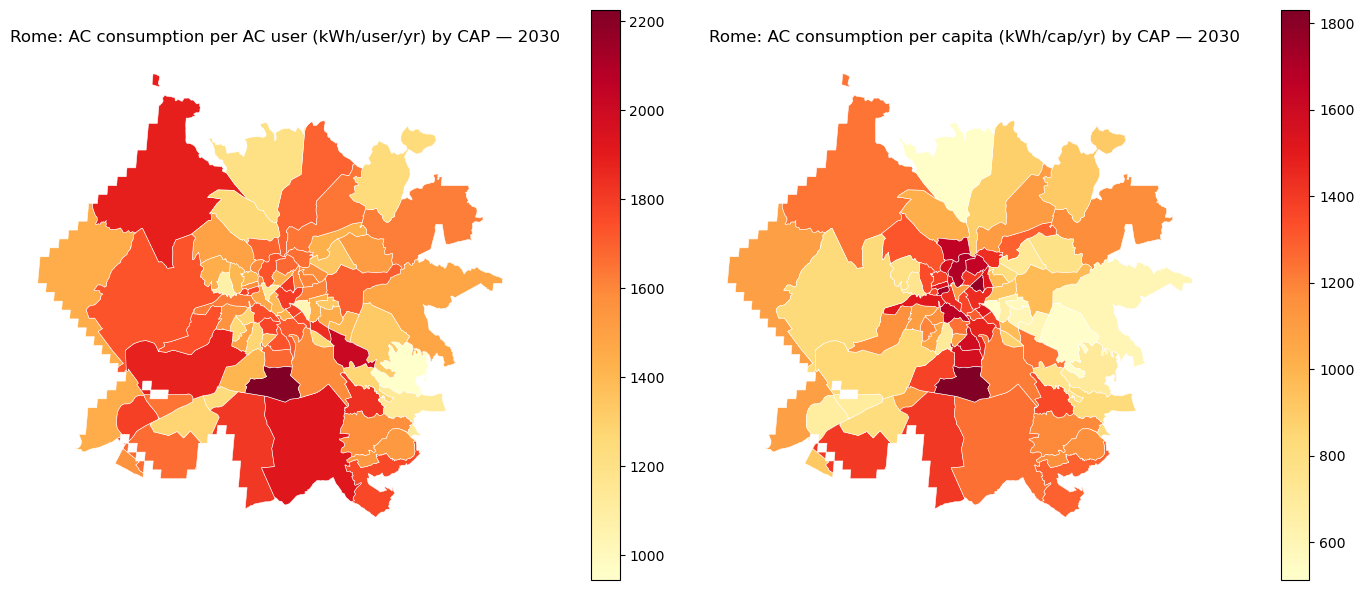


CAP-level results for year 2040
City pop: 2,488,442
City AC users: 1,841,237 (AC share ≈ 0.740)
City total AC electricity: 3060.401 GWh/yr
City per-AC-user mean (users-weighted): 1662.1 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.874,"2,347.612","43,473.624","89,190,406.683","2,051.598",2040
1,78,0.980,"1,904.728","21,488.299","40,110,779.421","1,866.634",2040
2,107,0.980,"1,856.328","9,077.711","16,514,182.605","1,819.201",2040
3,71,0.980,"1,841.965","32,153.518","58,041,131.208","1,805.125",2040
4,110,0.980,"1,828.880","28,037.245","50,251,228.017","1,792.303",2040
5,66,0.973,"1,828.460","15,244.006","27,107,762.284","1,778.257",2040
6,105,0.980,"1,780.830","24,326.028","42,454,106.987","1,745.213",2040
7,112,0.980,"1,769.013","23,112.495","40,068,569.202","1,733.632",2040
8,61,0.980,"1,768.972","35,371.755","61,320,197.710","1,733.592",2040
9,97,0.906,"1,880.474","16,356.687","27,873,633.016","1,704.112",2040


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.528,"1,086.113","27,236.165","15,623,451.737",573.629,2040
1,53,0.417,"1,399.286","101,348.430","59,118,405.981",583.318,2040
2,103,0.464,"1,275.375","11,322.092","6,704,533.853",592.164,2040
3,87,0.451,"1,413.148","20,514.120","13,088,560.604",638.027,2040
4,88,0.435,"1,532.127","34,728.524","23,170,532.523",667.190,2040
5,86,0.458,"1,463.756","34,164.086","22,926,731.084",671.077,2040
6,52,0.430,"1,564.776","8,393.342","5,649,554.502",673.100,2040
7,93,0.488,"1,513.619","26,690.006","19,699,565.278",738.088,2040
8,41,0.403,"1,888.149","17,216.858","13,096,121.892",760.657,2040
9,48,0.444,"1,736.943","36,506.008","28,173,861.765",771.760,2040



Top 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.892,"1,761.945","78,497.786","123,393,478.680","1,571.936",2040
1,83,0.508,"1,825.557","121,904.436","112,967,465.850",926.689,2040
2,55,0.939,"1,572.222","75,309.042","111,161,946.022","1,476.077",2040
3,63,0.980,"1,484.239","70,364.532","102,349,050.824","1,454.555",2040
4,62,0.874,"2,347.612","43,473.624","89,190,406.683","2,051.598",2040
5,59,0.715,"1,734.212","64,813.500","80,413,014.100","1,240.683",2040
6,50,0.826,"1,910.357","48,715.747","76,897,366.596","1,578.491",2040
7,89,0.652,"2,122.401","55,031.703","76,105,527.158","1,382.940",2040
8,82,0.980,"1,718.063","44,780.515","75,397,044.124","1,683.702",2040
9,73,0.604,"1,797.577","68,768.952","74,644,507.999","1,085.439",2040


Bottom 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.804,"1,885.965",215.168,"326,203.530","1,516.042",2040
1,21,0.770,"1,195.880","1,129.132","1,039,735.952",920.827,2040
2,24,0.801,"1,526.543","2,306.358","2,820,606.278","1,222.970",2040
3,44,0.624,"1,641.967","3,882.054","3,977,250.774","1,024.522",2040
4,19,0.789,996.604,"5,480.942","4,311,010.146",786.545,2040
5,52,0.430,"1,564.776","8,393.342","5,649,554.502",673.100,2040
6,103,0.464,"1,275.375","11,322.092","6,704,533.853",592.164,2040
7,3,0.772,"1,315.521","9,087.072","9,223,959.766","1,015.064",2040
8,33,0.803,"1,616.644","7,494.980","9,725,606.324","1,297.616",2040
9,87,0.451,"1,413.148","20,514.120","13,088,560.604",638.027,2040


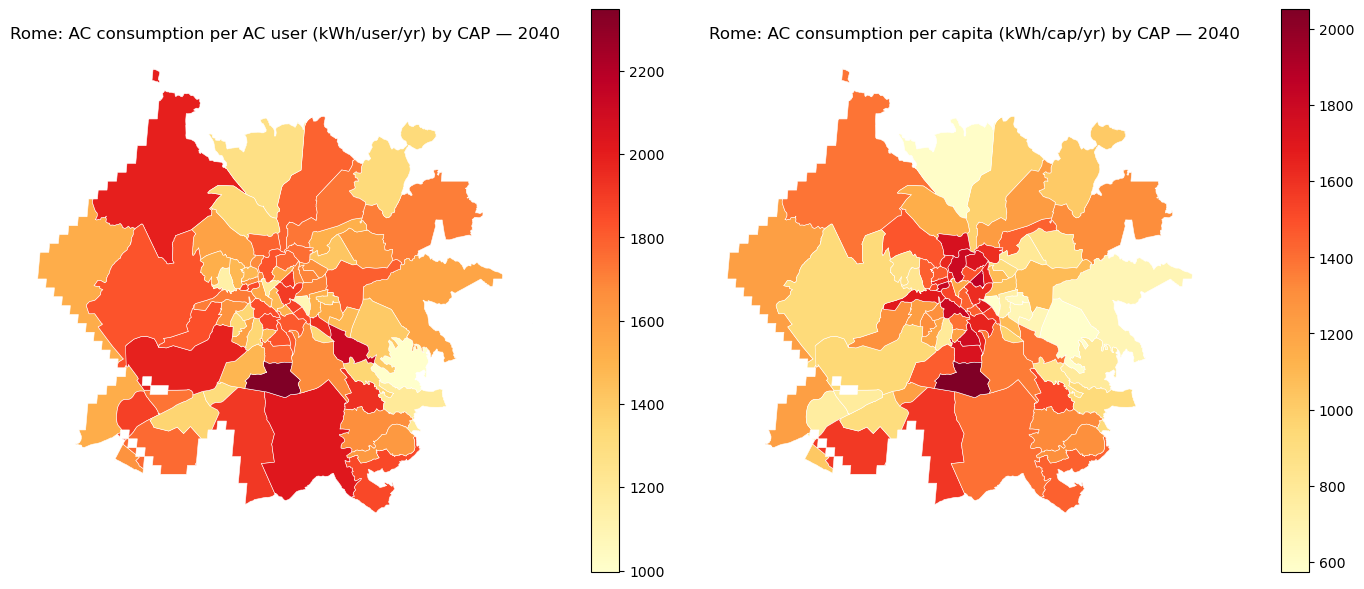


CAP-level results for year 2050
City pop: 2,439,832
City AC users: 1,805,251 (AC share ≈ 0.740)
City total AC electricity: 3139.874 GWh/yr
City per-AC-user mean (users-weighted): 1739.3 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.874,"2,456.857","42,632.525","91,534,945.265","2,147.068",2050
1,78,0.980,"1,993.145","21,072.557","41,160,643.643","1,953.282",2050
2,107,0.980,"1,942.585","8,902.081","16,947,185.258","1,903.733",2050
3,71,0.980,"1,927.545","31,531.433","59,562,699.555","1,888.994",2050
4,110,0.980,"1,913.810","27,494.799","51,567,421.706","1,875.534",2050
5,66,0.973,"1,913.394","14,949.075","27,818,132.395","1,860.860",2050
6,105,0.980,"1,863.475","23,855.384","43,564,841.229","1,826.206",2050
7,61,0.980,"1,851.151","34,687.406","62,927,404.238","1,814.128",2050
8,112,0.980,"1,851.120","22,665.330","41,117,133.065","1,814.098",2050
9,97,0.906,"1,967.776","16,040.228","28,603,357.273","1,783.226",2050


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.528,"1,136.620","26,709.218","16,033,655.541",600.304,2050
1,53,0.417,"1,464.228","99,388.025","60,665,518.648",610.391,2050
2,103,0.464,"1,334.773","11,103.040","6,881,028.772",619.743,2050
3,87,0.451,"1,478.734","20,117.226","13,431,034.310",667.638,2050
4,88,0.435,"1,603.245","34,056.619","23,776,958.094",698.160,2050
5,86,0.458,"1,531.656","33,503.102","23,526,107.438",702.207,2050
6,52,0.430,"1,637.438","8,230.953","5,797,520.159",704.356,2050
7,93,0.488,"1,583.885","26,173.625","20,215,246.730",772.352,2050
8,41,0.403,"1,975.623","16,883.757","13,437,723.576",795.897,2050
9,48,0.444,"1,817.530","35,799.714","28,910,633.266",807.566,2050



Top 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.892,"1,843.633","76,979.062","126,616,254.703","1,644.814",2050
1,83,0.508,"1,910.287","119,545.898","115,923,563.693",969.699,2050
2,55,0.939,"1,645.210","73,852.012","114,071,932.462","1,544.602",2050
3,63,0.980,"1,553.089","69,003.165","105,024,695.317","1,522.027",2050
4,62,0.874,"2,456.857","42,632.525","91,534,945.265","2,147.068",2050
5,59,0.715,"1,814.661","63,558.918","82,514,574.124","1,298.238",2050
6,50,0.826,"1,999.064","47,773.227","78,911,228.996","1,651.788",2050
7,89,0.652,"2,221.055","53,966.994","78,102,196.889","1,447.222",2050
8,82,0.980,"1,797.835","43,914.131","77,371,370.615","1,761.879",2050
9,73,0.604,"1,881.017","67,438.376","76,598,083.556","1,135.823",2050


Bottom 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.804,"1,973.608",211.005,"334,758.250","1,586.495",2050
1,21,0.770,"1,251.368","1,109.067","1,068,645.383",963.553,2050
2,24,0.801,"1,597.471","2,246.393","2,874,916.514","1,279.792",2050
3,44,0.624,"1,718.176","3,806.947","4,081,325.760","1,072.073",2050
4,19,0.789,"1,042.936","5,379.349","4,427,806.553",823.112,2050
5,52,0.430,"1,637.438","8,230.953","5,797,520.159",704.356,2050
6,103,0.464,"1,334.773","11,103.040","6,881,028.772",619.743,2050
7,3,0.772,"1,376.854","8,858.283","9,410,945.622","1,062.389",2050
8,33,0.803,"1,691.691","7,336.739","9,962,216.559","1,357.854",2050
9,87,0.451,"1,478.734","20,117.226","13,431,034.310",667.638,2050


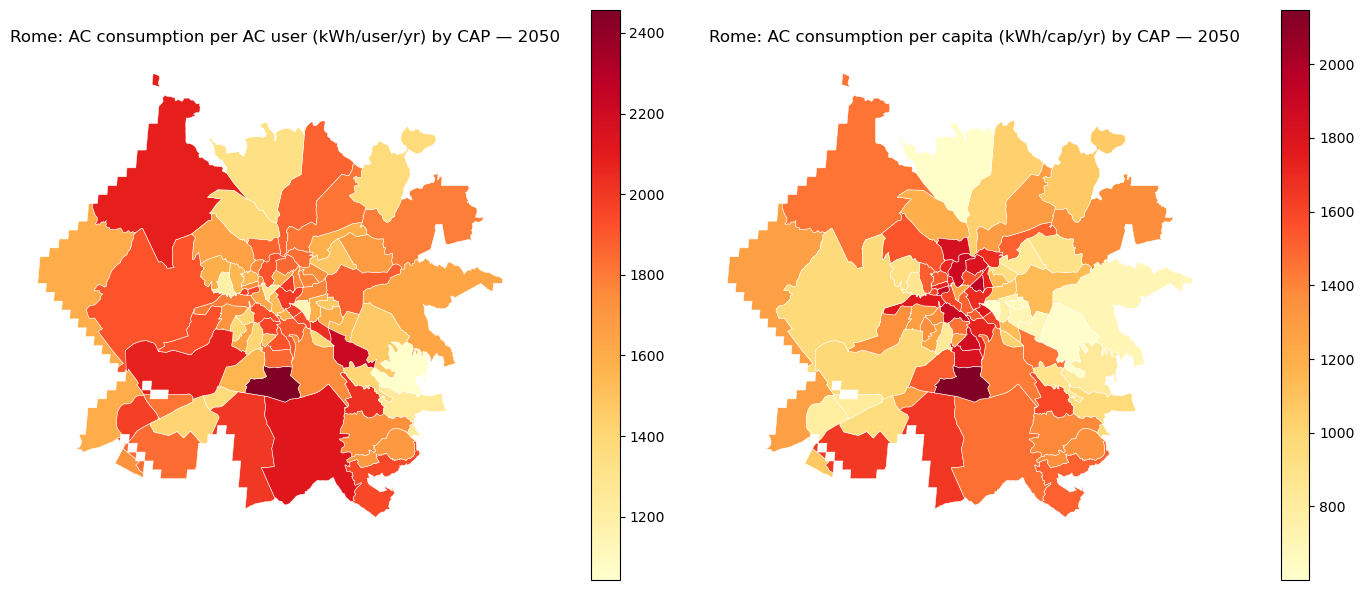


✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_ac_consumption_summary.csv
✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_ac_consumption_map.geojson


In [159]:
import matplotlib.pyplot as plt

years_maps = [2020, 2030, 2040, 2050]

def show_rank_cap(df, col, k=10, title=""):
    """Display top and bottom k CAPs by a given column."""
    cols = ["cap_id", "ac_share_cap", "kwh_per_user_cap", "pop_cap", "kwh_cap", "kwh_pc_overall", "year"]
    cols = [c for c in cols if c in df.columns]
    top = df[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} CAPs by {col} — {title}")
    display(top)
    print(f"Bottom {k} CAPs by {col} — {title}")
    display(bot)

all_cap_tbl = []
all_cap_map = []

for year_map in years_maps:
    print(f"\n{'='*60}")
    print(f"CAP-level results for year {year_map}")
    print('='*60)

    # Year-specific data
    pop_grid = POP_GRID.get(year_map, pop_on_ref)
    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]
    cap_per_user = cap_per_user_by_year[year_map]

    # Matched pixel universe
    CAP_PIX = (CITY_MASK & (cap_ids > 0) &
               np.isfinite(pop_grid) &
               np.isfinite(coverage_map) &
               np.isfinite(kwh_tot_map))

    # Users and pop by CAP
    df_cap_base = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "pop": pop_grid[CAP_PIX].ravel().astype(float),
        "users": (coverage_map[CAP_PIX] * pop_grid[CAP_PIX]).ravel().astype(float),
    })
    cap_pop_users = (df_cap_base.groupby("cap_id", as_index=False)
                     .agg(pop_cap=("pop", "sum"), users_cap=("users", "sum")))
    cap_pop_users["ac_share_cap"] = np.where(
        cap_pop_users["pop_cap"] > 0,
        cap_pop_users["users_cap"] / cap_pop_users["pop_cap"],
        np.nan
    )

    # Energy totals by CAP
    df_kwh = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "kwh": kwh_tot_map[CAP_PIX].ravel().astype(float),
    })
    cap_energy = df_kwh.groupby("cap_id", as_index=False).agg(kwh_cap=("kwh", "sum"))

    # Merge and compute per-capita
    cap_tbl = (cap_pop_users
               .merge(cap_energy, on="cap_id", how="left")
               .merge(cap_per_user, on="cap_id", how="left"))
    cap_tbl["kwh_pc_overall"] = np.where(
        cap_tbl["pop_cap"] > 0,
        cap_tbl["kwh_cap"] / cap_tbl["pop_cap"],
        np.nan
    )
    cap_tbl["year"] = year_map
    all_cap_tbl.append(cap_tbl)

    # City diagnostics
    city_pop = float(np.nansum(pop_grid[CAP_PIX]))
    city_users = float(np.nansum((coverage_map * pop_grid)[CAP_PIX]))
    city_kwh_GWh = float(np.nansum(kwh_tot_map[CAP_PIX])) / 1e6
    per_user_mean_city = float(
        np.nansum(cap_tbl["kwh_per_user_cap"] * cap_tbl["users_cap"]) / max(city_users, 1e-12)
    )
    print(f"City pop: {city_pop:,.0f}")
    print(f"City AC users: {city_users:,.0f} (AC share ≈ {city_users/city_pop:.3f})")
    print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
    print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.1f} kWh/user/yr")

    # Top/bottom tables
    show_rank_cap(cap_tbl, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank_cap(cap_tbl, "kwh_cap", k=10, title=f"Total kWh, {year_map}")

    # Join to CAP polygons for mapping
    cap_map = cap_4326.merge(cap_tbl, on="cap_id", how="left")
    cap_map["year"] = year_map
    cap_map_4326 = cap_map.to_crs("EPSG:4326")
    all_cap_map.append(cap_map_4326)

    # Maps
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    cap_map_4326.plot(ax=ax, column="kwh_per_user_cap", legend=True,
                      linewidth=0.4, edgecolor="white", cmap="YlOrRd")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) by CAP — {year_map}")
    ax.set_axis_off()

    ax = axes[1]
    cap_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True,
                      linewidth=0.4, edgecolor="white", cmap="YlOrRd")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) by CAP — {year_map}")
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_cap_ac_consumption_{year_map}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Save all years together
cap_tbl_all = pd.concat(all_cap_tbl, ignore_index=True)
cap_tbl_all["kwh_GWh"] = cap_tbl_all["kwh_cap"] / 1e6
cap_tbl_csv = OUT / f"{SLUG}_cap_ac_consumption_summary.csv"
cap_tbl_all.to_csv(cap_tbl_csv, index=False)

cap_map_all = gpd.GeoDataFrame(pd.concat(all_cap_map, ignore_index=True), crs="EPSG:4326")
cap_geojson = OUT / f"{SLUG}_cap_ac_consumption_map.geojson"
(cap_map_all[["cap_id", "geometry", "year", "kwh_per_user_cap", "ac_share_cap", "kwh_pc_overall", "kwh_cap"]]
 .to_file(cap_geojson, driver="GeoJSON"))

print(f"\n✓ Saved: {cap_tbl_csv}")
print(f"✓ Saved: {cap_geojson}")

### 6.5 Municipio-Level Analysis and Maps

Aggregate electricity consumption to Municipio level with tables and choropleth maps.

**Why do the "per AC user" and "per capita" maps look different?**
The two maps use different denominators:
- **Per-AC-user**: Average annual AC electricity use only among households that actually have AC
- **Per-capita**: Total AC electricity divided by total population (including non-AC households)


Municipio-level results for year 2020
City diagnostics by universe:
[ALL FUA] per-user=1574.5 AC-share=0.696 total=2885.4 GWh pop=2,634,831 users=1,832,535
[Municipi-only] per-user=1572.0 AC-share=0.694 total=2714.1 GWh pop=2,488,244 users=1,726,488
[Outside Municipi] per-user=1615.3 AC-share=0.723 total=171.3 GWh pop=146,587 users=106,046

Check: in + out = all → users: 1,832,535 vs 1,832,535

From groupby (includes muni_id=0):
  Users-weighted per-user mean: 1,574.5 kWh/user/yr
  City total: 2,885.4 GWh/yr

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2020


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.941,"1,656.251","166,921.552","260,060,853.233","1,557.982",2020
1,1,0.932,"1,523.232","185,540.673","263,473,974.149","1,420.034",2020
2,9,0.826,"1,700.365","226,058.505","317,327,994.621","1,403.743",2020
3,8,0.798,"1,643.281","117,596.549","154,148,040.968","1,310.821",2020
4,15,0.814,"1,468.343","102,559.859","122,610,877.394","1,195.506",2020
5,3,0.715,"1,604.976","153,548.857","176,220,213.108","1,147.649",2020
6,12,0.738,"1,480.506","136,042.403","148,627,297.436","1,092.507",2020
7,7,0.669,"1,631.266","256,906.235","280,453,182.830","1,091.656",2020
8,14,0.697,"1,492.027","163,773.161","170,351,062.616","1,040.165",2020
9,13,0.631,"1,584.853","135,088.538","135,131,939.620","1,000.321",2020


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2020


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.398,"1,357.434","131,684.912","71,109,895.192",540.000,2020
1,5,0.485,"1,488.333","186,055.607","134,276,829.793",721.703,2020
2,4,0.556,"1,526.810","174,912.273","148,417,998.174",848.528,2020
3,11,0.526,"1,655.042","123,717.631","107,797,838.655",871.322,2020
4,10,0.641,"1,533.773","227,837.578","224,045,215.382",983.355,2020
5,13,0.631,"1,584.853","135,088.538","135,131,939.620","1,000.321",2020
6,14,0.697,"1,492.027","163,773.161","170,351,062.616","1,040.165",2020
7,7,0.669,"1,631.266","256,906.235","280,453,182.830","1,091.656",2020
8,12,0.738,"1,480.506","136,042.403","148,627,297.436","1,092.507",2020
9,3,0.715,"1,604.976","153,548.857","176,220,213.108","1,147.649",2020



Top 10 Municipi by kwh_muni — Total kWh, 2020


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.826,"1,700.365","226,058.505","317,327,994.621","1,403.743",2020
1,7,0.669,"1,631.266","256,906.235","280,453,182.830","1,091.656",2020
2,1,0.932,"1,523.232","185,540.673","263,473,974.149","1,420.034",2020
3,2,0.941,"1,656.251","166,921.552","260,060,853.233","1,557.982",2020
4,10,0.641,"1,533.773","227,837.578","224,045,215.382",983.355,2020
5,3,0.715,"1,604.976","153,548.857","176,220,213.108","1,147.649",2020
6,14,0.697,"1,492.027","163,773.161","170,351,062.616","1,040.165",2020
7,8,0.798,"1,643.281","117,596.549","154,148,040.968","1,310.821",2020
8,12,0.738,"1,480.506","136,042.403","148,627,297.436","1,092.507",2020
9,4,0.556,"1,526.810","174,912.273","148,417,998.174",848.528,2020


Bottom 10 Municipi by kwh_muni — Total kWh, 2020


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.398,"1,357.434","131,684.912","71,109,895.192",540.000,2020
1,11,0.526,"1,655.042","123,717.631","107,797,838.655",871.322,2020
2,15,0.814,"1,468.343","102,559.859","122,610,877.394","1,195.506",2020
3,5,0.485,"1,488.333","186,055.607","134,276,829.793",721.703,2020
4,13,0.631,"1,584.853","135,088.538","135,131,939.620","1,000.321",2020
5,4,0.556,"1,526.810","174,912.273","148,417,998.174",848.528,2020
6,12,0.738,"1,480.506","136,042.403","148,627,297.436","1,092.507",2020
7,8,0.798,"1,643.281","117,596.549","154,148,040.968","1,310.821",2020
8,14,0.697,"1,492.027","163,773.161","170,351,062.616","1,040.165",2020
9,3,0.715,"1,604.976","153,548.857","176,220,213.108","1,147.649",2020


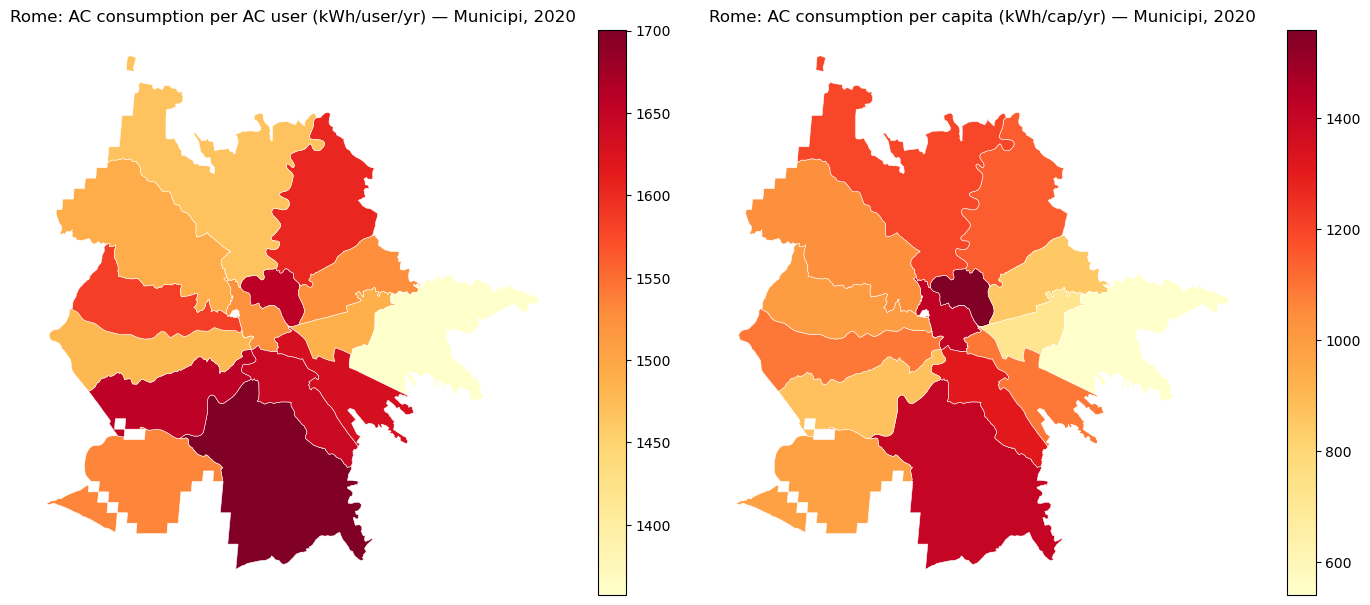


Municipio-level results for year 2030
City diagnostics by universe:
[ALL FUA] per-user=1574.5 AC-share=0.706 total=2831.1 GWh pop=2,548,154 users=1,798,050
[Municipi-only] per-user=1572.0 AC-share=0.704 total=2662.7 GWh pop=2,406,440 users=1,693,798
[Outside Municipi] per-user=1615.1 AC-share=0.736 total=168.4 GWh pop=141,714 users=104,252

Check: in + out = all → users: 1,798,050 vs 1,798,050

From groupby (includes muni_id=0):
  Users-weighted per-user mean: 1,574.5 kWh/user/yr
  City total: 2,831.1 GWh/yr

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.946,"1,656.331","161,260.129","252,766,306.816","1,567.445",2030
1,1,0.939,"1,524.436","179,186.878","256,554,289.148","1,431.769",2030
2,9,0.840,"1,700.175","218,657.720","312,115,559.939","1,427.416",2030
3,8,0.811,"1,643.006","113,650.659","151,456,207.835","1,332.647",2030
4,15,0.824,"1,466.988","99,254.234","119,915,800.152","1,208.168",2030
5,3,0.727,"1,605.003","148,399.737","173,147,345.779","1,166.763",2030
6,12,0.750,"1,480.614","131,663.470","146,252,616.124","1,110.806",2030
7,7,0.680,"1,631.050","248,261.720","275,509,224.137","1,109.753",2030
8,14,0.709,"1,492.173","158,462.193","167,607,213.518","1,057.711",2030
9,13,0.642,"1,584.975","130,701.854","132,900,042.774","1,016.818",2030


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.404,"1,357.408","127,378.690","69,873,672.944",548.551,2030
1,5,0.493,"1,488.233","179,869.615","131,917,316.594",733.405,2030
2,4,0.565,"1,526.712","169,089.088","145,826,023.769",862.421,2030
3,11,0.535,"1,655.224","119,803.339","106,093,313.563",885.562,2030
4,10,0.652,"1,533.775","220,800.463","220,736,553.855",999.711,2030
5,13,0.642,"1,584.975","130,701.854","132,900,042.774","1,016.818",2030
6,14,0.709,"1,492.173","158,462.193","167,607,213.518","1,057.711",2030
7,7,0.680,"1,631.050","248,261.720","275,509,224.137","1,109.753",2030
8,12,0.750,"1,480.614","131,663.470","146,252,616.124","1,110.806",2030
9,3,0.727,"1,605.003","148,399.737","173,147,345.779","1,166.763",2030



Top 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.840,"1,700.175","218,657.720","312,115,559.939","1,427.416",2030
1,7,0.680,"1,631.050","248,261.720","275,509,224.137","1,109.753",2030
2,1,0.939,"1,524.436","179,186.878","256,554,289.148","1,431.769",2030
3,2,0.946,"1,656.331","161,260.129","252,766,306.816","1,567.445",2030
4,10,0.652,"1,533.775","220,800.463","220,736,553.855",999.711,2030
5,3,0.727,"1,605.003","148,399.737","173,147,345.779","1,166.763",2030
6,14,0.709,"1,492.173","158,462.193","167,607,213.518","1,057.711",2030
7,8,0.811,"1,643.006","113,650.659","151,456,207.835","1,332.647",2030
8,12,0.750,"1,480.614","131,663.470","146,252,616.124","1,110.806",2030
9,4,0.565,"1,526.712","169,089.088","145,826,023.769",862.421,2030


Bottom 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.404,"1,357.408","127,378.690","69,873,672.944",548.551,2030
1,11,0.535,"1,655.224","119,803.339","106,093,313.563",885.562,2030
2,15,0.824,"1,466.988","99,254.234","119,915,800.152","1,208.168",2030
3,5,0.493,"1,488.233","179,869.615","131,917,316.594",733.405,2030
4,13,0.642,"1,584.975","130,701.854","132,900,042.774","1,016.818",2030
5,4,0.565,"1,526.712","169,089.088","145,826,023.769",862.421,2030
6,12,0.750,"1,480.614","131,663.470","146,252,616.124","1,110.806",2030
7,8,0.811,"1,643.006","113,650.659","151,456,207.835","1,332.647",2030
8,14,0.709,"1,492.173","158,462.193","167,607,213.518","1,057.711",2030
9,3,0.727,"1,605.003","148,399.737","173,147,345.779","1,166.763",2030


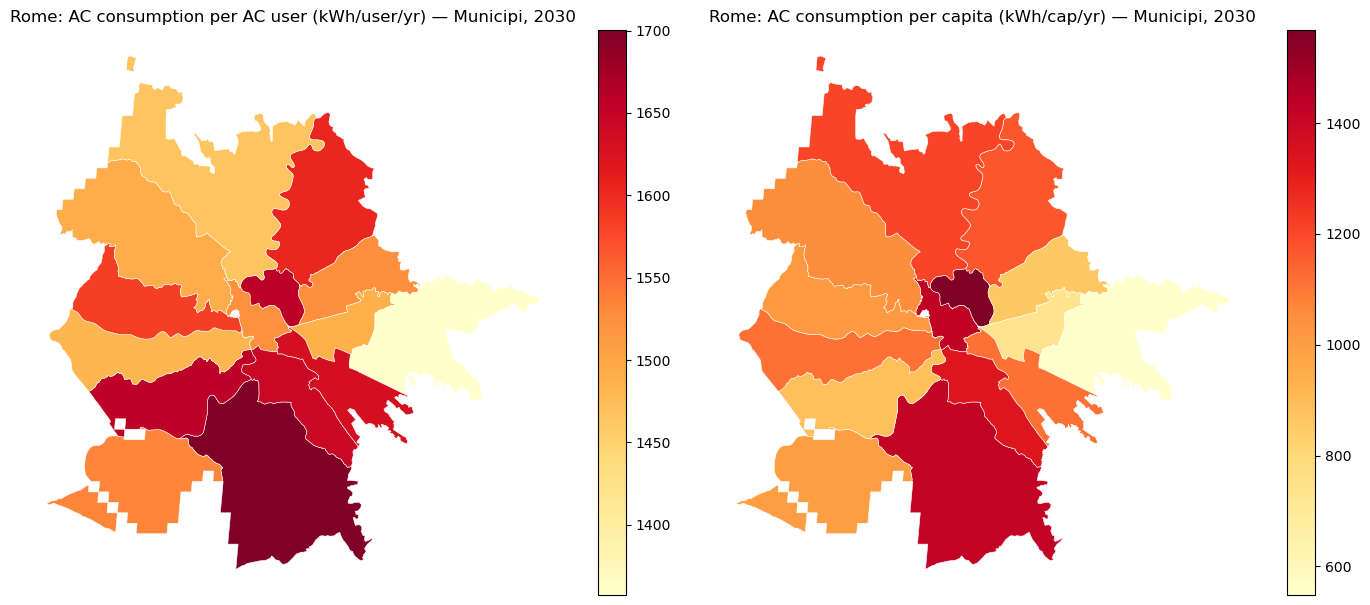


Municipio-level results for year 2040
City diagnostics by universe:
[ALL FUA] per-user=1662.1 AC-share=0.740 total=3060.4 GWh pop=2,488,442 users=1,841,237
[Municipi-only] per-user=1659.5 AC-share=0.738 total=2877.7 GWh pop=2,351,216 users=1,734,047
[Outside Municipi] per-user=1704.6 AC-share=0.781 total=182.7 GWh pop=137,226 users=107,190

Check: in + out = all → users: 1,841,237 vs 1,841,237

From groupby (includes muni_id=0):
  Users-weighted per-user mean: 1,662.1 kWh/user/yr
  City total: 3,060.4 GWh/yr

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.958,"1,748.546","157,559.983","263,799,285.440","1,674.278",2040
1,9,0.873,"1,800.540","213,640.300","335,856,531.680","1,572.065",2040
2,1,0.955,"1,612.197","175,075.398","269,617,163.905","1,540.006",2040
3,8,0.858,"1,733.555","111,042.569","165,114,952.055","1,486.952",2040
4,15,0.859,"1,543.872","96,976.825","128,676,521.757","1,326.879",2040
5,3,0.772,"1,693.616","144,992.634","189,495,564.053","1,306.932",2040
6,7,0.722,"1,721.167","242,563.966","301,461,746.084","1,242.813",2040
7,12,0.791,"1,562.882","128,642.425","159,062,024.120","1,236.466",2040
8,14,0.747,"1,575.278","154,826.246","182,101,663.163","1,176.168",2040
9,13,0.680,"1,672.440","127,702.865","145,307,712.505","1,137.858",2040


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.428,"1,432.437","124,455.966","76,230,269.686",612.508,2040
1,5,0.522,"1,570.515","175,742.470","144,121,053.629",820.070,2040
2,4,0.599,"1,610.997","165,206.499","159,410,747.795",964.918,2040
3,11,0.567,"1,746.513","117,053.903","115,904,097.132",990.177,2040
4,10,0.692,"1,618.522","215,734.151","241,522,662.922","1,119.538",2040
5,13,0.680,"1,672.440","127,702.865","145,307,712.505","1,137.858",2040
6,14,0.747,"1,575.278","154,826.246","182,101,663.163","1,176.168",2040
7,12,0.791,"1,562.882","128,642.425","159,062,024.120","1,236.466",2040
8,7,0.722,"1,721.167","242,563.966","301,461,746.084","1,242.813",2040
9,3,0.772,"1,693.616","144,992.634","189,495,564.053","1,306.932",2040



Top 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.873,"1,800.540","213,640.300","335,856,531.680","1,572.065",2040
1,7,0.722,"1,721.167","242,563.966","301,461,746.084","1,242.813",2040
2,1,0.955,"1,612.197","175,075.398","269,617,163.905","1,540.006",2040
3,2,0.958,"1,748.546","157,559.983","263,799,285.440","1,674.278",2040
4,10,0.692,"1,618.522","215,734.151","241,522,662.922","1,119.538",2040
5,3,0.772,"1,693.616","144,992.634","189,495,564.053","1,306.932",2040
6,14,0.747,"1,575.278","154,826.246","182,101,663.163","1,176.168",2040
7,8,0.858,"1,733.555","111,042.569","165,114,952.055","1,486.952",2040
8,4,0.599,"1,610.997","165,206.499","159,410,747.795",964.918,2040
9,12,0.791,"1,562.882","128,642.425","159,062,024.120","1,236.466",2040


Bottom 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.428,"1,432.437","124,455.966","76,230,269.686",612.508,2040
1,11,0.567,"1,746.513","117,053.903","115,904,097.132",990.177,2040
2,15,0.859,"1,543.872","96,976.825","128,676,521.757","1,326.879",2040
3,5,0.522,"1,570.515","175,742.470","144,121,053.629",820.070,2040
4,13,0.680,"1,672.440","127,702.865","145,307,712.505","1,137.858",2040
5,12,0.791,"1,562.882","128,642.425","159,062,024.120","1,236.466",2040
6,4,0.599,"1,610.997","165,206.499","159,410,747.795",964.918,2040
7,8,0.858,"1,733.555","111,042.569","165,114,952.055","1,486.952",2040
8,14,0.747,"1,575.278","154,826.246","182,101,663.163","1,176.168",2040
9,3,0.772,"1,693.616","144,992.634","189,495,564.053","1,306.932",2040


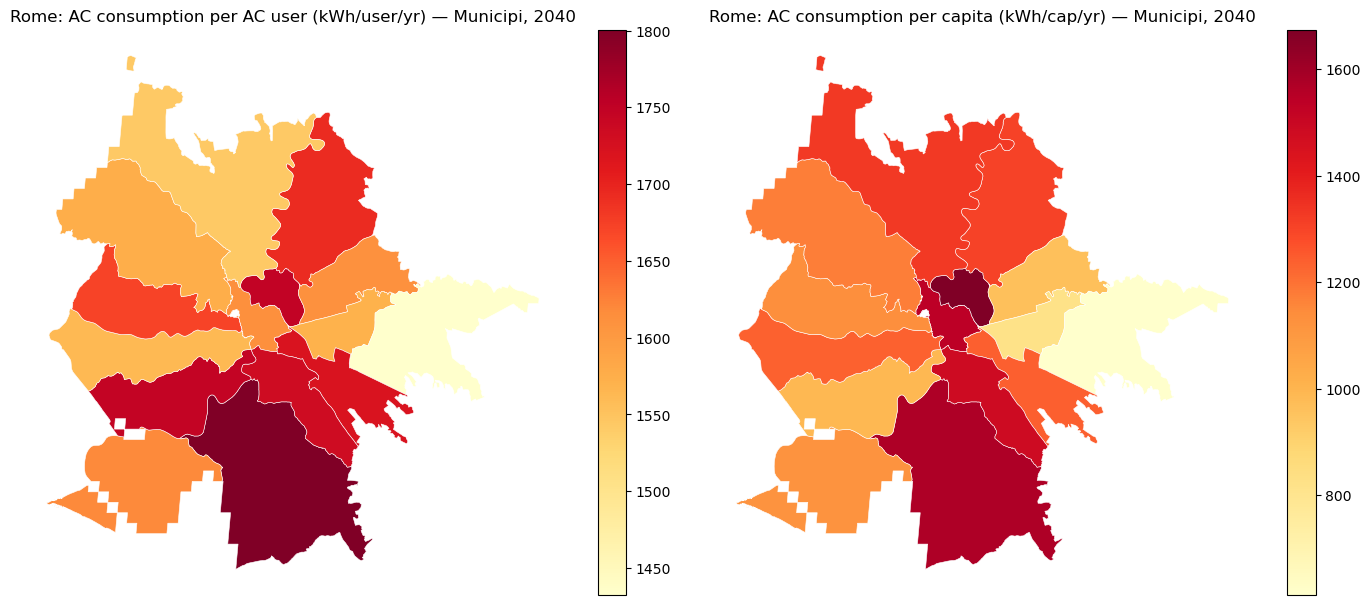


Municipio-level results for year 2050
City diagnostics by universe:
[ALL FUA] per-user=1739.3 AC-share=0.740 total=3139.9 GWh pop=2,439,832 users=1,805,251
[Municipi-only] per-user=1736.6 AC-share=0.738 total=2953.0 GWh pop=2,305,724 users=1,700,496
[Outside Municipi] per-user=1783.8 AC-share=0.781 total=186.9 GWh pop=134,109 users=104,756

Check: in + out = all → users: 1,805,251 vs 1,805,251

From groupby (includes muni_id=0):
  Users-weighted per-user mean: 1,739.3 kWh/user/yr
  City total: 3,139.9 GWh/yr

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.958,"1,829.717","154,511.615","270,704,613.104","1,752.002",2050
1,9,0.873,"1,884.174","209,506.828","344,657,039.238","1,645.087",2050
2,1,0.955,"1,687.032","171,688.154","276,673,730.930","1,611.490",2050
3,8,0.858,"1,814.064","108,894.064","169,440,110.530","1,556.009",2050
4,15,0.859,"1,615.572","95,100.581","132,047,301.739","1,388.502",2050
5,3,0.772,"1,772.206","142,186.661","194,451,471.626","1,367.579",2050
6,7,0.722,"1,801.079","237,870.554","309,354,326.669","1,300.515",2050
7,12,0.791,"1,635.386","126,153.536","163,220,911.040","1,293.827",2050
8,14,0.747,"1,648.394","151,830.769","186,867,186.658","1,230.760",2050
9,13,0.680,"1,750.068","125,232.151","149,110,535.795","1,190.673",2050


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.428,"1,498.915","122,048.099","78,224,796.605",640.934,2050
1,5,0.522,"1,643.433","172,342.319","147,894,709.307",858.145,2050
2,4,0.599,"1,685.795","162,009.110","163,583,744.336","1,009.719",2050
3,11,0.567,"1,827.553","114,789.021","118,935,464.011","1,036.122",2050
4,10,0.692,"1,693.633","211,560.268","247,841,241.046","1,171.492",2050
5,13,0.680,"1,750.068","125,232.151","149,110,535.795","1,190.673",2050
6,14,0.747,"1,648.394","151,830.769","186,867,186.658","1,230.760",2050
7,12,0.791,"1,635.386","126,153.536","163,220,911.040","1,293.827",2050
8,7,0.722,"1,801.079","237,870.554","309,354,326.669","1,300.515",2050
9,3,0.772,"1,772.206","142,186.661","194,451,471.626","1,367.579",2050



Top 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.873,"1,884.174","209,506.828","344,657,039.238","1,645.087",2050
1,7,0.722,"1,801.079","237,870.554","309,354,326.669","1,300.515",2050
2,1,0.955,"1,687.032","171,688.154","276,673,730.930","1,611.490",2050
3,2,0.958,"1,829.717","154,511.615","270,704,613.104","1,752.002",2050
4,10,0.692,"1,693.633","211,560.268","247,841,241.046","1,171.492",2050
5,3,0.772,"1,772.206","142,186.661","194,451,471.626","1,367.579",2050
6,14,0.747,"1,648.394","151,830.769","186,867,186.658","1,230.760",2050
7,8,0.858,"1,814.064","108,894.064","169,440,110.530","1,556.009",2050
8,4,0.599,"1,685.795","162,009.110","163,583,744.336","1,009.719",2050
9,12,0.791,"1,635.386","126,153.536","163,220,911.040","1,293.827",2050


Bottom 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.428,"1,498.915","122,048.099","78,224,796.605",640.934,2050
1,11,0.567,"1,827.553","114,789.021","118,935,464.011","1,036.122",2050
2,15,0.859,"1,615.572","95,100.581","132,047,301.739","1,388.502",2050
3,5,0.522,"1,643.433","172,342.319","147,894,709.307",858.145,2050
4,13,0.680,"1,750.068","125,232.151","149,110,535.795","1,190.673",2050
5,12,0.791,"1,635.386","126,153.536","163,220,911.040","1,293.827",2050
6,4,0.599,"1,685.795","162,009.110","163,583,744.336","1,009.719",2050
7,8,0.858,"1,814.064","108,894.064","169,440,110.530","1,556.009",2050
8,14,0.747,"1,648.394","151,830.769","186,867,186.658","1,230.760",2050
9,3,0.772,"1,772.206","142,186.661","194,451,471.626","1,367.579",2050


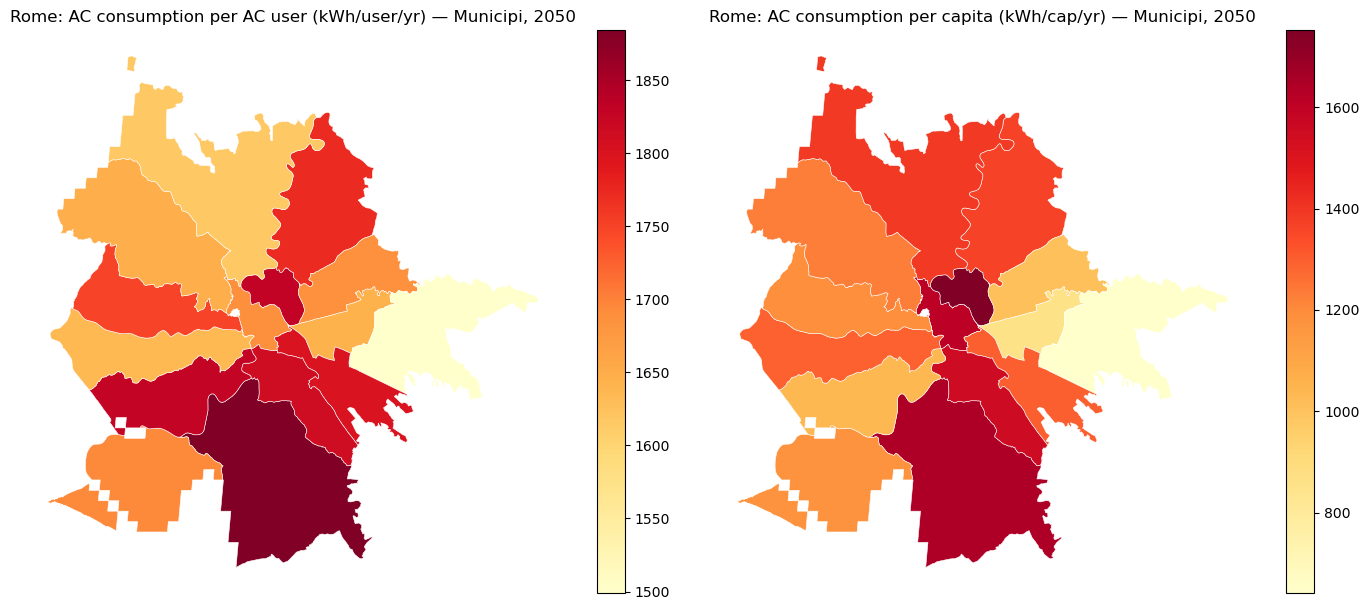


✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_ac_consumption_summary.csv
✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_ac_consumption_map.geojson


In [160]:
years_maps = [2020, 2030, 2040, 2050]

assert 'muni_on_ref' in globals(), "muni_on_ref raster missing."
assert 'muni' in globals() and isinstance(muni, gpd.GeoDataFrame), "muni GeoDataFrame missing."

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

def show_rank_muni(df_in, col, k=10, title=""):
    """Display top and bottom k Municipi by a given column."""
    cols = ["muni_id", "ac_share_muni", "kwh_per_user_muni", "pop_muni", "kwh_muni", "kwh_pc_overall", "year"]
    cols = [c for c in cols if c in df_in.columns]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} Municipi by {col} — {title}")
    display(top)
    print(f"Bottom {k} Municipi by {col} — {title}")
    display(bot)

all_muni_tbl = []
all_muni_map = []

for year_map in years_maps:
    print(f"\n{'='*60}")
    print(f"Municipio-level results for year {year_map}")
    print('='*60)

    # Year-specific data
    pop_grid = POP_GRID.get(year_map, pop_on_ref)
    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]

    # City diagnostics by universe
    def city_diag(mask, label):
        users = float(np.nansum((coverage_map * pop_grid)[mask]))
        per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
        kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
        pop = float(np.nansum(pop_grid[mask]))
        print(f"[{label}] per-user={per_user:.1f} AC-share={users/pop:.3f} "
              f"total={kwh:.1f} GWh pop={pop:,.0f} users={users:,.0f}")
        return per_user, users, kwh

    mask_all = CITY_MASK
    mask_in = CITY_MASK & (muni_on_ref > 0)
    mask_out = CITY_MASK & (muni_on_ref == 0)

    print("City diagnostics by universe:")
    pu_all, u_all, k_all = city_diag(mask_all, "ALL FUA")
    pu_in, u_in, k_in = city_diag(mask_in, "Municipi-only")
    pu_out, u_out, k_out = city_diag(mask_out, "Outside Municipi")

    print(f"\nCheck: in + out = all → users: {u_in + u_out:,.0f} vs {u_all:,.0f}")

    # Build pixel-to-Municipio table
    valid_all = (CITY_MASK &
                 np.isfinite(per_user_map) &
                 np.isfinite(kwh_tot_map) &
                 np.isfinite(pop_grid) &
                 np.isfinite(coverage_map))

    df = pd.DataFrame({
        "muni_id": muni_on_ref[valid_all].ravel().astype(int),
        "pop": pop_grid[valid_all].ravel().astype(float),
        "users": (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
        "kwh": kwh_tot_map[valid_all].ravel().astype(float),
        "per_user": per_user_map[valid_all].ravel().astype(float),
    })

    # Users-weighted per-user by municipio
    per_user_by_muni = (df.groupby("muni_id")
                        .apply(lambda g: _wavg(g["per_user"], g["users"]))
                        .reset_index(name="kwh_per_user_muni"))

    # Totals by municipio
    muni_tbl = (df.groupby("muni_id", as_index=False)
                .agg(pop_muni=("pop", "sum"), users_muni=("users", "sum"), kwh_muni=("kwh", "sum"))
                .merge(per_user_by_muni, on="muni_id", how="left"))

    # Rates
    muni_tbl["ac_share_muni"] = np.where(
        muni_tbl["pop_muni"] > 0,
        muni_tbl["users_muni"] / muni_tbl["pop_muni"],
        np.nan
    )
    muni_tbl["kwh_pc_overall"] = np.where(
        muni_tbl["pop_muni"] > 0,
        muni_tbl["kwh_muni"] / muni_tbl["pop_muni"],
        np.nan
    )
    muni_tbl["year"] = year_map
    all_muni_tbl.append(muni_tbl)

    # City diagnostics from grouped table
    users_sum = float(muni_tbl["users_muni"].sum())
    per_user_from_groups = float(
        np.nansum(muni_tbl["kwh_per_user_muni"] * muni_tbl["users_muni"]) / max(users_sum, 1e-12)
    )
    kwh_sum = float(muni_tbl["kwh_muni"].sum()) / 1e6
    print(f"\nFrom groupby (includes muni_id=0):")
    print(f"  Users-weighted per-user mean: {per_user_from_groups:,.1f} kWh/user/yr")
    print(f"  City total: {kwh_sum:,.1f} GWh/yr")

    # Tables for Municipi only (exclude id==0)
    muni_only = muni_tbl[muni_tbl["muni_id"] > 0].copy()
    show_rank_muni(muni_only, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank_muni(muni_only, "kwh_muni", k=10, title=f"Total kWh, {year_map}")

    # Map join
    muni_cols = ["muni_id", "muni_name", "geometry"] if "muni_name" in muni.columns else ["muni_id", "geometry"]
    muni_map = muni[muni_cols].merge(muni_only, on="muni_id", how="left")
    muni_map["year"] = year_map
    muni_map_4326 = muni_map.to_crs("EPSG:4326")
    all_muni_map.append(muni_map_4326)

    # Maps
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    muni_map_4326.plot(ax=ax, column="kwh_per_user_muni", legend=True,
                       linewidth=0.4, edgecolor="white", cmap="YlOrRd")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) — Municipi, {year_map}")
    ax.set_axis_off()

    ax = axes[1]
    muni_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True,
                       linewidth=0.4, edgecolor="white", cmap="YlOrRd")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) — Municipi, {year_map}")
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_muni_ac_consumption_{year_map}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Save all years together
muni_tbl_all_years = pd.concat(all_muni_tbl, ignore_index=True)
muni_csv = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
(muni_tbl_all_years
 .assign(kwh_GWh=lambda d: d["kwh_muni"] / 1e6)
 .to_csv(muni_csv, index=False))

muni_map_all = gpd.GeoDataFrame(pd.concat(all_muni_map, ignore_index=True), crs="EPSG:4326")
muni_geo = OUT / f"{SLUG}_muni_ac_consumption_map.geojson"
(muni_map_all[["muni_id", "geometry", "year", "kwh_per_user_muni", "ac_share_muni", "kwh_pc_overall", "kwh_muni"]]
 .to_file(muni_geo, driver="GeoJSON"))

print(f"\n✓ Saved: {muni_csv}")
print(f"✓ Saved: {muni_geo}")

### 6.6 Cost Inputs Summary (for NB8 CBA)

This section verifies and summarizes the data exports needed for the CBA notebook:
- Municipio-level coverage trajectories (baseline vs policy)
- Municipio-level electricity consumption
- AC cost parameters

**Note**: The full Present Value calculation is performed in NB8 (CBA) which has access
to both baseline and policy scenarios, and computes waste heat feedback effects.

In [161]:
print("="*60)
print("COST INPUTS FOR NB8 CBA")
print("="*60)

# 1. AC Cost Parameters (will be used in NB8)
print("\n1. AC Cost Parameters:")
print(f"   CAPEX per user:     €{AC_CAPEX_PER_USER:,.0f}")
print(f"   Maintenance rate:   {AC_MAINT_RATE:.0%} of CAPEX/year")
print(f"   Lifetime:           {AC_LIFETIME_YEARS} years")
print(f"   Electricity tariff: €{TARIFF_EUR_PER_KWH:.2f}/kWh")

# 2. Verify Municipio coverage exports exist
muni_cov_path = OUT / f"{SLUG}_muni_cov_yearly.csv"
if muni_cov_path.exists():
    muni_cov_check = pd.read_csv(muni_cov_path)
    print(f"\n2. Municipio Coverage Trajectories:")
    print(f"   Found: {muni_cov_path.name}")
    print(f"   Years: {sorted(muni_cov_check['year'].unique())}")
    print(f"   Columns: {list(muni_cov_check.columns)}")
else:
    print(f"\n2. Municipio Coverage Trajectories:")
    print(f"   Missing: {muni_cov_path.name}")
    print(f"   Will be created from muni_cov DataFrame")

# 3. Verify electricity consumption exports exist
muni_elec_path = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
if muni_elec_path.exists():
    muni_elec_check = pd.read_csv(muni_elec_path)
    print(f"\n3. Municipio Electricity Consumption:")
    print(f"   Found: {muni_elec_path.name}")
    print(f"   Years: {sorted(muni_elec_check['year'].unique())}")
    print(f"   Avg kWh/user (2050): {muni_elec_check[muni_elec_check['year']==2050]['kwh_per_user_muni'].mean():,.0f}")
else:
    print(f"\n3. Municipio Electricity Consumption:")
    print(f"   Missing: {muni_elec_path.name}")

# 4. Summary of coverage trajectories (population-weighted)
print(f"\n4. Coverage Summary (citywide, population-weighted):")
for k, year in enumerate(YEARS_AC):
    m = CITY_MASK & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    pop_m = pop_on_ref[m]
    
    cov_base_m = coverage_base_3d[k][m]
    cov_base = float(np.sum(cov_base_m * pop_m) / np.sum(pop_m))
    
    if coverage_policy_3d is not None:
        cov_pol_m = coverage_policy_3d[k][m]
        cov_pol = float(np.sum(cov_pol_m * pop_m) / np.sum(pop_m))
        print(f"   {year}: Baseline {cov_base:.1%} → Policy {cov_pol:.1%} (Δ = {cov_pol-cov_base:.1%})")
    else:
        print(f"   {year}: Baseline {cov_base:.1%}")

# 5. Save cost parameters to JSON for NB8
ac_cost_params = {
    "capex_per_user": AC_CAPEX_PER_USER,
    "maint_rate": AC_MAINT_RATE,
    "lifetime_years": AC_LIFETIME_YEARS,
    "tariff_eur_per_kwh": TARIFF_EUR_PER_KWH,
    "maint_per_user_yr": maint_per_user_yr,
}

import json
with open(INT / f"ac_cost_params_{SLUG}.json", "w") as f:
    json.dump(ac_cost_params, f, indent=2)
print(f"\n5. Saved: ac_cost_params_{SLUG}.json")

print("\n" + "="*60)
print("Ready for NB8 CBA calculation")
print("="*60)
print("""
NB8 will compute:
- Time-varying users (baseline vs policy) per Municipio
- Cohort-based CAPEX with replacement cycles
- Incremental electricity costs per year
- Waste heat feedback on temperature
- Full PV of all cost streams
""")

COST INPUTS FOR NB8 CBA

1. AC Cost Parameters:
   CAPEX per user:     €500
   Maintenance rate:   5% of CAPEX/year
   Lifetime:           10 years
   Electricity tariff: €0.25/kWh

2. Municipio Coverage Trajectories:
   Found: rome_muni_cov_yearly.csv
   Years: [2020, 2030, 2040, 2050]
   Columns: ['year', 'muni_id', 'muni_name', 'pop_muni', 'ac_base_muni', 'ac_policy_muni']

3. Municipio Electricity Consumption:
   Found: rome_muni_ac_consumption_summary.csv
   Years: [2020, 2030, 2040, 2050]
   Avg kWh/user (2050): 1,723

4. Coverage Summary (citywide, population-weighted):
   2020: Baseline 69.5% → Policy 78.2% (Δ = 8.6%)
   2030: Baseline 70.6% → Policy 78.8% (Δ = 8.2%)
   2040: Baseline 74.0% → Policy 80.8% (Δ = 6.8%)
   2050: Baseline 74.0% → Policy 80.8% (Δ = 6.8%)

5. Saved: ac_cost_params_rome.json

Ready for NB8 CBA calculation

NB8 will compute:
- Time-varying users (baseline vs policy) per Municipio
- Cohort-based CAPEX with replacement cycles
- Incremental electricity cos

## 7. AC FEEDBACK ON TEMPERATURE (waste heat mechanism)

This section computes:
- Marginal heat deaths per +1°C (for different AC scenarios)
- Waste heat warming as a function of AC penetration
- Data exports for NB8 CBA feedback calculation

The actual feedback penalty on mortality is computed in NB8 (CBA).

## 7. AC FEEDBACK ON TEMPERATURE (Waste Heat Mechanism)

AC has two opposing effects on heat mortality:
1. **Protection** (-): AC reduces indoor temperatures, lowering heat-related deaths
2. **Waste heat** (+): AC exhaust warms outdoor air, increasing ambient temperatures

This section quantifies both effects to enable net benefit calculation in CBA.

### Key outputs:
- Marginal deaths per +1°C under different AC scenarios
- Waste heat ΔT as function of AC penetration (from Salamanca et al. 2014)

### 7.1 Marginal Heat Deaths per +1°C

Compute how many additional deaths occur if temperatures increase by 1°C,
under three AC coverage scenarios:
- **Generic**: No AC protection (eff=0)
- **Current AC**: Baseline AC coverage
- **Policy AC**: Policy AC coverage

This is done by running mortality calculation twice (original T, T+1°C) and taking the difference.

**7.1a - Helper functions**

In [163]:
print("="*60)
print("SECTION 7: MARGINAL HEAT DEATHS PER +1°C")
print("="*60)

import copy

def hazard_add_deltaT_fast(H, deltaT: float):
    """Copy hazard and add uniform +deltaT (°C) to all intensity entries."""
    H2 = copy.copy(H)
    H2.intensity = H.intensity.copy()
    H2.intensity.data = H2.intensity.data + float(deltaT)
    return H2

def deaths_year_by_age_from_H(H_use, year, coverage_grid, eff_by_bucket, 
                               eff_base=None, age_ifs=None):
    """
    Compute deaths for a given year using a (possibly perturbed) hazard.
    
    NOTE: This function uses GLOBAL age_on_ref and pop_on_ref!
    """
    if age_ifs is None:
        age_ifs = get_age_ifs(year)
    
    dates = pd.to_datetime(H_use.date)
    idx = np.where(dates.year == int(year))[0]
    if idx.size == 0:
        return {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    # Uses GLOBAL pop_on_ref (must be set for correct year!)
    m_city = CITY_MASK & np.isfinite(pop_on_ref) & (pop_on_ref > 0)

    # Fill coverage holes with city pop-weighted mean
    cov = np.array(coverage_grid, dtype=float, copy=True)
    w = pop_on_ref[m_city].astype(float)
    x = np.nan_to_num(cov[m_city], nan=0.0).astype(float)
    mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
    cov = np.where(m_city & np.isfinite(cov), cov, mean_cov)

    out = {age_lbl: 0.0 for age_lbl in age_ifs.keys()}
    
    if eff_base is None:
        eff_base = EFF_DEFAULT

    for i_ev in idx:
        I_grid = _row_to_grid(H_use.intensity, i_ev, ref_data.shape)
        m = m_city & np.isfinite(I_grid)
        if not np.any(m):
            continue

        cov_m = np.where(m, cov, 0.0)

        for age_lbl, f in age_ifs.items():
            eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base)
            mdd = _interp_mdd(I_grid, f)
            mult = np.clip(1.0 - eff_a * cov_m, 0.0, 1.0)
            # Uses GLOBAL age_on_ref (must be set for correct year!)
            pop_a = np.nan_to_num(age_on_ref[age_lbl], 0.0)
            out[age_lbl] += float(np.nansum(pop_a[m] * mdd[m] * mult[m]))

    return out

SECTION 7: MARGINAL HEAT DEATHS PER +1°C


**7.1b - Marginal deaths calculation**

In [164]:
def annual_table_and_marginal_perC(H0, years, coverage_cube_or_none, 
                                    eff_buckets, eff_base, deltaT=1.0, label=""):
    """
    Compute deaths at base temperature and at +deltaT°C, return marginal.
    
    IMPORTANT: Updates global age_on_ref and pop_on_ref for each year!
    """
    global age_on_ref, pop_on_ref  # CRITICAL: Must declare global!
    
    H1 = hazard_add_deltaT_fast(H0, deltaT)
    
    rows = []
    for y in years:
        # Update GLOBAL grids for this year
        age_on_ref = AGE_GRID.get(int(y), age_on_ref_base)
        pop_on_ref = POP_GRID.get(int(y), pop_on_ref_base)
        
        # Get coverage for this year
        if coverage_cube_or_none is None:
            cov = np.zeros(ref_data.shape, dtype=float)
        else:
            cov = coverage_cube_or_none[year_to_index[int(y)]].astype(float)
        
        # Deaths at original temperature
        d0 = deaths_year_by_age_from_H(H0, int(y), cov, eff_buckets, eff_base=eff_base)
        deaths_T = sum(d0.values())
        
        # Deaths at +deltaT°C
        d1 = deaths_year_by_age_from_H(H1, int(y), cov, eff_buckets, eff_base=eff_base)
        deaths_T_plus = sum(d1.values())
        
        # Marginal deaths per °C
        marginal = deaths_T_plus - deaths_T
        
        rows.append({
            "year": int(y),
            "deaths_T": deaths_T,
            "deaths_T_plus_dT": deaths_T_plus,
            "marginal_per_C": marginal / deltaT,
            **{f"{k}": v for k, v in d0.items()},  # Age breakdown at base T
        })
        
        if label:
            print(f"  {label} {y}: {deaths_T:.1f} deaths → {deaths_T_plus:.1f} at +{deltaT}°C "
                  f"(marginal: {marginal/deltaT:.1f}/°C)")
    
    return pd.DataFrame(rows)

**7.1c - Run for all scenarios**

In [165]:
years_marginal = list(YEARS_AC)

# Scenario 1: Generic ("no" AC protection)
print("\n1. Generic (no AC):")
marginal_generic = annual_table_and_marginal_perC(
    H, years_marginal,
    coverage_cube_or_none=None,
    eff_buckets=EFF_BUCKETS,
    eff_base=0.0,
    label="generic"
)

# Scenario 2: Current AC (baseline coverage)
print("\n2. Current AC (baseline):")
marginal_current = annual_table_and_marginal_perC(
    H, years_marginal,
    coverage_cube_or_none=coverage_base_3d,
    eff_buckets=EFF_BUCKETS,
    eff_base=EFF_DEFAULT,
    label="currentAC"
)

# Scenario 3: Policy AC
print("\n3. Policy AC:")
marginal_policy = annual_table_and_marginal_perC(
    H, years_marginal,
    coverage_cube_or_none=coverage_policy_3d,
    eff_buckets=EFF_BUCKETS,
    eff_base=EFF_DEFAULT,
    label="policyAC"
)


1. Generic (no AC):
  generic 2020: 642.4 deaths → 961.6 at +1.0°C (marginal: 319.2/°C)
  generic 2030: 767.0 deaths → 1126.2 at +1.0°C (marginal: 359.2/°C)
  generic 2040: 854.5 deaths → 1245.7 at +1.0°C (marginal: 391.2/°C)
  generic 2050: 846.3 deaths → 1245.6 at +1.0°C (marginal: 399.3/°C)

2. Current AC (baseline):
  currentAC 2020: 467.8 deaths → 699.9 at +1.0°C (marginal: 232.1/°C)
  currentAC 2030: 553.4 deaths → 812.4 at +1.0°C (marginal: 259.0/°C)
  currentAC 2040: 602.6 deaths → 878.5 at +1.0°C (marginal: 275.9/°C)
  currentAC 2050: 595.0 deaths → 876.0 at +1.0°C (marginal: 281.0/°C)

3. Policy AC:
  policyAC 2020: 447.3 deaths → 669.1 at +1.0°C (marginal: 221.7/°C)
  policyAC 2030: 529.9 deaths → 777.7 at +1.0°C (marginal: 247.8/°C)
  policyAC 2040: 580.7 deaths → 846.4 at +1.0°C (marginal: 265.7/°C)
  policyAC 2050: 573.2 deaths → 843.8 at +1.0°C (marginal: 270.5/°C)


In [166]:
marginal_generic.to_csv(INT / f"marginal_heat_deaths_perC_generic_{SLUG}.csv", index=False)
marginal_current.to_csv(INT / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv", index=False)
marginal_policy.to_csv(INT / f"marginal_heat_deaths_perC_policyAC_{SLUG}.csv", index=False)

# Also save baseline annual deaths for reference
baseline_annual = marginal_current[["year", "deaths_T"]].rename(columns={"deaths_T": "deaths_annual"})
baseline_annual.to_csv(INT / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv", index=False)

print(f"\n✓ Saved marginal death tables to {INT}/")


✓ Saved marginal death tables to /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/


In [167]:
print("\n" + "="*60)
print("VERIFICATION: Deaths should match main policy calculation")
print("="*60)

print(f"\n{'Year':<6} {'Generic (here)':<15} {'Generic (main)':<15} {'Match?':<8}")
print("-"*50)
expected_generic = {2020: 642.4, 2030: 767.0, 2040: 854.5, 2050: 846.3}
for _, row in marginal_generic.iterrows():
    y = int(row["year"])
    here = row["deaths_T"]
    main = expected_generic.get(y, 0)
    match = "yes" if abs(here - main) < 1 else "no"
    print(f"{y:<6} {here:<15.1f} {main:<15.1f} {match:<8}")


VERIFICATION: Deaths should match main policy calculation

Year   Generic (here)  Generic (main)  Match?  
--------------------------------------------------
2020   642.4           642.4           yes     
2030   767.0           767.0           yes     
2040   854.5           854.5           yes     
2050   846.3           846.3           yes     


### 7.2 Waste Heat Warming (Salamanca et al. 2014)

### 7.2.1 Salamanca et al. (2014) Lookup Table

In [168]:
# Nighttime warming (°C) as function of AC penetration
# These are for the "central" scenario; low/high also available

AC_WASTEHEAT_LUT = {
    0.00: {"low": 0.00, "central": 0.00, "high": 0.00},
    0.35: {"low": 0.25, "central": 0.375, "high": 0.50},
    0.65: {"low": 0.50, "central": 0.75, "high": 1.00},
    1.00: {"low": 1.00, "central": 1.25, "high": 1.50},
}

USE_AC_FEEDBACK = True  # Toggle ON/OFF
DELTA_T_CASE = "central"  # "low", "central", or "high"
DAILYMEAN_FROM_NIGHT = 0.50  # Daily-mean ≈ 0.5 × nighttime warming

def dT_night_from_penetration(pen, case="central"):
    """
    Interpolate nighttime warming from AC penetration using Salamanca et al. data.
    
    Parameters
    ----------
    pen : float or array
        AC penetration in [0, 1]
    case : str
        "low", "central", or "high"
    
    Returns
    -------
    Nighttime temperature increase (°C)
    """
    pen_points = np.array(sorted(AC_WASTEHEAT_LUT.keys()))
    dT_points = np.array([AC_WASTEHEAT_LUT[p][case] for p in pen_points])
    pen_clipped = np.clip(pen, 0.0, 1.0)
    return np.interp(pen_clipped, pen_points, dT_points)

def dT_dailymean_from_penetration(pen, case="central"):
    """Daily-mean ΔT from AC penetration (half of nighttime warming)."""
    return DAILYMEAN_FROM_NIGHT * dT_night_from_penetration(pen, case)

print(f"Waste heat feedback: {'ON' if USE_AC_FEEDBACK else 'OFF'}")
print(f"Using {DELTA_T_CASE} case from Salamanca et al. (2014)")
print(f"Daily-mean factor: {DAILYMEAN_FROM_NIGHT} × nighttime")

Waste heat feedback: ON
Using central case from Salamanca et al. (2014)
Daily-mean factor: 0.5 × nighttime


### 7.2.2 Build 25-year Penetration Time Series (population-weighted)


In [169]:
print("\n" + "-"*60)
print("Building 25-year penetration time series...")
print("-"*60)

# Load municipio coverage data (saved earlier in Section 3)
muni_cov_path = OUT / f"{SLUG}_muni_cov_yearly.csv"
muni_cov_yearly = pd.read_csv(muni_cov_path)
print(f"✓ Loaded: {muni_cov_path.name}")
print(f"  Columns: {list(muni_cov_yearly.columns)}")
print(f"  Years: {sorted(muni_cov_yearly['year'].unique())}")

# Define time horizon (must match NB8)
T = 25
START_YEAR = int(muni_cov_yearly["year"].min())
YEARS_ALL = np.arange(START_YEAR, START_YEAR + T, dtype=int)

# Compute citywide users and population per year
# users = pop × coverage (penetration)
def compute_users_by_year(df, coverage_col):
    """Compute total AC users per year = sum(pop × coverage)"""
    df = df.copy()
    df["users"] = df["pop_muni"] * df[coverage_col]
    return df.groupby("year")["users"].sum()

def compute_pop_by_year(df):
    """Compute total population per year"""
    return df.groupby("year")["pop_muni"].sum()

# Get anchor year values
users_base_anchor = compute_users_by_year(muni_cov_yearly, "ac_base_muni")
users_policy_anchor = compute_users_by_year(muni_cov_yearly, "ac_policy_muni")
pop_anchor = compute_pop_by_year(muni_cov_yearly)

# Interpolate to full 25-year horizon
def interpolate_to_horizon(series, target_years):
    """Interpolate from anchor years to full horizon with edge clamping."""
    known_years = series.index.to_numpy(dtype=int)
    known_vals = series.to_numpy(dtype=float)
    out = np.interp(target_years, known_years, known_vals)
    out[target_years <= known_years[0]] = known_vals[0]
    out[target_years >= known_years[-1]] = known_vals[-1]
    return out

users_base_t = interpolate_to_horizon(users_base_anchor, YEARS_ALL)
users_policy_t = interpolate_to_horizon(users_policy_anchor, YEARS_ALL)
pop_total_t = interpolate_to_horizon(pop_anchor, YEARS_ALL)

# Compute penetration = users / population
pen_base_t = users_base_t / pop_total_t
pen_pol_t = users_policy_t / pop_total_t

print(f"\nPenetration time series (population-weighted):")
print(f"  Baseline: {pen_base_t[0]:.1%} ({YEARS_ALL[0]}) → {pen_base_t[-1]:.1%} ({YEARS_ALL[-1]})")
print(f"  Policy:   {pen_pol_t[0]:.1%} ({YEARS_ALL[0]}) → {pen_pol_t[-1]:.1%} ({YEARS_ALL[-1]})")

# Show anchor year values for verification
print(f"\nAnchor year penetration:")
for yr in sorted(users_base_anchor.index):
    idx = np.where(YEARS_ALL == yr)[0]
    if len(idx) > 0:
        i = idx[0]
        print(f"  {yr}: baseline={pen_base_t[i]:.1%}, policy={pen_pol_t[i]:.1%}")


------------------------------------------------------------
Building 25-year penetration time series...
------------------------------------------------------------
✓ Loaded: rome_muni_cov_yearly.csv
  Columns: ['year', 'muni_id', 'muni_name', 'pop_muni', 'ac_base_muni', 'ac_policy_muni']
  Years: [2020, 2030, 2040, 2050]

Penetration time series (population-weighted):
  Baseline: 69.6% (2020) → 74.0% (2044)
  Policy:   78.2% (2020) → 80.8% (2044)

Anchor year penetration:
  2020: baseline=69.6%, policy=78.2%
  2030: baseline=70.6%, policy=78.8%
  2040: baseline=74.0%, policy=80.8%


### 7.2.3 Compute Waste Heat ΔT (25-year time series)


In [170]:
print("\n" + "-"*60)
print("Computing waste heat warming...")
print("-"*60)

# Nighttime warming
dT_night_base_t = dT_night_from_penetration(pen_base_t, case=DELTA_T_CASE)
dT_night_pol_t = dT_night_from_penetration(pen_pol_t, case=DELTA_T_CASE)
dT_night_inc_t = dT_night_pol_t - dT_night_base_t

# Daily-mean warming (half of nighttime)
dT_dm_base_t = DAILYMEAN_FROM_NIGHT * dT_night_base_t
dT_dm_pol_t = DAILYMEAN_FROM_NIGHT * dT_night_pol_t
dT_dm_inc_t = DAILYMEAN_FROM_NIGHT * dT_night_inc_t

print(f"\nWaste heat ΔT (daily mean, {DELTA_T_CASE} case):")
print(f"  Baseline: {dT_dm_base_t.min():.3f}°C → {dT_dm_base_t.max():.3f}°C")
print(f"  Policy:   {dT_dm_pol_t.min():.3f}°C → {dT_dm_pol_t.max():.3f}°C")
print(f"  Incremental max: {dT_dm_inc_t.max():.3f}°C")


------------------------------------------------------------
Computing waste heat warming...
------------------------------------------------------------

Waste heat ΔT (daily mean, central case):
  Baseline: 0.408°C → 0.439°C
  Policy:   0.469°C → 0.488°C
  Incremental max: 0.062°C


### 7.2.4 Compute Waste Heat Penalty (extra deaths from warming)

In [171]:
print("\n" + "-"*60)
print("Computing waste heat penalty...")
print("-"*60)

# Load marginal deaths per °C 
# Use current AC marginal (more conservative than policy AC marginal)
M1 = marginal_current.set_index("year")

# Interpolate marginal deaths to full horizon
marginal_total_perC_t = interpolate_to_horizon(M1["marginal_per_C"], YEARS_ALL)

print(f"Marginal deaths per °C (from current AC scenario):")
print(f"  Range: {marginal_total_perC_t.min():.1f} → {marginal_total_perC_t.max():.1f} deaths/°C")

if USE_AC_FEEDBACK:
    # Incremental penalty (policy warming minus baseline warming)
    dT_eff_inc_t = np.maximum(dT_dm_inc_t, 0.0)
    warming_penalty_t = marginal_total_perC_t * dT_eff_inc_t
    
    # Total penalty under each scenario (vs no outdoor AC at all)
    dT_eff_base_t = np.maximum(dT_dm_base_t, 0.0)
    dT_eff_pol_t = np.maximum(dT_dm_pol_t, 0.0)
    penalty_base_t = marginal_total_perC_t * dT_eff_base_t
    penalty_pol_t = marginal_total_perC_t * dT_eff_pol_t
    
    print(f"\nWaste heat penalty (extra deaths):")
    print(f"  Final year ({YEARS_ALL[-1]}):")
    print(f"    Under baseline AC: {penalty_base_t[-1]:.1f} deaths/year")
    print(f"    Under policy AC:   {penalty_pol_t[-1]:.1f} deaths/year")
    print(f"    Incremental:       {warming_penalty_t[-1]:.1f} deaths/year")
    print(f"\n  25-year cumulative:")
    print(f"    Under baseline AC: {penalty_base_t.sum():.1f} deaths")
    print(f"    Under policy AC:   {penalty_pol_t.sum():.1f} deaths")
    print(f"    Incremental:       {warming_penalty_t.sum():.1f} deaths")
else:
    warming_penalty_t = np.zeros(T)
    penalty_base_t = np.zeros(T)
    penalty_pol_t = np.zeros(T)
    print("\n⚠ Waste heat feedback is OFF - penalty set to zero")


------------------------------------------------------------
Computing waste heat penalty...
------------------------------------------------------------
Marginal deaths per °C (from current AC scenario):
  Range: 232.1 → 278.0 deaths/°C

Waste heat penalty (extra deaths):
  Final year (2044):
    Under baseline AC: 122.1 deaths/year
    Under policy AC:   135.5 deaths/year
    Incremental:       13.4 deaths/year

  25-year cumulative:
    Under baseline AC: 2746.8 deaths
    Under policy AC:   3104.9 deaths
    Incremental:       358.2 deaths


### 7.2.5 Save All Outputs for NB8

In [172]:
print("\n" + "-"*60)
print("Saving outputs for NB8...")
print("-"*60)

# Save waste heat time series (full 25-year data)
wasteheat_df = pd.DataFrame({
    "year": YEARS_ALL,
    "pen_base": pen_base_t,
    "pen_policy": pen_pol_t,
    "dT_night_base": dT_night_base_t,
    "dT_night_policy": dT_night_pol_t,
    "dT_night_incremental": dT_night_inc_t,
    "dT_dm_base": dT_dm_base_t,
    "dT_dm_policy": dT_dm_pol_t,
    "dT_dm_incremental": dT_dm_inc_t,
    "marginal_perC": marginal_total_perC_t,
    "penalty_base": penalty_base_t,
    "penalty_policy": penalty_pol_t,
    "penalty_incremental": warming_penalty_t,
})

wasteheat_csv = INT / f"ac_wasteheat_timeseries_{SLUG}.csv"
wasteheat_df.to_csv(wasteheat_csv, index=False)
print(f" Saved: {wasteheat_csv.name}")

# Save waste heat parameters (for quick reference)
wasteheat_params = {
    "case": DELTA_T_CASE,
    "dailymean_from_night": DAILYMEAN_FROM_NIGHT,
    "use_feedback": USE_AC_FEEDBACK,
    "lut": {str(k): v for k, v in AC_WASTEHEAT_LUT.items()},
    "T": T,
    "start_year": int(START_YEAR),
    # Summary stats
    "pen_base_final": float(pen_base_t[-1]),
    "pen_policy_final": float(pen_pol_t[-1]),
    "dT_dm_base_max": float(dT_dm_base_t.max()),
    "dT_dm_policy_max": float(dT_dm_pol_t.max()),
    "dT_dm_incremental_max": float(dT_dm_inc_t.max()),
    "penalty_incremental_cumulative": float(warming_penalty_t.sum()),
}

wasteheat_json = INT / f"wasteheat_params_{SLUG}.json"
with open(wasteheat_json, "w") as f:
    json.dump(wasteheat_params, f, indent=2)
print(f" Saved: {wasteheat_json.name}")


------------------------------------------------------------
Saving outputs for NB8...
------------------------------------------------------------
 Saved: ac_wasteheat_timeseries_rome.csv
 Saved: wasteheat_params_rome.json


# 7.3 Feedback Summary for CBA

In [173]:
print("="*70)
print("FEEDBACK SUMMARY FOR CBA")
print("="*70)

# Final year values
yr_final = YEARS_ALL[-1]  # 2044
pen_baseline_final = pen_base_t[-1]
pen_policy_final = pen_pol_t[-1]
dT_baseline = dT_dm_base_t[-1]
dT_policy = dT_dm_pol_t[-1]
dT_incremental = dT_dm_inc_t[-1]
marginal_current_final = marginal_total_perC_t[-1]

# Use policy AC marginal for policy scenario
# NOTE: marginal_policy only has anchor years, so use the last available anchor year
marginal_policy_indexed = marginal_policy.set_index("year")
last_anchor_year = marginal_policy_indexed.index.max()  # 2050 or last available
marginal_policy_final = marginal_policy_indexed.loc[last_anchor_year, "marginal_per_C"]

print(f"\nFinal year ({yr_final}):")

print(f"\n  Penetration (population-weighted):")
print(f"    Baseline: {pen_baseline_final:.1%}")
print(f"    Policy:   {pen_policy_final:.1%}")
print(f"    Delta:    {pen_policy_final - pen_baseline_final:.1%}")

print(f"\n  Marginal deaths per +1°C:")
print(f"    Current AC: {marginal_current_final:.1f} deaths/°C")
print(f"    Policy AC:  {marginal_policy_final:.1f} deaths/°C (from anchor year {last_anchor_year})")

print(f"\n  Waste heat ΔT (daily-mean):")
print(f"    Baseline:    {dT_baseline:.3f}°C")
print(f"    Policy:      {dT_policy:.3f}°C")
print(f"    Incremental: {dT_incremental:.3f}°C")

# Compute feedback deaths
feedback_baseline = marginal_current_final * dT_baseline
feedback_policy = marginal_policy_final * dT_policy
feedback_incremental = marginal_policy_final * dT_incremental

print(f"\n  Feedback deaths (= marginal × ΔT):")
print(f"    Under baseline AC: {feedback_baseline:.1f} deaths/year")
print(f"    Under policy AC:   {feedback_policy:.1f} deaths/year")
print(f"    Incremental:       {feedback_incremental:.1f} deaths/year")

print(f"\n  25-year cumulative penalty: {warming_penalty_t.sum():.1f} extra deaths")

# Summary table
feedback_summary = pd.DataFrame([
    {"Scenario": "Baseline AC",
     "Penetration": f"{pen_baseline_final:.1%}",
     "Marginal (deaths/°C)": marginal_current_final,
     "Waste heat ΔT (°C)": dT_baseline,
     "Feedback deaths/yr": feedback_baseline},
    {"Scenario": "Policy AC",
     "Penetration": f"{pen_policy_final:.1%}",
     "Marginal (deaths/°C)": marginal_policy_final,
     "Waste heat ΔT (°C)": dT_policy,
     "Feedback deaths/yr": feedback_policy},
    {"Scenario": "Incremental",
     "Penetration": f"+{pen_policy_final - pen_baseline_final:.1%}",
     "Marginal (deaths/°C)": marginal_policy_final,
     "Waste heat ΔT (°C)": dT_incremental,
     "Feedback deaths/yr": feedback_incremental},
])

display(feedback_summary)

# Save summary
feedback_summary.to_csv(INT / f"feedback_summary_{SLUG}.csv", index=False)
print(f"\n✓ Saved: feedback_summary_{SLUG}.csv")

FEEDBACK SUMMARY FOR CBA

Final year (2044):

  Penetration (population-weighted):
    Baseline: 74.0%
    Policy:   80.8%
    Delta:    6.8%

  Marginal deaths per +1°C:
    Current AC: 278.0 deaths/°C
    Policy AC:  270.5 deaths/°C (from anchor year 2050)

  Waste heat ΔT (daily-mean):
    Baseline:    0.439°C
    Policy:      0.488°C
    Incremental: 0.048°C

  Feedback deaths (= marginal × ΔT):
    Under baseline AC: 122.1 deaths/year
    Under policy AC:   131.9 deaths/year
    Incremental:       13.1 deaths/year

  25-year cumulative penalty: 358.2 extra deaths


,Scenario,Penetration,Marginal (deaths/°C),Waste heat ΔT (°C),Feedback deaths/yr
0,Baseline AC,74.0%,277.953,0.439,122.083
1,Policy AC,80.8%,270.526,0.488,131.908
2,Incremental,+6.8%,270.526,0.048,13.087



✓ Saved: feedback_summary_rome.csv


### 7.4 Visualization

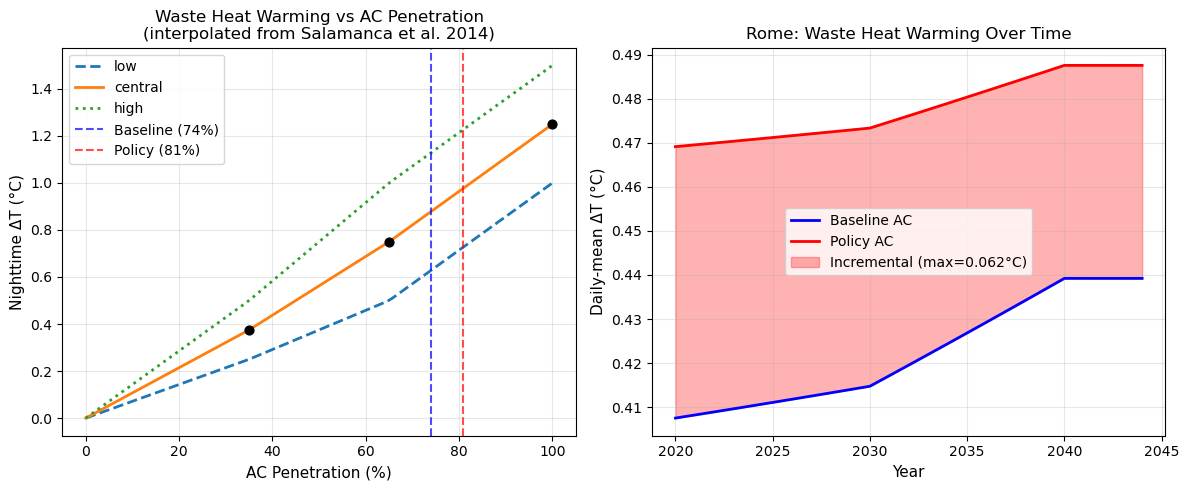

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_wasteheat_timeseries.png


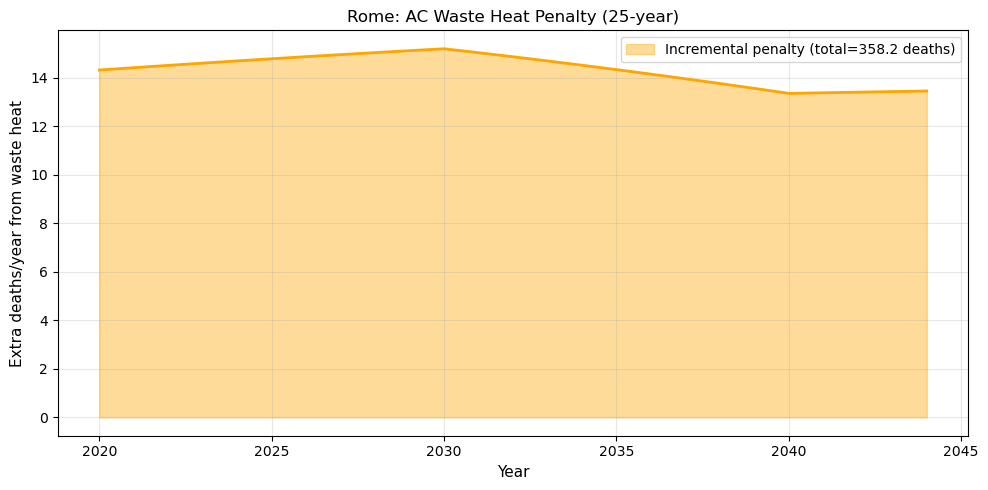

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_wasteheat_penalty.png


In [174]:
# Plot 1: Waste heat warming vs AC penetration (Salamanca curve)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Interpolation curve
ax = axes[0]
pen_range = np.linspace(0, 1, 100)
for case, ls in [("low", "--"), ("central", "-"), ("high", ":")]:
    dT = dT_night_from_penetration(pen_range, case=case)
    ax.plot(pen_range * 100, dT, ls=ls, lw=2, label=case)

# Mark LUT points
for pen, vals in AC_WASTEHEAT_LUT.items():
    if pen > 0:
        ax.scatter([pen*100], [vals["central"]], color="black", s=40, zorder=5)

# Mark city baseline/policy
ax.axvline(pen_base_t[-1]*100, color="blue", ls="--", alpha=0.7, label=f"Baseline ({pen_base_t[-1]:.0%})")
ax.axvline(pen_pol_t[-1]*100, color="red", ls="--", alpha=0.7, label=f"Policy ({pen_pol_t[-1]:.0%})")

ax.set_xlabel("AC Penetration (%)", fontsize=11)
ax.set_ylabel("Nighttime ΔT (°C)", fontsize=11)
ax.set_title("Waste Heat Warming vs AC Penetration\n(interpolated from Salamanca et al. 2014)")
ax.legend()
ax.grid(alpha=0.3)

# Right: Time series
ax = axes[1]
ax.plot(YEARS_ALL, dT_dm_base_t, label="Baseline AC", color="blue", lw=2)
ax.plot(YEARS_ALL, dT_dm_pol_t, label="Policy AC", color="red", lw=2)
ax.fill_between(YEARS_ALL, dT_dm_base_t, dT_dm_pol_t, alpha=0.3, color="red",
                label=f"Incremental (max={dT_dm_inc_t.max():.3f}°C)")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Daily-mean ΔT (°C)", fontsize=11)
ax.set_title(f"{SLUG.title()}: Waste Heat Warming Over Time")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_wasteheat_timeseries.png", dpi=150)
plt.show()
print(f"Saved: {OUT / f'{SLUG}_wasteheat_timeseries.png'}")

# %%
# Plot 2: Penalty time series
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(YEARS_ALL, 0, warming_penalty_t, alpha=0.4, color="orange",
                label=f"Incremental penalty (total={warming_penalty_t.sum():.1f} deaths)")
ax.plot(YEARS_ALL, warming_penalty_t, color="orange", lw=2)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Extra deaths/year from waste heat", fontsize=11)
ax.set_title(f"{SLUG.title()}: AC Waste Heat Penalty (25-year)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_wasteheat_penalty.png", dpi=150)
plt.show()
print(f"Saved: {OUT / f'{SLUG}_wasteheat_penalty.png'}")

## 8. COST-EFFECTIVENESS (summary metrics, policy comparison)

This section provides a standalone summary of the AC policy's effectiveness.
The full CBA comparison (AC vs Trees vs EWS) is performed in NB8.

### Key metrics:
- Avoided deaths by policy scenario
- Cost parameters summary
- Simple cost-effectiveness ratio (preliminary)

### 8.1 Summary Metrics

In [175]:
print("="*70)
print("AVOIDED DEATHS SUMMARY")
print("="*70)

avoided_deaths_rows = []

# 1. Income-targeted policy from tab_ac
if 'tab_ac' in dir() and isinstance(tab_ac, pd.DataFrame):
    print("\n[Income-targeted policy] from tab_ac:")
    
    for year in tab_ac.index:
        if "overall" in tab_ac.columns:
            avoided = float(tab_ac.loc[year, "overall"])
        else:
            avoided = float(tab_ac.loc[year].sum())
        
        avoided_deaths_rows.append({
            "year": int(year),
            "policy": "income-targeted",
            "avoided_deaths": avoided,
        })
        print(f"    {year}: {avoided:.1f} avoided deaths")

# 2. Uniform policy
if 'rows_uniform' in dir() and isinstance(rows_uniform, list) and len(rows_uniform) > 0:
    print("\n[Uniform policy] from rows_uniform:")
    df_uniform = pd.DataFrame(rows_uniform)
    
    # finding the avoided deaths column
    avoided_col = None
    for col in ["avoided_uniform_vs_citycurrAC", "avoided_policy_vs_citycurrAC", "avoided"]:
        if col in df_uniform.columns:
            avoided_col = col
            break
    
    if avoided_col and "year" in df_uniform.columns:
        for year in YEARS_AC:
            sub = df_uniform[df_uniform["year"] == year]
            if len(sub) > 0:
                avoided = float(sub[avoided_col].sum())
                avoided_deaths_rows.append({
                    "year": int(year),
                    "policy": "uniform",
                    "avoided_deaths": avoided,
                })
                print(f"    {year}: {avoided:.1f} avoided deaths")

# display summary
if avoided_deaths_rows:
    avoided_df = pd.DataFrame(avoided_deaths_rows)
    
    print("\n" + "-"*50)
    avoided_pivot = avoided_df.pivot(index="year", columns="policy", values="avoided_deaths")
    display(avoided_pivot.round(1))
    
    print("\nCumulative avoided deaths (sum over anchor years):")
    for pol in avoided_df["policy"].unique():
        total = avoided_df[avoided_df["policy"] == pol]["avoided_deaths"].sum()
        print(f"  {pol}: {total:.1f} deaths")
    
    avoided_df.to_csv(OUT / f"{SLUG}_avoided_deaths_summary.csv", index=False)
    print(f"\n✓ Saved: {SLUG}_avoided_deaths_summary.csv")
else:
    print("\n No avoided deaths data found. Check Section 4.")

AVOIDED DEATHS SUMMARY

[Income-targeted policy] from tab_ac:
    2020: 20.4 avoided deaths
    2030: 23.5 avoided deaths
    2040: 21.9 avoided deaths
    2050: 21.8 avoided deaths

[Uniform policy] from rows_uniform:
    2020: 20.7 avoided deaths
    2030: 23.7 avoided deaths
    2040: 21.9 avoided deaths
    2050: 21.8 avoided deaths

--------------------------------------------------


policy,income-targeted,uniform
year,,
2020,20.400,20.700
2030,23.500,23.700
2040,21.900,21.900
2050,21.800,21.800



Cumulative avoided deaths (sum over anchor years):
  income-targeted: 87.7 deaths
  uniform: 88.1 deaths

✓ Saved: rome_avoided_deaths_summary.csv


### 8.2 Cost Parameters Summary


In [176]:
print("="*70)
print("COST PARAMETERS SUMMARY")
print("="*70)

print("\n1. AC Equipment Costs:")
print(f"   CAPEX per user:     €{AC_CAPEX_PER_USER:,.0f}")
print(f"   Maintenance:        {AC_MAINT_RATE:.0%} of CAPEX/year = €{maint_per_user_yr:.0f}/user/year")
print(f"   Lifetime:           {AC_LIFETIME_YEARS} years")

print("\n2. Electricity Costs:")
print(f"   Tariff:             €{TARIFF_EUR_PER_KWH:.2f}/kWh")

if 'per_user_city_by_year' in dir():
    print("\n   kWh per AC user (city-level):")
    for y in sorted(per_user_city_by_year.keys()):
        print(f"     {y}: {per_user_city_by_year[y]:,.0f} kWh/user/year")

print("\n3. CBA Parameters (for NB8):")
cba_cfg = cfg.get("cba", {})
R = cba_cfg.get("discount_rate", 0.03)
T = cba_cfg.get("horizon_years", 25)
print(f"   Discount rate:      {R:.1%}")
print(f"   Horizon:            {T} years")

COST PARAMETERS SUMMARY

1. AC Equipment Costs:
   CAPEX per user:     €500
   Maintenance:        5% of CAPEX/year = €25/user/year
   Lifetime:           10 years

2. Electricity Costs:
   Tariff:             €0.25/kWh

   kWh per AC user (city-level):
     2020: 1,575 kWh/user/year
     2030: 1,575 kWh/user/year
     2040: 1,662 kWh/user/year
     2050: 1,739 kWh/user/year

3. CBA Parameters (for NB8):
   Discount rate:      3.0%
   Horizon:            25 years


### 8.3 Policy Coverage Summary

In [177]:
print("="*70)
print("POLICY COVERAGE SUMMARY")
print("="*70)

coverage_rows = []

for k, year in enumerate(YEARS_AC):
    pop_grid = POP_GRID.get(year, pop_on_ref)
    m = CITY_MASK & np.isfinite(pop_grid) & (pop_grid > 0)
    
    def pwmean(arr):
        if arr is None:
            return np.nan
        valid = m & np.isfinite(arr)
        if not np.any(valid):
            return np.nan
        return float(np.average(arr[valid], weights=pop_grid[valid]))
    
    cov_base = coverage_base_3d[k] if coverage_base_3d is not None else None
    cov_pol = coverage_policy_3d[k] if coverage_policy_3d is not None else None
    cov_unif = coverage_uniform_3d[k] if 'coverage_uniform_3d' in dir() and coverage_uniform_3d is not None else None
    
    coverage_rows.append({
        "year": year,
        "baseline": pwmean(cov_base),
        "income-targeted": pwmean(cov_pol),
        "uniform": pwmean(cov_unif) if cov_unif is not None else np.nan,
    })

cov_df = pd.DataFrame(coverage_rows).set_index("year")

# Format as percentages for display
cov_display = cov_df.map(lambda x: f"{x:.1%}" if not pd.isna(x) else "-")
print("\nAC Coverage by Year:\n")
display(cov_display)

# Added users per year (for NB8 CBA)
print(f"\nAdded users by year (policy - baseline):")
for k, year in enumerate(YEARS_AC):
    pop_y = POP_GRID.get(year, pop_on_ref)
    m = CITY_MASK & np.isfinite(pop_y)
    
    base_users_y = float(np.nansum(coverage_base_3d[k][m] * pop_y[m]))
    pol_users_y = float(np.nansum(coverage_policy_3d[k][m] * pop_y[m]))
    added_y = pol_users_y - base_users_y
    
    print(f"  {year}: Baseline {base_users_y:,.0f} → Policy {pol_users_y:,.0f} (Δ = {added_y:,.0f})")

POLICY COVERAGE SUMMARY

AC Coverage by Year:



,baseline,income-targeted,uniform
year,,,
2020,69.6%,78.2%,78.2%
2030,70.6%,78.8%,78.8%
2040,74.0%,80.8%,80.8%
2050,74.0%,80.8%,80.8%



Added users by year (policy - baseline):
  2020: Baseline 1,832,535 → Policy 2,059,909 (Δ = 227,374)
  2030: Baseline 1,798,050 → Policy 2,007,193 (Δ = 209,143)
  2040: Baseline 1,841,237 → Policy 2,009,754 (Δ = 168,517)
  2050: Baseline 1,805,251 → Policy 1,970,508 (Δ = 165,256)


**why are they not the same as the ones we saw before**?
- Before: was for policy design! used 2020 static pop (was just so that the uniform policy has the exact same budget in terms of added-users as income-based policy)
- for a CBA, we want the actual users each year (with specific pop):
    - CAPEX is paid when users actually get AC
    - Electricity consumption depends on actual users that year
    - Maintenance costs depend on actual AC units in use 

### 8.4 Preliminary Cost-Effectiveness

**Note**: This is a simplified estimate. The full PV calculation is in NB8 (CBA).

In [180]:
print("="*70)
print("PRELIMINARY COST-EFFECTIVENESS")
print("="*70)

if 'avoided_df' in dir() and len(avoided_df) > 0 and 'added_users' in dir():
    # using income-targeted policy
    income_data = avoided_df[avoided_df["policy"] == "income-targeted"]
    total_avoided = income_data["avoided_deaths"].sum()
    
    if total_avoided > 0:
        # simple annualized cost estimate
        capex_annual = (AC_CAPEX_PER_USER / AC_LIFETIME_YEARS) * added_users
        maint_annual = maint_per_user_yr * added_users
        avg_kwh = np.mean(list(per_user_city_by_year.values()))
        elec_annual = avg_kwh * TARIFF_EUR_PER_KWH * added_users
        total_annual = capex_annual + maint_annual + elec_annual
        
        avg_avoided_per_year = total_avoided / len(YEARS_AC)
        cost_per_death = total_annual / avg_avoided_per_year
        
        print("\nSimplified Annual Cost Estimate:")
        print(f"  Added users:           {added_users:,.0f}")
        print(f"  CAPEX (annualized):    €{capex_annual:,.0f}/year")
        print(f"  Maintenance:           €{maint_annual:,.0f}/year")
        print(f"  Electricity:           €{elec_annual:,.0f}/year")
        print(f"  ─────────────────────────────────")
        print(f"  Total annual:          €{total_annual:,.0f}/year")
        
        print(f"\nSimplified Effectiveness:")
        print(f"  Total avoided:         {total_avoided:.1f} deaths (over {len(YEARS_AC)} anchor years)")
        print(f"  Avg per year:          {avg_avoided_per_year:.1f} deaths/year")
        print(f"  Cost per death:        €{cost_per_death:,.0f}/death")
        
        print("\n Note: See NB8 for full PV calculation with:")
        print("   - 25-year horizon with dynamic coverage")
        print("   - Cohort-based CAPEX with replacement")
        print("   - Waste heat feedback penalty")
else:
    print("\n Cannot compute: avoided_df or added_users not available.")

PRELIMINARY COST-EFFECTIVENESS

Simplified Annual Cost Estimate:
  Added users:           165,256
  CAPEX (annualized):    €8,262,825/year
  Maintenance:           €4,131,412/year
  Electricity:           €67,656,751/year
  ─────────────────────────────────
  Total annual:          €80,050,989/year

Simplified Effectiveness:
  Total avoided:         87.7 deaths (over 4 anchor years)
  Avg per year:          21.9 deaths/year
  Cost per death:        €3,652,549/death

 Note: See NB8 for full PV calculation with:
   - 25-year horizon with dynamic coverage
   - Cohort-based CAPEX with replacement
   - Waste heat feedback penalty


## 9. OUTPUTS AND EXPORTS (coverage maps, tables, diagnostics)

### 9.1 Output File Checklist

In [181]:
print("="*70)
print("OUTPUT FILE CHECKLIST")
print("="*70)

def check_file(path, desc):
    """Check if file exists and print status."""
    exists = path.exists() if hasattr(path, 'exists') else False
    status = "yes" if exists else "no"
    print(f"  {status} {desc}")
    if not exists:
        print(f"      Missing: {path}")
    return exists

all_ok = True

print("\n1. COVERAGE MAPS:")
all_ok &= check_file(OUT / f"ac_coverage_maps_{SLUG}.npz", "Coverage 3D arrays")
all_ok &= check_file(OUT / f"{SLUG}_muni_cov_yearly.csv", "Municipio coverage by year")

print("\n2. AVOIDED DEATHS:")
all_ok &= check_file(INT / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv", "Income-targeted avoided")
all_ok &= check_file(OUT / f"{SLUG}_avoided_deaths_summary.csv", "Summary table")

print("\n3. ELECTRICITY CONSUMPTION:")
all_ok &= check_file(INT / f"ac_per_user_city_{SLUG}.csv", "City-level kWh/user")
all_ok &= check_file(OUT / f"{SLUG}_cap_ac_consumption_summary.csv", "CAP consumption")
all_ok &= check_file(OUT / f"{SLUG}_cap_ac_consumption_map.geojson", "CAP GeoJSON")
all_ok &= check_file(OUT / f"{SLUG}_muni_ac_consumption_summary.csv", "Municipio consumption")
all_ok &= check_file(OUT / f"{SLUG}_muni_ac_consumption_map.geojson", "Municipio GeoJSON")

print("\n4. FEEDBACK PARAMETERS:")
all_ok &= check_file(INT / f"marginal_heat_deaths_perC_generic_{SLUG}.csv", "Marginal deaths (no AC)")
all_ok &= check_file(INT / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv", "Marginal deaths (current)")
all_ok &= check_file(INT / f"marginal_heat_deaths_perC_policyAC_{SLUG}.csv", "Marginal deaths (policy)")
all_ok &= check_file(INT / f"wasteheat_params_{SLUG}.json", "Waste heat params")
all_ok &= check_file(INT / f"feedback_summary_{SLUG}.csv", "Feedback summary")

print("\n5. COST PARAMETERS:")
all_ok &= check_file(INT / f"ac_cost_params_{SLUG}.json", "AC cost params")

OUTPUT FILE CHECKLIST

1. COVERAGE MAPS:
  yes Coverage 3D arrays
  yes Municipio coverage by year

2. AVOIDED DEATHS:
  yes Income-targeted avoided
  yes Summary table

3. ELECTRICITY CONSUMPTION:
  yes City-level kWh/user
  yes CAP consumption
  yes CAP GeoJSON
  yes Municipio consumption
  yes Municipio GeoJSON

4. FEEDBACK PARAMETERS:
  yes Marginal deaths (no AC)
  yes Marginal deaths (current)
  yes Marginal deaths (policy)
  yes Waste heat params
  yes Feedback summary

5. COST PARAMETERS:
  yes AC cost params


### 9.2 Save Missing Files

In [183]:
print("\n" + "="*70)
print("SAVING MISSING FILES")
print("="*70)

# Coverage maps
coverage_path = OUT / f"ac_coverage_maps_{SLUG}.npz"
if not coverage_path.exists():
    save_dict = {"years": np.array(YEARS_AC), "coverage_base_3d": coverage_base_3d}
    if coverage_policy_3d is not None:
        save_dict["coverage_policy_3d"] = coverage_policy_3d
    if 'coverage_uniform_3d' in dir() and coverage_uniform_3d is not None:
        save_dict["coverage_uniform_3d"] = coverage_uniform_3d
    np.savez_compressed(coverage_path, **save_dict)
    print(f" Saved: {coverage_path.name}")

# AC cost params
cost_params_path = INT / f"ac_cost_params_{SLUG}.json"
if not cost_params_path.exists():
    import json
    ac_cost_params = {
        "capex_per_user": AC_CAPEX_PER_USER,
        "maint_rate": AC_MAINT_RATE,
        "lifetime_years": AC_LIFETIME_YEARS,
        "tariff_eur_per_kwh": TARIFF_EUR_PER_KWH,
        "maint_per_user_yr": maint_per_user_yr,
    }
    with open(cost_params_path, "w") as f:
        json.dump(ac_cost_params, f, indent=2)
    print(f" Saved: {cost_params_path.name}")


SAVING MISSING FILES


### 9.3 Final Summary

In [185]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n1. POLICY SCENARIOS:")
print(f"   Baseline AC coverage")
print(f"   Income-targeted policy")
if 'coverage_uniform_3d' in dir() and coverage_uniform_3d is not None:
    print(f"   Uniform policy")

print(f"\n2. YEARS ANALYZED: {YEARS_AC}")

print(f"\n3. KEY RESULTS:")
# Coverage
if coverage_policy_3d is not None:
    cov_base = float(np.nanmean(coverage_base_3d[-1][CITY_MASK]))
    cov_pol = float(np.nanmean(coverage_policy_3d[-1][CITY_MASK]))
    print(f"   AC coverage ({YEARS_AC[-1]}): {cov_base:.1%} → {cov_pol:.1%}")

# Avoided deaths
if 'avoided_df' in dir() and len(avoided_df) > 0:
    total = avoided_df[avoided_df["policy"] == "income-targeted"]["avoided_deaths"].sum()
    print(f"   Avoided deaths (income-targeted): {total:.1f} (sum over anchor years)")

# Electricity
if 'city_summary' in dir() and isinstance(city_summary, pd.DataFrame):
    row = city_summary[city_summary["year"] == YEARS_AC[-1]]
    if len(row) > 0:
        gwh = row["city_total_GWh"].iloc[0]
        print(f"   City electricity ({YEARS_AC[-1]}): {gwh:.1f} GWh/year")

# Waste heat
if 'wasteheat_params' in dir() and isinstance(wasteheat_params, dict):
    dT = wasteheat_params.get('dT_incremental_dailymean', 0)
    print(f"   Waste heat ΔT (incremental): {dT:.3f}°C")

print(f"\n4. READY FOR NB8 (CBA): {'Okay, All files present' if all_ok else ' Problem: Some files missing'}")

print("\n" + "="*70)
print("NOTEBOOK 5 COMPLETE: AC Adaptation Policy")
print("="*70)


FINAL SUMMARY

1. POLICY SCENARIOS:
   Baseline AC coverage
   Income-targeted policy
   Uniform policy

2. YEARS ANALYZED: [2020, 2030, 2040, 2050]

3. KEY RESULTS:
   AC coverage (2050): 70.4% → 77.7%
   Avoided deaths (income-targeted): 87.7 (sum over anchor years)
   City electricity (2050): 3139.9 GWh/year
   Waste heat ΔT (incremental): 0.000°C

4. READY FOR NB8 (CBA): Okay, All files present

NOTEBOOK 5 COMPLETE: AC Adaptation Policy
